# build dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import json

In [2]:
data_df = pd.read_csv('../data/paragraphs_with_sections.csv')
ground_truth_df = pd.read_csv('../data/sentences.csv')

In [3]:
ground_truth_df = ground_truth_df.merge(data_df[['article','pid','section']], on=['pid','article'], how='left')

In [4]:
ground_truth_df

,index,article,text,sid,target,charStartAt,charEndAt,pid,section
0,0,PMC5064025,Title,S1,NaN,0,5,1,Title
1,1,PMC5064025,Arterial Effects of Canakinumab in Patients Wi...,S2,NaN,6,113,2,Title
2,2,PMC5064025,Abstract,S3,NaN,114,122,3,Abstract
3,3,PMC5064025,Background,S4,NaN,143,153,4,Abstract
4,4,PMC5064025,Evidence suggests that interleukin (IL)-1β is ...,S5,1b,164,357,5,Abstract
...,...,...,...,...,...,...,...,...,...
10704,10704,PMC4902320,"NAH and BF did the primary analysis, and all a...",S167,NaN,21624,21753,54,Other
10705,10705,PMC4902320,Final approval: All authors.,S168,NaN,21754,21782,54,Other
10706,10706,PMC4902320,The author reports no conflicts of interest.,S169,NaN,21805,21849,55,Other
10707,10707,PMC4902320,Supplemental digital content is available for ...,S170,NaN,21872,21931,56,Other


In [5]:
for section in ground_truth_df['section'].unique():
    print(f"Section: {section}")
    section_df = ground_truth_df[ground_truth_df['section'] == section]
    print(section_df['target'].value_counts())
    print()

def _section_family_candidates_for_proto(section):
    """
    Only used as a weak fallback if item_proposal returns empty or unparsable output.
    This does not replace item_proposal; it prevents alignment from failing silently.
    """
    sec = str(section or "").lower()
    if "method" in sec:
        return ["3a", "3b", "4a", "4b", "5", "6a", "6b", "7a", "7b", "8a", "8b", "9", "10", "11a", "11b", "12a", "12b", "23", "24"]
    if "result" in sec:
        return ["13a", "13b", "14a", "14b", "15", "16", "17a", "17b", "18", "19"]
    if "discussion" in sec or "conclusion" in sec:
        return ["20", "21", "22"]
    if "abstract" in sec or "intro" in sec:
        return ["1a", "1b", "2a", "2b", "3a", "4a", "5", "6a", "17a", "18", "19", "20", "22"]
    return []

Section: Title
target
1a       39
1a,3a     1
Name: count, dtype: int64

Section: Abstract
target
1b       48
23       35
3a        3
4b        2
2a        2
2b        1
23,25     1
1b,2b     1
8b        1
Name: count, dtype: int64

Section: Methods
target
6a             619
12a            248
5              237
4a             145
7a             108
              ... 
9,8a             1
8b,10,9          1
11a,8b           1
4a,14a,5,3a      1
14a,4a           1
Name: count, Length: 93, dtype: int64

Section: Results
target
17a               685
18                213
15                178
17b               150
19                146
13b                57
13a                54
16                 40
19,17b             28
13a,13b,16         26
14a                11
17a,17b             8
13a,16,13b          7
13a,13b             7
19,17a              5
14b                 5
14a,13a             5
13a,16              5
17b,19              5
7b                  5
17a,19              5
15,17a   

In [6]:
df_o4 = pd.read_csv('../../claude_code/data/ambiguous_o4.csv')
df_o4.head()

,article,pid,sid,original_text,item,value,sent,sent_seq,score,match_score
0,PMC5064025,5,S5,Evidence suggests that interleukin (IL)-1β is ...,2a,evidence suggests that interleukin (il)-1β is ...,evidence suggests that interleukin (il)-1β is ...,0,0.90,100
1,PMC5064025,7,S7,The goal of this study was to evaluate the eff...,2b,the goal of this study was to evaluate the eff...,the goal of this study was to evaluate the eff...,0,0.95,100
2,PMC5064025,9,S9,Patients (N = 189) with atherosclerotic diseas...,3a,patients (n = 189) with atherosclerotic diseas...,patients (n = 189) with atherosclerotic diseas...,0,0.85,100
3,PMC5064025,9,S9,Patients (N = 189) with atherosclerotic diseas...,4a,patients (n = 189) with atherosclerotic diseas...,patients (n = 189) with atherosclerotic diseas...,0,0.90,100
4,PMC5064025,9,S9,Patients (N = 189) with atherosclerotic diseas...,5,patients (n = 189) with atherosclerotic diseas...,patients (n = 189) with atherosclerotic diseas...,0,0.95,100


In [7]:
ground_truth_df[40:50]

,index,article,text,sid,target,charStartAt,charEndAt,pid,section
40,40,PMC5064025,Vascular magnetic resonance imaging (MRI) has ...,S41,NaN,5682,5878,19,Abstract
41,41,PMC5064025,"Accordingly, we designed a randomized, placebo...",S42,2b,5879,6256,19,Abstract
42,42,PMC5064025,Methods,S43,NaN,6268,6275,20,Methods
43,43,PMC5064025,"Novartis Pharmaceuticals (Cambridge, Massachus...",S44,3a,6282,6576,21,Methods
44,44,PMC5064025,The study was undertaken at 9 centers in Canad...,S45,4b,6577,6802,21,Methods
45,45,PMC5064025,The protocol was reviewed and approved by the ...,S46,NaN,6803,6908,21,Methods
46,46,PMC5064025,All participants provided written informed con...,S47,NaN,6909,7000,21,Methods
47,47,PMC5064025,Patients,S48,NaN,7016,7024,22,Methods
48,48,PMC5064025,Patients (ages 18 to 74 years) were eligible f...,S49,4a,7033,7366,23,Methods
49,49,PMC5064025,"In addition, patients must also have had eithe...",S50,4a,7367,7625,23,Methods


In [8]:
gt = ground_truth_df.copy()

gt = gt.dropna(subset=["target"])
gt["target"] = gt["target"].astype(str).str.strip()

In [9]:
grouped = (
    gt.groupby(["article", "pid", "target"])["text"]
    .apply(list)
    .reset_index()
)

In [10]:
para_labels = (
    grouped.groupby(["article", "pid"])
    .apply(lambda df: [
        {"item": row["target"], "sentences": row["text"]}
        for _, row in df.iterrows()
    ])
    .reset_index(name="output")
)

/tmp/ipykernel_206402/1416417500.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: [


In [11]:
dataset_df = data_df.merge(
    para_labels,
    on=["article", "pid"],
    how="left"
)

In [12]:
dataset_df["output"] = dataset_df["output"].apply(
    lambda x: x if isinstance(x, list) else []
)

In [13]:
# dataset_df = dataset_df[dataset_df['pid']>=15]
# alternatively just filter out the title/abstract section
dataset_df = dataset_df[~dataset_df['section'].isin(['Abstract','Title'])]

In [14]:
dataset_df['section'].value_counts()

section
Methods         1001
Results          948
Discussion       931
Other            388
Introduction     241
Name: count, dtype: int64

In [15]:
df_o4.drop_duplicates(subset=['article', 'pid'], inplace=True)

In [16]:
import json
import pandas as pd
import numpy as np

def is_empty_gold(x):
    """
    Return True if gold output has no CONSORT item.
    Handles list, JSON string, NaN, and [].
    """
    if x is None:
        return True

    if isinstance(x, float) and pd.isna(x):
        return True

    if isinstance(x, list):
        return len(x) == 0

    if isinstance(x, str):
        s = x.strip()
        if s in ["", "[]", "nan", "None"]:
            return True
        try:
            obj = json.loads(s)
            return len(obj) == 0
        except Exception:
            return False

    return False


# Merge baseline/o4 predictions.
# Important: rename item from df_o4 so it does not conflict with gold item fields.
dataset_df = dataset_df.merge(
    df_o4[["article", "pid", "item"]].rename(columns={"item": "o4_item"}),
    on=["article", "pid"],
    how="left"
)

dataset_df["gold_empty"] = dataset_df["output"].apply(is_empty_gold)

# Whether baseline/o4 predicted something for this paragraph
dataset_df["o4_pred_empty"] = dataset_df["o4_item"].isna()

def assign_example_type(row):
    if not row["gold_empty"]:
        return "positive"
    elif row["gold_empty"] and not row["o4_pred_empty"]:
        return "hard_negative"
    else:
        return "easy_negative"

dataset_df["example_type"] = dataset_df.apply(assign_example_type, axis=1)

print(dataset_df["example_type"].value_counts())
print(dataset_df["example_type"].value_counts(normalize=True))

example_type
positive         1770
easy_negative    1421
hard_negative     318
Name: count, dtype: int64
example_type
positive         0.504417
easy_negative    0.404959
hard_negative    0.090624
Name: proportion, dtype: float64


In [17]:
# for the few-shot, skip for now
embeddings = pd.read_csv('../data/paragraph_embeddings.csv')
dataset_df = dataset_df.merge(
    embeddings[['article', 'pid', 'embedding']],
    on=['article', 'pid'],
    how='left'
)

In [18]:
dataset = dataset_df[["text", "section", "output"]].rename(
    columns={"text": "paragraph"}
)

In [19]:
dataset.iloc[2].output

[]

In [20]:
articles = ground_truth_df.article.unique()

train_articles, test_articles = train_test_split(
    articles,
    test_size=0.1,
    random_state=42
)

In [21]:
from sklearn.model_selection import train_test_split

def split_by_article(dataset_df, dev_size=0.1, random_state=42):
    articles = dataset_df["article"].drop_duplicates().tolist()

    train_articles, dev_articles = train_test_split(
        articles, test_size=dev_size, random_state=random_state
    )

    train_df = dataset_df[dataset_df["article"].isin(train_articles)].reset_index(drop=True)
    dev_df = dataset_df[dataset_df["article"].isin(dev_articles)].reset_index(drop=True)

    return train_df, dev_df

In [22]:
train_df, dev_df = split_by_article(dataset_df[dataset_df["article"].isin(train_articles)])
test_df = dataset_df[dataset_df["article"].isin(test_articles)]
print(len(train_df), len(dev_df), len(test_df))
print(train_df["article"].nunique(), dev_df["article"].nunique(), test_df["article"].nunique())

2616 418 475
39 5 6


In [22]:
# Keep all training examples.
# We will control positive/hard-negative/easy-negative balance through the sampler.
print("Train size before balancing:", len(train_df))
print(train_df["example_type"].value_counts())

Train size before balancing: 2616
example_type
positive         1338
easy_negative    1046
hard_negative     232
Name: count, dtype: int64


In [23]:
train_dataset = train_df[["text", "section", "output", "example_type"]].rename(
    columns={"text": "paragraph"}
)

dev_dataset = dev_df[["text", "section", "output", "example_type"]].rename(
    columns={"text": "paragraph"}
)

test_dataset = test_df[["text", "section", "output", "example_type"]].rename(
    columns={"text": "paragraph"}
)

In [24]:
train_dataset.to_csv('../data/train_dataset.csv', index=False)

In [25]:
import pandas as pd
import ast
import re

def parse_output(x):
    """
    Safely parse model output into a normalized list of dictionaries.
    Normalizes 'Item' -> 'item'.
    """

    if x is None:
        return []

    # Guard pd.isna against array-like inputs (lists, arrays) which return
    # an array of bools and raise ValueError in a boolean context.
    if not isinstance(x, (list, dict)):
        try:
            if pd.isna(x):
                return []
        except (TypeError, ValueError):
            pass

    if isinstance(x, dict):
        parsed = [x]

    elif isinstance(x, list):
        parsed = x

    else:
        x = str(x).strip()

        if x == "":
            return []

        # Remove markdown code fences
        x = re.sub(r"^```(?:json)?", "", x, flags=re.IGNORECASE).strip()
        x = re.sub(r"```$", "", x).strip()

        try:
            parsed = json.loads(x)
        except Exception:
            try:
                parsed = ast.literal_eval(x)
            except Exception:
                return []

        if isinstance(parsed, dict):
            parsed = [parsed]

    if not isinstance(parsed, list):
        return []

    cleaned = []

    for obj in parsed:
        if not isinstance(obj, dict):
            continue

        # Normalize key names
        if "item" not in obj and "Item" in obj:
            obj["item"] = obj["Item"]

        if "item" not in obj:
            continue

        cleaned.append(obj)

    return cleaned

def normalize_item(x):
    """
    Convert item field into a list of individual item IDs.
    Handles:
    - '6a'
    - ['6a', '12a']
    - '6a, 12a'
    - '6a; 12a'
    - '6a and 12a'
    """
    if x is None:
        return []

    if isinstance(x, list):
        return [str(i).strip() for i in x if pd.notna(i)]

    x = str(x).strip()

    # Extract CONSORT-style item ids such as 1a, 2b, 6a, 12a, 17b, 25
    items = re.findall(r"\b\d{1,2}[a-z]?\b", x)


    return items

In [26]:
train_df = train_dataset.copy()

# parse output
train_df["output_parsed"] = train_df["output"].apply(parse_output)

# one row per output object
exploded = train_df.explode("output_parsed").reset_index(drop=False)

# remove rows with empty output
exploded = exploded[exploded["output_parsed"].notna()].copy()

# extract item field from each dictionary
exploded["item"] = exploded["output_parsed"].apply(
    lambda x: x.get("item") if isinstance(x, dict) else None
)

# convert item field into list of individual items
exploded["item"] = exploded["item"].apply(normalize_item)

# one row per individual item
item_level_train_df = exploded.explode("item")

# remove missing items
item_level_train_df = item_level_train_df[
    item_level_train_df["item"].notna() & (item_level_train_df["item"] != "")
].copy()

# keep useful columns
item_level_train_df = item_level_train_df[["index", "paragraph", "section", "item"]].rename(
    columns={"index": "paragraph_id"}
)

item_level_train_df.head()

for s in item_level_train_df['section'].unique():
    print(f"Section: {s}")
    print(item_level_train_df[item_level_train_df['section'] == s]['item'].value_counts())
    print()

Section: Methods
item
6a     199
5       92
12a     73
4a      55
3a      47
7a      41
8b      34
10      32
8a      31
11a     31
12b     31
4b      28
14a     19
9       15
23      13
11b     13
7b      10
16       7
13a      6
24       5
13b      4
3b       4
6b       3
15       3
25       2
Name: count, dtype: int64

Section: Results
item
17a    245
19      87
15      85
18      85
17b     84
13b     76
13a     73
16      59
14a     17
14b      5
4b       4
12a      3
22       2
3a       1
5        1
7b       1
Name: count, dtype: int64

Section: Discussion
item
22     223
20      83
21      25
25      12
11a      2
23       1
14b      1
3a       1
2b       1
Name: count, dtype: int64

Section: Introduction
item
2a     51
2b     41
6a      8
5       5
3a      3
23      2
14a     2
4b      2
11a     2
8a      2
17a     2
4a      2
12b     2
12a     2
11b     1
7a      1
10      1
8b      1
Name: count, dtype: int64

Section: Other
item
25    37
23     1
Name: count, dtype: int64



In [27]:
dev_df = dev_dataset.copy()

# parse output
dev_df["output_parsed"] = dev_df["output"].apply(parse_output)

# one row per output object
exploded = dev_df.explode("output_parsed").reset_index(drop=False)

# remove rows with empty output
exploded = exploded[exploded["output_parsed"].notna()].copy()

# extract item field from each dictionary
exploded["item"] = exploded["output_parsed"].apply(
    lambda x: x.get("item") if isinstance(x, dict) else None
)

# convert item field into list of individual items
exploded["item"] = exploded["item"].apply(normalize_item)

# one row per individual item
item_level_dev_df = exploded.explode("item")

# remove missing items
item_level_dev_df = item_level_dev_df[
    item_level_dev_df["item"].notna() & (item_level_dev_df["item"] != "")
].copy()

# keep useful columns
item_level_dev_df = item_level_dev_df[["index", "paragraph", "section", "item"]].rename(
    columns={"index": "paragraph_id"}
)

item_level_dev_df.head()

for s in item_level_dev_df['section'].unique():
    print(f"Section: {s}")
    print(item_level_dev_df[item_level_dev_df['section'] == s]['item'].value_counts())
    print()

Section: Introduction
item
2a    5
2b    5
Name: count, dtype: int64

Section: Methods
item
6a     25
12a    16
11a    11
5      10
3a      8
4a      8
12b     7
7a      4
8b      4
10      3
16      3
3b      3
14a     2
4b      2
23      2
24      2
7b      2
8a      2
11b     1
15      1
6b      1
Name: count, dtype: int64

Section: Results
item
17a    47
18     19
15     16
17b    16
19     10
13a    10
16      8
13b     4
4b      3
14a     3
22      1
Name: count, dtype: int64

Section: Discussion
item
22    36
20    10
21     5
25     1
Name: count, dtype: int64

Section: Other
item
25    6
23    1
Name: count, dtype: int64



In [28]:
for s in item_level_dev_df['section'].unique():
    print(f"Section: {s}")
    train_unique_items = item_level_train_df[item_level_train_df['section'] == s]['item'].unique()
    print(train_unique_items)
    dev_unique_items = item_level_dev_df[item_level_dev_df['section'] == s]['item'].unique()
    print(dev_unique_items)
    print(list(set(train_unique_items) & set(dev_unique_items)))
    print()

Section: Introduction
['2a' '2b' '23' '3a' '4b' '7a' '11b' '5' '14a' '6a' '8a' '8b' '11a' '10'
 '12a' '12b' '17a' '4a']
['2a' '2b']
['2b', '2a']

Section: Methods
['3a' '4b' '4a' '14a' '5' '8a' '8b' '10' '6a' '11a' '12a' '7a' '12b' '7b'
 '25' '23' '16' '13a' '13b' '9' '11b' '24' '6b' '15' '3b']
['11a' '3a' '14a' '4b' '5' '4a' '6a' '12a' '12b' '7a' '23' '11b' '8b' '7b'
 '8a' '16' '24' '3b' '15' '10' '6b']
['23', '8a', '6a', '4a', '11b', '3a', '15', '8b', '7a', '10', '5', '14a', '4b', '6b', '24', '11a', '7b', '12a', '12b', '16', '3b']

Section: Results
['13a' '16' '13b' '15' '19' '17a' '18' '17b' '14a' '3a' '12a' '4b' '5'
 '22' '14b' '7b']
['13a' '16' '13b' '15' '17a' '18' '22' '17b' '19' '4b' '14a']
['17a', '13b', '16', '13a', '17b', '14a', '22', '18', '19', '4b', '15']

Section: Discussion
['22' '20' '25' '21' '23' '14b' '3a' '11a' '2b']
['22' '25' '21' '20']
['21', '25', '22', '20']

Section: Other
['25' '23']
['25' '23']
['23', '25']



## dataset conversion

In [29]:
import dspy

def df_to_dspy_examples(df):
    examples = []
    for _, row in df.iterrows():
        ex = dspy.Example(
            paragraph=row["paragraph"],
            section=row["section"],
            output=row["output"],
            example_type=row.get("example_type", None)
        ).with_inputs("paragraph", "section")
        examples.append(ex)
    return examples

In [30]:
trainset = df_to_dspy_examples(train_dataset)
devset = df_to_dspy_examples(dev_dataset)
testset = df_to_dspy_examples(test_dataset)

In [31]:
import re
import json
from collections import Counter, defaultdict

VALID_CONSORT_ITEMS = {"1a", "1b","2a", "2b","3a", "3b","4a", "4b","5","6a", "6b","7a", "7b","8a", "8b","9","10",
                       "11a", "11b","12a", "12b","13a", "13b","14a", "14b","15","16","17a", "17b","18","19","20",
                       "21","22","23","24","25",
}

def split_item_string(item):
    """
    Split item strings like:
    '13a,13b,16' -> ['13a', '13b', '16']
    '11a and 11b' -> ['11a', '11b']
    '4a; 4b' -> ['4a', '4b']
    """
    if item is None:
        return []

    item = str(item).strip()
    if item == "":
        return []

    # Extract CONSORT-like item ids directly.
    # Handles 13a, 13b, 16, 11a, etc.
    found = re.findall(r"\b(?:[1-9]|1[0-9]|2[0-5])[a-b]?\b", item)

    clean_items = []
    for x in found:
        x = x.strip().replace(".", "")
        if x in VALID_CONSORT_ITEMS:
            clean_items.append(x)

    return clean_items


def parse_gold_output_items(output):
    """
    Extract independent CONSORT item IDs from the gold output.

    Handles formats like:
    [
      {"item": "13a,13b,16", "sentences": [...]}
    ]

    and returns:
    {"13a", "13b", "16"}
    """
    if output is None:
        return set()

    if isinstance(output, float) and pd.isna(output):
        return set()

    if isinstance(output, str):
        s = output.strip()
        if s in ["", "[]", "nan", "None"]:
            return set()
        try:
            output = json.loads(s)
        except Exception:
            return set()

    if not isinstance(output, list):
        return set()

    items = set()

    for obj in output:
        if not isinstance(obj, dict):
            continue

        raw_item = obj.get("item") or obj.get("Item") or obj.get("ITEM")
        for item in split_item_string(raw_item):
            items.add(item)

    return items


def get_row_items(row):
    return parse_gold_output_items(row["output"])

In [32]:
def build_stratified_gepa_val_dataset(
    dev_dataset,
    n=100,
    seed=42,
    preserve_pos_neg_ratio=True,
    guarantee_rare_item_coverage=True,
):
    rng = np.random.default_rng(seed)
    df = dev_dataset.copy().reset_index(drop=True)

    # Extract independent item sets
    df["_items"] = df.apply(get_row_items, axis=1)
    df["_is_positive"] = df["_items"].apply(lambda x: len(x) > 0)

    original_pos_rate = df["_is_positive"].mean()

    if preserve_pos_neg_ratio:
        n_pos = int(round(n * original_pos_rate))
        n_neg = n - n_pos
    else:
        n_pos = min(n, df["_is_positive"].sum())
        n_neg = n - n_pos

    pos_df = df[df["_is_positive"]].copy()
    neg_df = df[~df["_is_positive"]].copy()

    selected_indices = set()

    # Count each CONSORT item independently
    item_counter = Counter()
    item_to_indices = defaultdict(list)

    for idx, row in pos_df.iterrows():
        for item in row["_items"]:
            item_counter[item] += 1
            item_to_indices[item].append(idx)

    # Cover rare items first
    if guarantee_rare_item_coverage:
        items_by_rarity = sorted(item_counter.keys(), key=lambda x: item_counter[x])

        for item in items_by_rarity:
            if len(selected_indices) >= n_pos:
                break

            candidates = [i for i in item_to_indices[item] if i not in selected_indices]
            if candidates:
                chosen = rng.choice(candidates)
                selected_indices.add(int(chosen))

    # Fill remaining positives
    remaining_pos = n_pos - len(selected_indices)
    if remaining_pos > 0:
        remaining_candidates = [
            i for i in pos_df.index.tolist()
            if i not in selected_indices
        ]

        if len(remaining_candidates) <= remaining_pos:
            selected_indices.update(remaining_candidates)
        else:
            chosen = rng.choice(
                remaining_candidates,
                size=remaining_pos,
                replace=False
            )
            selected_indices.update([int(x) for x in chosen])

    # Sample negatives
    if n_neg > 0:
        neg_candidates = neg_df.index.tolist()
        if len(neg_candidates) <= n_neg:
            selected_indices.update(neg_candidates)
        else:
            chosen_neg = rng.choice(
                neg_candidates,
                size=n_neg,
                replace=False
            )
            selected_indices.update([int(x) for x in chosen_neg])

    gepa_val_dataset = df.loc[sorted(selected_indices)].copy()

    # If slightly over/under due to rare-item coverage, adjust to exactly n
    if len(gepa_val_dataset) > n:
        gepa_val_dataset = gepa_val_dataset.sample(
            n=n,
            random_state=seed
        )

    elif len(gepa_val_dataset) < n:
        missing = n - len(gepa_val_dataset)
        remaining = df.drop(index=gepa_val_dataset.index)
        extra = remaining.sample(
            n=min(missing, len(remaining)),
            random_state=seed
        )
        gepa_val_dataset = pd.concat([gepa_val_dataset, extra], axis=0)

    # Print diagnostics
    original_items = sorted(set().union(*df["_items"].tolist()))
    gepa_items = sorted(set().union(*gepa_val_dataset["_items"].tolist()))

    print("Original dev size:", len(df))
    print("GEPA val size:", len(gepa_val_dataset))

    print(
        f"Original dev positives: {df['_is_positive'].sum()} "
        f"({df['_is_positive'].mean():.1%})"
    )
    print(
        f"GEPA val positives: {gepa_val_dataset['_is_positive'].sum()} "
        f"({gepa_val_dataset['_is_positive'].mean():.1%})"
    )

    print("Original dev distinct independent items:", len(original_items))
    print("GEPA val distinct independent items:", len(gepa_items))
    print("Items covered in GEPA val:", gepa_items)

    missing_items = sorted(set(original_items) - set(gepa_items))
    print("Items missing from GEPA val:", missing_items)

    # Drop helper columns before converting to DSPy examples
    gepa_val_dataset = gepa_val_dataset.drop(
        columns=["_items", "_is_positive"],
        errors="ignore"
    )

    return gepa_val_dataset

In [33]:
gepa_val_dataset = build_stratified_gepa_val_dataset(
    dev_dataset,
    n=100,
    seed=42,
    preserve_pos_neg_ratio=True,
    guarantee_rare_item_coverage=True,
)

gepa_valset = df_to_dspy_examples(gepa_val_dataset)

full_devset = devset
full_testset = testset

print("len(trainset):", len(trainset))
print("len(gepa_valset):", len(gepa_valset))
print("len(full_devset):", len(full_devset))
print("len(full_testset):", len(full_testset))

Original dev size: 418
GEPA val size: 100
Original dev positives: 190 (45.5%)
GEPA val positives: 45 (45.0%)
Original dev distinct independent items: 33
GEPA val distinct independent items: 33
Items covered in GEPA val: ['10', '11a', '11b', '12a', '12b', '13a', '13b', '14a', '15', '16', '17a', '17b', '18', '19', '20', '21', '22', '23', '24', '25', '2a', '2b', '3a', '3b', '4a', '4b', '5', '6a', '6b', '7a', '7b', '8a', '8b']
Items missing from GEPA val: []
len(trainset): 2616
len(gepa_valset): 100
len(full_devset): 418
len(full_testset): 475


# Few shot in-context leanring

In [34]:
# annotation guidelines

with open('../data/annotation_guideline_v1.txt', 'r') as file:
    ag = file.read()
    #print(ag[:100])

In [35]:
with open('../output_and_result/consort_prototype_memory_from_error_logs_v2.json', 'r', encoding='utf-8') as f:
    prototype = json.load(f)

In [ ]:
import numpy as np

def parse_embedding(s):
    return np.fromstring(s.strip("[]"), sep=" ")

# apply
train_df["emb_vec"] = train_df["embedding"].apply(parse_embedding)
dev_df["emb_vec"]   = dev_df["embedding"].apply(parse_embedding)
test_df["emb_vec"]  = test_df["embedding"].apply(parse_embedding)

In [ ]:
train_embeddings = np.vstack(train_df["emb_vec"].values)

# normalize for cosine similarity
train_embeddings = train_embeddings / np.linalg.norm(
    train_embeddings, axis=1, keepdims=True
)

In [ ]:
def retrieve_topk(query_emb, k=3):
    query_emb = query_emb / np.linalg.norm(query_emb)

    sims = train_embeddings @ query_emb
    topk_idx = np.argsort(sims)[-k:][::-1]

    return train_df.iloc[topk_idx]

In [ ]:
def build_fewshot(df):
    examples = []

    for _, row in df.iterrows():
        # assume row["output"] is your structured gold
        items = sorted(set(x["item"] for x in row["output"]))

        examples.append({
            "paragraph": row["paragraph"][:250],  # truncate
            "items": items
        })

    return examples

# extraction signature

### base

In [36]:
class ConsortExtraction(dspy.Signature):
    """You are a healthcare research analyst. Analyze the paragraph and extract
    CONSORT 2010 checklist items (1a–25).

    Instructions:
    1. Read the paragraph sentence by sentence.
    2. Read the annotation guidelines and identify sentences that directly address a CONSORT item according to the guidelines.
    3. Read the prototype examples for the given section and use them as a reference for identifying similar patterns in the paragraph.
    4. Assign the correct CONSORT item.
    5. Assign a confidence score between 0 and 1 for each sentence.

    Rules:
    - Only include items explicitly stated (no inference).
    - Use exact sentences from the paragraph.
    - If multiple sentences support the same item, group them.
    - Each sentence must have its own score.
    - The section provides context but does not determine the label.
    - Use a full range of confidence scores.

    Output ONLY valid JSON in this exact format:
    [
      {
        "Item": "<CONSORT item>",
        "Value": [
          {"Text": "<exact sentence>", "Score": <float>}
        ]
      }
    ]

    Do NOT include any text outside JSON. If no items are found, return []."""

    paragraph = dspy.InputField(desc="A paragraph from a clinical trial paper")
    section   = dspy.InputField(desc="Document section name")
    prototype = dspy.InputField(desc="Prototype for CONSORT item labeling")
    annotation_guidelines = dspy.InputField(desc="Annotation guidelines for CONSORT item labeling")
    output    = dspy.OutputField(
        desc="JSON list of CONSORT items with supporting sentences and confidence scores"
    )


### multi-section

In [37]:
CONSORT_TEXT = """
CONSORT 2010 Checklist Items

2b. Specific objectives or hypotheses

3a. Description of trial design (such as parallel, factorial) including allocation ratio

3b. Important changes to methods after trial commencement (such as eligibility criteria), with reasons

4a. Eligibility criteria for participants

4b. Settings and locations where the data were collected

5. The interventions for each group with sufficient details to allow replication, including how and when they were actually administered

6a. Completely defined pre-specified primary and secondary outcome measures, including how and when they were assessed

6b. Any changes to trial outcomes after the trial commenced, with reasons

7a. How sample size was determined

7b. When applicable, explanation of any interim analyses and stopping guidelines

8a. Method used to generate the random allocation sequence

8b. Type of randomization; details of any restriction (such as blocking and block size)

9. Mechanism used to implement the random allocation sequence (such as sequentially numbered containers), describing any steps taken to conceal the sequence until interventions were assigned

10. Who generated the random allocation sequence, who enrolled participants, and who assigned participants to interventions

11a. If done, who was blinded after assignment to interventions (for example, participants, care providers, those assessing outcomes) and how

11b. If relevant, description of the similarity of interventions

12a. Statistical methods used to compare groups for primary and secondary outcomes

12b. Methods for additional analyses, such as subgroup analyses and adjusted analyses

13a. For each group, the numbers of participants who were randomly assigned, received intended treatment, and were analysed for the primary outcome

13b. For each group, losses and exclusions after randomisation, together with reasons

14a. Dates defining the periods of recruitment and follow-up

14b. Why the trial ended or was stopped

15. A table showing baseline demographic and clinical characteristics for each group

16. For each group, number of participants (denominator) included in each analysis and whether the analysis was by original assigned groups

17a. For each primary and secondary outcome, results for each group, and the estimated effect size and its precision (such as 95% confidence interval)

17b. For binary outcomes, presentation of both absolute and relative effect sizes is recommended

18. Results of any other analyses performed, including subgroup analyses and adjusted analyses, distinguishing pre-specified from exploratory

19. All important harms or unintended effects in each group (for specific guidance see CONSORT for harms)

20. Trial limitations, addressing sources of potential bias, imprecision, and, if relevant, multiplicity of analyses

21. Generalisability (external validity, applicability) of the trial findings

22. Interpretation consistent with results, balancing benefits and harms, and considering other relevant evidence

23. Registration number and name of trial registry

24. Where the full trial protocol can be accessed, if available

25. Sources of funding and other support (such as supply of drugs), role of funders
"""

In [38]:
class ConsortItemProposal(dspy.Signature):
    """
    You are a CONSORT 2010 expert. Given a paragraph from a clinical trial paper,
    identify ALL CONSORT 2010 checklist items (1a–25) that MIGHT be addressed.

    Strategy:
    - Err on the side of inclusion — false negatives are worse than false positives here.
    - Scan each sentence independently; a single paragraph may contain multiple items.
    - Use the section heading as a soft prior (e.g., Methods → items 3a–12b; Results → 13a–19).
    - Candidate items do NOT need to be fully satisfied — borderline or partial mentions qualify.
    - Read the annotation guidelines and identify sentences that directly address a CONSORT item according to the guidelines.

    Common section–item associations (not exhaustive):
    - Introduction         → 2a, 2b
    - Methods              → 3a, 3b, 4a, 4b, 5, 6a, 6b, 7a, 7b, 8a, 8b, 9, 10, 11a, 11b, 12a, 12b
    - Results              → 13a, 13b, 14a, 14b, 15, 16, 17a, 17b, 18, 19
    - Discussion/Conclusion→ 20, 21, 22, 23, 24, 25

    Output ONLY a JSON array of item IDs, e.g. ["4a", "6a", "12a"].
    """

    paragraph = dspy.InputField(
        desc="A single paragraph from a clinical trial paper"
    )

    section = dspy.InputField(
        desc="Section name (context only, e.g., Methods, Results)"
    )

    annotation_guidelines = dspy.InputField(desc="Annotation guidelines for CONSORT item labeling")
    
    candidate_items = dspy.OutputField(
        desc="JSON list of candidate CONSORT item IDs"
    )

class ConsortSentenceExtraction(dspy.Signature):
    """
    Extract every sentence from the paragraph that could plausibly serve as evidence
    for ANY CONSORT 2010 checklist item.

    Rules:
    - Copy sentences EXACTLY as they appear — do not paraphrase or merge.
    - Include sentences that contain numeric data, method descriptions, outcome results,
      eligibility criteria, or randomisation details.
    - Include items from lists or enumerations as individual sentences where appropriate.
    - When in doubt, include — recall is the priority here.
    - Exclude purely transitional or heading text with no substantive content.

    Output ONLY a JSON array of exact sentence strings.
    """

    paragraph = dspy.InputField(
        desc="A paragraph to extract candidate evidence sentences from"
    )

    sentences = dspy.OutputField(
        desc="JSON list of exact sentences from the paragraph"
    )

class ConsortItemSentenceAlignment(dspy.Signature):
    """
    Map each candidate sentence to the single most appropriate CONSORT 2010 item.

    Steps:
    1. For each sentence, consult the item_definitions to find the best matching item.
    2. Prefer the most specific applicable item; do not assign a broader item when a
       narrower one fits.
    3. A sentence may support multiple items only when it explicitly satisfies distinct CONSORT definitions.
    4. Drop any sentence that does not clearly support any candidate item.
    5. Only use information EXPLICITLY stated in the paragraph — do not infer.

      {"item": "6a", "sentences": ["exact sentence from paragraph"]}
    ]
    If no sentences can be confidently assigned, return [].
    """

    paragraph = dspy.InputField(
        desc="Original paragraph for context and verification"
    )

    candidate_items = dspy.InputField(
        desc="List of possible CONSORT item IDs (recall-oriented, may include noise)"
    )

    sentences = dspy.InputField(
        desc="List of candidate sentences extracted from the paragraph"
    )

    item_definitions = dspy.InputField(
        desc="CONSORT item definitions for mapping sentences to items"
    )

    aligned_output = dspy.OutputField(
        desc="""
        JSON list of:
        [
          {"item": "6a", "sentences": ["exact sentence"]}
        ]
        """
    )

class ConsortFinalization(dspy.Signature):
    """
    Assign a confidence score to each (item, sentence) pair and format the final output.

    Scoring guide (0.0 – 1.0):
    - 0.85–1.0 : Sentence explicitly and completely satisfies the CONSORT item definition.
    - 0.60–0.84: Sentence addresses the item but is partial, brief, or embedded in a list.
    - 0.35–0.59: Sentence is relevant but requires minor interpretation or context.
    - 0.10–0.34: Sentence is tangentially related; assignment is uncertain.

    Rules:
    - Sentences must be copied EXACTLY from the original paragraph — no paraphrase.
    - Use the full 0–1 range; avoid clustering all scores at 0.9.
    - Drop any sentence with score < 0.10 (noise).

    Output ONLY valid JSON. If nothing survives, return [].
    [
      {
        "Item": "6a",
        "Value": [
          {"Text": "<exact sentence>", "Score": <float>}
        ]
      }
    ]
    """

    aligned_output = dspy.InputField(
        desc="CONSORT items with their supporting sentences"
    )

    paragraph = dspy.InputField(
        desc="Original paragraph for verifying evidence strength"
    )

    output = dspy.OutputField(
        desc="""
        Final JSON:
        [
          {
            "Item": "6a",
            "Value": [
              {"Text": "...", "Score": 0.92}
            ]
          }
        ]
        """
    )


### multi + prototype

In [39]:
import json as _json_for_proto
import re as _re_for_proto

class ConsortItemProposal(dspy.Signature):
    """
    Identify ALL CONSORT checklist items (1a–25) that might be addressed in this paragraph.

    Use prototype_memory as an attention guide only:
    - section_prior tells you which items are common in this section — use it to focus attention,
      NOT to reject items. Cross-section annotations are frequent in CONSORT-TM.
    - item_hints provides definitions and positive cues to help you recognise items you might miss.

    Rules:
    - This is a RECALL stage. When in doubt, INCLUDE the item.
    - Do NOT apply must-have or not-if rules here — those are the alignment step's job.
    - Do NOT reject an item solely because it is off-prior for the section; explicit evidence overrides priors.
    - Avoid flooding only for clearly irrelevant items (e.g., pure results items in a methods-only paragraph
      with no outcome data), but err heavily toward inclusion.
    - If two items are plausible confusions, include BOTH — alignment will resolve them.

    Output ONLY a JSON array of item IDs, e.g. ["4a", "6a", "12a"].
    """

    paragraph = dspy.InputField(
        desc="A single paragraph from a clinical trial paper"
    )

    section = dspy.InputField(
        desc="Section name (soft attention guide only, not a filter)"
    )

    annotation_guidelines = dspy.InputField(desc="Annotation guidelines for CONSORT item labeling")

    prototype_memory = dspy.InputField(
        desc="Section prior and per-item definitions/positive cues. Use to broaden attention, not as a filter."
    )

    candidate_items = dspy.OutputField(
        desc="JSON list of candidate CONSORT item IDs"
    )

class ConsortSentenceExtraction(dspy.Signature):
    """
    Extract every sentence from the paragraph that could plausibly serve as evidence
    for any of the candidate CONSORT items.

    Use item_cues in prototype_memory to recognise evidence sentences you might otherwise overlook.
    Use candidate_items to know what you are looking for — but if a sentence seems relevant to an
    item not in candidate_items, include it anyway.

    Rules:
    - Copy sentences EXACTLY. Do not paraphrase or merge.
    - This is a RECALL stage. When in doubt, INCLUDE the sentence.
    - Do NOT apply must-have conditions here — a sentence that partially satisfies an item is still
      valid evidence worth passing downstream.
    - Do NOT apply not-if rules here — that is the alignment step's job.
    - Exclude only text with zero evidential value: pure transitions, standalone headings, citation-only lines.
    - Include table/figure captions when they contain reportable data.

    Output ONLY a JSON array of exact sentence strings.
    """

    paragraph = dspy.InputField(
        desc="A paragraph to extract candidate evidence sentences from"
    )

    section = dspy.InputField(
        desc="Section name; weak prior only — do not use to exclude sentences."
    )

    candidate_items = dspy.InputField(
        desc="Proposed CONSORT items to look for. Use as an attention guide, not a hard filter."
    )

    prototype_memory = dspy.InputField(
        desc="Per-item positive cues to help spot evidence. Not a filter — include anything plausibly relevant."
    )

    sentences = dspy.OutputField(
        desc="JSON list of exact sentences from the paragraph"
    )

class ConsortItemSentenceAlignment(dspy.Signature):
    """
    Map each candidate sentence to the single most appropriate CONSORT 2010 item.

    Steps:
    1. For each sentence, consult the item_definitions to find the best matching item.
    2. Prefer the most specific applicable item; do not assign a broader item when a
       narrower one fits.
    3. A sentence may support multiple items only when it explicitly satisfies distinct CONSORT definitions.
    4. Drop any sentence that does not clearly support any candidate item.
    5. Only use information EXPLICITLY stated in the paragraph — do not infer.

      {"item": "6a", "sentences": ["exact sentence from paragraph"]}
    ]
    If no sentences can be confidently assigned, return [].
    """

    paragraph = dspy.InputField(
        desc="Original paragraph for context and verification"
    )

    candidate_items = dspy.InputField(
        desc="List of possible CONSORT item IDs (recall-oriented, may include noise)"
    )

    sentences = dspy.InputField(
        desc="List of candidate sentences extracted from the paragraph"
    )

    item_definitions = dspy.InputField(
        desc="CONSORT item definitions for mapping sentences to items"
    )

    aligned_output = dspy.OutputField(
        desc="""
        JSON list of:
        [
          {"item": "6a", "sentences": ["exact sentence"]}
        ]
        """
    )

class ConsortFinalization(dspy.Signature):
    """
    Assign a confidence score to each (item, sentence) pair and format the final output.

    Scoring guide (0.0 – 1.0):
    - 0.85–1.0 : Sentence explicitly and completely satisfies the CONSORT item definition.
    - 0.60–0.84: Sentence addresses the item but is partial, brief, or embedded in a list.
    - 0.35–0.59: Sentence is relevant but requires minor interpretation or context.
    - 0.10–0.34: Sentence is tangentially related; assignment is uncertain.
    - 0.01–0.09: Sentence has minimal but non-zero connection to the item.

    Rules:
    - Keep ALL aligned pairs. Do NOT drop any pair regardless of score.
    - Sentences must be copied EXACTLY from the original paragraph — no paraphrase.
    - Use the full 0–1 range; avoid clustering all scores at 0.9.
    - If aligned_output is empty, return [].

    Output ONLY valid JSON.
    [
      {
        "Item": "6a",
        "Value": [
          {"Text": "<exact sentence>", "Score": <float>}
        ]
      }
    ]
    """

    aligned_output = dspy.InputField(
        desc="CONSORT items with their supporting sentences"
    )

    paragraph = dspy.InputField(
        desc="Original paragraph for verifying evidence strength"
    )

    output = dspy.OutputField(
        desc="""
        Final JSON:
        [
          {
            "Item": "6a",
            "Value": [
              {"Text": "...", "Score": 0.92}
            ]
          }
        ]
        """
    )


In [40]:
_VALID_CONSORT_ITEMS_FOR_PROTO = {
    "1a", "1b", "2a", "2b", "3a", "3b", "4a", "4b", "5",
    "6a", "6b", "7a", "7b", "8a", "8b", "9", "10",
    "11a", "11b", "12a", "12b", "13a", "13b", "14a", "14b",
    "15", "16", "17a", "17b", "18", "19", "20", "21", "22",
    "23", "24", "25",
}


def _normalize_item_for_proto(item):
    return str(item).lower().replace(" ", "").replace("-", "").replace(".", "").strip()


def _split_item_string_for_proto(item):
    """
    Parse candidate item strings robustly.

    Examples:
    '13a,13b,16' -> ['13a', '13b', '16']
    '["17a", "18"]' -> ['17a', '18']
    """
    if item is None:
        return []

    if isinstance(item, (list, tuple, set)):
        out = []
        seen = set()
        for x in item:
            for y in _split_item_string_for_proto(x):
                if y not in seen:
                    out.append(y)
                    seen.add(y)
        return out

    if isinstance(item, dict):
        for k in ["item", "Item", "id", "label"]:
            if k in item:
                return _split_item_string_for_proto(item[k])
        return []

    text = str(item).strip()
    if not text:
        return []

    # Try JSON first.
    try:
        parsed = _json_for_proto.loads(text)
        if isinstance(parsed, list):
            return _split_item_string_for_proto(parsed)
        if isinstance(parsed, dict):
            return _split_item_string_for_proto(parsed)
    except Exception:
        pass

    found = _re_for_proto.findall(r"\b(?:[1-9]|1[0-9]|2[0-5])[a-b]?\b", text.lower().replace(".", " "))
    out = []
    seen = set()
    for x in found:
        x = _normalize_item_for_proto(x)
        if x in _VALID_CONSORT_ITEMS_FOR_PROTO and x not in seen:
            out.append(x)
            seen.add(x)
    return out


# Empirical section-item counts from the training set.
# Important: these are WEAK priors only. They should not be used as hard filters,
# because CONSORT-TM contains cross-section annotations, especially Methods items
# in Results/Introduction and administrative items outside their textbook sections.
EMPIRICAL_SECTION_ITEM_COUNTS_FOR_PROTO = {
    "methods": {
        "6a": 199, "5": 92, "12a": 73, "4a": 55, "3a": 47, "7a": 41,
        "8b": 34, "10": 32, "8a": 31, "11a": 31, "12b": 31, "4b": 28,
        "14a": 19, "9": 15, "23": 13, "11b": 13, "7b": 10, "16": 7,
        "13a": 6, "24": 5, "13b": 4, "3b": 4, "6b": 3, "15": 3, "25": 2,
    },
    "results": {
        "17a": 245, "19": 87, "15": 85, "18": 85, "17b": 84, "13b": 76,
        "13a": 73, "16": 59, "14a": 17, "14b": 5, "4b": 4, "12a": 3,
        "22": 2, "3a": 1, "5": 1, "7b": 1,
    },
    "discussion": {
        "22": 223, "20": 83, "21": 25, "25": 12, "11a": 2,
        "23": 1, "14b": 1, "3a": 1, "2b": 1,
    },
    "introduction": {
        "2a": 51, "2b": 41, "6a": 8, "5": 5, "3a": 3, "23": 2,
        "14a": 2, "4b": 2, "11a": 2, "8a": 2, "17a": 2, "4a": 2,
        "12b": 2, "12a": 2, "11b": 1, "7a": 1, "10": 1, "8b": 1,
    },
    "abstract": {
        # Abstract is heterogeneous. Use a broad, empirically plausible prior.
        "2a": 1, "2b": 1, "3a": 1, "4a": 1, "5": 1, "6a": 1,
        "12a": 1, "13a": 1, "13b": 1, "15": 1, "17a": 1, "18": 1,
        "19": 1, "20": 1, "22": 1,
    },
    "other": {"25": 37, "23": 1},
}

# Default is False because item_proposal should define the candidate set.
# Set to True only for recall-oriented experiments where an empty item proposal should
# be backed off with empirical section priors.
ENABLE_SECTION_FALLBACK_FOR_ALIGNMENT = False


def _canonical_section_for_proto(section):
    sec = str(section or "").lower()
    if "method" in sec:
        return "methods"
    if "result" in sec:
        return "results"
    if "discussion" in sec or "conclusion" in sec:
        return "discussion"
    if "intro" in sec:
        return "introduction"
    if "abstract" in sec:
        return "abstract"
    return "other"


def _section_family_candidates_for_proto(section, max_items=14):
    """
    Optional weak fallback if item_proposal returns empty/unparsable output.

    This function now uses empirical training-set section-item counts rather than
    textbook CONSORT sections. It is disabled by default through
    ENABLE_SECTION_FALLBACK_FOR_ALIGNMENT=False.
    """
    sec = _canonical_section_for_proto(section)
    counts = EMPIRICAL_SECTION_ITEM_COUNTS_FOR_PROTO.get(sec, {})
    return [item for item, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:max_items]]

def _section_prior_summary_for_proto(section, candidate_items=None, max_top_items=20):
    """
    Build an empirical, hierarchical section-prior summary.

    The prior is not a hard rule. It creates three gates:
    - strong_prior: frequent in this section; use as helpful evidence.
    - weak_prior: observed but uncommon; require direct must-have evidence.
    - off_prior: not observed in this section; require exceptionally explicit evidence.
    """
    section_key = _canonical_section_for_proto(section)
    counts = EMPIRICAL_SECTION_ITEM_COUNTS_FOR_PROTO.get(section_key, {}) or {}
    total = sum(counts.values()) or 1

    sorted_items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    strong_prior = [item for item, c in sorted_items if c >= 20]
    weak_prior = [item for item, c in sorted_items if 1 <= c < 20]

    cand = _split_item_string_for_proto(candidate_items) if candidate_items is not None else []
    cand_status = {}
    for item in cand:
        c = counts.get(item, 0)
        if c >= 20:
            status = "strong_prior"
        elif c > 0:
            status = "weak_prior"
        else:
            status = "off_prior_requires_exceptionally_explicit_evidence"
        cand_status[item] = {
            "count": c,
            "rate_in_section": round(c / total, 4),
            "status": status,
        }

    return {
        "section_key": section_key,
        "counts": counts,
        "top_items": [item for item, _ in sorted_items[:max_top_items]],
        "strong_prior_items": strong_prior,
        "weak_prior_items": weak_prior,
        "candidate_item_prior_status": cand_status,
        "hierarchical_gate_rule": (
            "Use section prior first only to triage. Strong-prior items need normal must-have evidence; "
            "weak-prior items need direct must-have evidence; off-prior items should be kept only when "
            "the sentence/paragraph explicitly satisfies the CONSORT definition. Section alone never proves an item."
        ),
    }


def _select_item_prototypes_for_proto(items, max_items=18):
    memory = prototype or {}
    item_prototypes_all = memory.get("item_prototypes", {}) or {}
    selected = {}
    for item in (items or [])[:max_items]:
        if item in item_prototypes_all:
            p = item_prototypes_all[item]
            selected[item] = {
                "definition": p.get("definition", ""),
                "section_prior": p.get("section_prior", []),
                "must_have": p.get("must_have", []),
                "not_if": p.get("not_if", []),
                "positive_cues": p.get("positive_cues", []),
                "negative_cues": p.get("negative_cues", []),
                "high_risk_confusions": p.get("high_risk_confusions", []),
            }
    return selected


def _select_pairwise_rules_for_proto(items, max_pairs=16):
    memory = prototype or {}
    pair_rules_all = memory.get("pairwise_boundary_rules", {}) or {}
    item_set = set(items or [])
    selected = {}
    for key, rule in sorted(
        pair_rules_all.items(),
        key=lambda kv: kv[1].get("observed_confusions", 0),
        reverse=True
    ):
        pair_items = rule.get("items", [])
        if len(pair_items) == 2 and set(pair_items).issubset(item_set):
            selected[key] = {
                "items": pair_items,
                "observed_confusions": rule.get("observed_confusions", 0),
                "rule": rule.get("rule", ""),
                "choose_first_when": rule.get("choose_first_when", ""),
                "choose_second_when": rule.get("choose_second_when", ""),
                "do_not": rule.get("do_not", ""),
            }
        if len(selected) >= max_pairs:
            break
    return selected


def build_proposal_prototype_memory(section=None, max_items=20):
    """
    Memory for item_proposal.
    Uses empirical section priors to focus proposal, but does not force a hard section filter.
    """
    section_summary = _section_prior_summary_for_proto(section, candidate_items=None, max_top_items=max_items)
    items = section_summary["top_items"][:max_items]

    compact = {
        "stage": "item_proposal",
        "section": section,
        "section_prior": section_summary,
        "candidate_scope": items,
        "item_prototypes": _select_item_prototypes_for_proto(items, max_items=max_items),
        "decision_order": [
            "1_section_prior_triage",
            "2_must_have_partial_evidence",
            "3_not_if_rejection",
            "4_positive_negative_cues",
            "5_high_risk_confusion_keep_both_only_when_useful",
        ],
        "instruction": (
            "Use the section prior to focus attention. Do not propose off-prior items unless explicit evidence satisfies the CONSORT definition. "
            "Output remains a recall-oriented JSON list, but avoid flooding alignment with items triggered only by superficial keywords."
        ),
    }
    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


def build_proposal_hint_memory(section=None, max_items=20):
    """
    Recall-oriented memory for item_proposal.
    Provides section priors, definitions, and positive cues only.
    Must-have / not-if / pairwise rules are intentionally excluded — those belong at alignment.
    """
    section_summary = _section_prior_summary_for_proto(section, candidate_items=None, max_top_items=max_items)
    items = section_summary["top_items"][:max_items]

    memory = prototype or {}
    item_prototypes_all = memory.get("item_prototypes", {}) or {}

    hint_prototypes = {}
    for item in items:
        if item in item_prototypes_all:
            p = item_prototypes_all[item]
            hint_prototypes[item] = {
                "definition": p.get("definition", ""),
                "positive_cues": p.get("positive_cues", []),
                # must_have, not_if, high_risk_confusions intentionally omitted
            }

    compact = {
        "stage": "item_proposal",
        "section": section,
        "section_prior": {
            "section_key": section_summary["section_key"],
            "strong_prior_items": section_summary["strong_prior_items"],
            "weak_prior_items": section_summary["weak_prior_items"],
            "top_items": section_summary["top_items"],
        },
        "item_hints": hint_prototypes,
        "instruction": (
            "Use section_prior to focus attention on likely items, but do not exclude items that show "
            "explicit evidence. Use positive_cues to recognise evidence you might otherwise miss. "
            "This is a RECALL stage — when in doubt, include. Must-have and not-if rules are applied later."
        ),
    }
    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


def build_sentence_extraction_prototype_memory(candidate_items, section=None, max_items=18, max_pairs=10):
    """
    Memory for sentence_extraction.
    Uses proposed items plus item prototypes to extract direct evidence sentences only.
    """
    items = _split_item_string_for_proto(candidate_items)
    if not items:
        # For sentence extraction only, fallback is allowed as a weak attention guide.
        # It does not create final labels; it only prevents missing clear evidence when proposal is empty.
        items = _section_family_candidates_for_proto(section)#, max_items=max_items)
    seen = set()
    items = [x for x in items if not (x in seen or seen.add(x))][:max_items]

    compact = {
        "stage": "sentence_extraction",
        "section": section,
        "section_prior": _section_prior_summary_for_proto(section, candidate_items=items),
        "candidate_items": items,
        "item_prototypes": _select_item_prototypes_for_proto(items, max_items=max_items),
        "pairwise_boundary_rules": _select_pairwise_rules_for_proto(items, max_pairs=max_pairs),
        "decision_order": [
            "1_section_prior_triage",
            "2_candidate_item_relevance",
            "3_must_have_direct_evidence",
            "4_not_if_rejection",
            "5_cue_check_and_exact_sentence_copy",
        ],
        "instruction": (
            "Extract exact sentences that directly satisfy must-have evidence for candidate items. "
            "Include table/figure captions when they are direct gold-style evidence. Exclude background or speculative sentences."
        ),
    }
    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


def build_extraction_hint_memory(candidate_items, section=None, max_items=18):
    """
    Recall-oriented memory for sentence_extraction.
    Provides per-item positive cues only — no must-have, no not-if.
    """
    items = _split_item_string_for_proto(candidate_items)
    if not items:
        items = _section_family_candidates_for_proto(section)#, max_items=max_items)
    items = list(dict.fromkeys(items))[:max_items]

    memory = prototype or {}
    item_prototypes_all = memory.get("item_prototypes", {}) or {}

    hint_prototypes = {}
    for item in items:
        if item in item_prototypes_all:
            p = item_prototypes_all[item]
            hint_prototypes[item] = {
                "positive_cues": p.get("positive_cues", []),
                # must_have, not_if intentionally omitted — those are alignment-only
            }

    compact = {
        "stage": "sentence_extraction",
        "section": section,
        "candidate_items": items,
        "item_cues": hint_prototypes,
        "instruction": (
            "Use item_cues to spot sentences you might otherwise overlook. "
            "This is a RECALL stage — extract any sentence that might plausibly support any candidate item. "
            "If unsure, include. Must-have and not-if filtering happens downstream at alignment."
        ),
    }
    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


def build_alignment_prototype_memory(candidate_items, section=None, max_items=14, max_pairs=16):
    """
    Retrieve a compact prototype memory for the alignment step.

    Alignment uses a hierarchical decision order:
    1. section-prior triage
    2. must-have verification
    3. not-if rejection
    4. positive/negative cue check
    5. high-risk confusion resolution
    """
    items = _split_item_string_for_proto(candidate_items)

    used_section_fallback = False
    if not items and ENABLE_SECTION_FALLBACK_FOR_ALIGNMENT:
        items = _section_family_candidates_for_proto(section)#, max_items=max_items)
        used_section_fallback = True

    seen = set()
    items = [x for x in items if not (x in seen or seen.add(x))]
    items = items[:max_items]

    memory = prototype or {}
    global_rules = memory.get("global_rules", []) or []

    compact = {
        "stage": "alignment",
        "section": section,
        "section_prior": _section_prior_summary_for_proto(section, candidate_items=items),
        "section_fallback_used": used_section_fallback,
        "candidate_items": items,
        "item_prototypes": _select_item_prototypes_for_proto(items, max_items=max_items),
        "pairwise_boundary_rules": _select_pairwise_rules_for_proto(items, max_pairs=max_pairs),
        "global_rules": global_rules[:8],
        "decision_order": [
            {
                "step": "1_section_prior_gate",
                "rule": "If item is strong-prior, continue to must-have. If weak-prior, require direct evidence. If off-prior, continue only with exceptionally explicit evidence. Never accept based on section alone."
            },
            {
                "step": "2_must_have_gate",
                "rule": "The sentence must explicitly satisfy the item's CONSORT definition or must-have conditions. If not, reject before checking cues."
            },
            {
                "step": "3_not_if_gate",
                "rule": "If any not-if condition applies, reject the item even if positive keywords appear."
            },
            {
                "step": "4_cue_gate",
                "rule": "Use positive and negative cues only after section and must-have/not-if gates. Cues are tie-breakers, not sufficient evidence."
            },
            {
                "step": "5_high_risk_confusion_gate",
                "rule": "When two plausible items are known confusions, apply the pairwise boundary rule and keep/relabel/drop accordingly."
            },
        ],
    }

    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


class PrototypeGuidedConsortDecisionAlignment(dspy.Signature):
    """
    Prototype-guided CONSORT item-sentence alignment.

    This module is a soft hierarchical decision tree, not a free-form classifier.

    For EACH candidate sentence and candidate item, judge in this exact order:

    1. SECTION-PRIOR GATE
       - Read section_prior.candidate_item_prior_status.
       - strong_prior: continue if sentence has normal explicit evidence.
       - weak_prior: continue only if sentence has direct must-have evidence.
       - off_prior: continue only if the sentence exceptionally and explicitly satisfies the CONSORT definition.
       - If an item is truly off for the section and evidence is only superficial, reject immediately.
       - Section alone never proves an item and should not override must-have/not-if rules.

    2. MUST-HAVE GATE
       - Check the item's must_have conditions and CONSORT definition.
       - If the sentence does not explicitly satisfy them, reject before looking at cues.

    3. NOT-IF GATE
       - If a not_if condition applies, reject the item even if the sentence contains positive keywords.

    4. POSITIVE/NEGATIVE CUE GATE
       - Positive cues support a decision only after must-have is satisfied.
       - Negative cues reduce confidence or trigger rejection.
       - Do not assign based only on superficial words such as randomized, outcome, significant, limitation, or adverse.

    5. HIGH-RISK CONFUSION GATE
       - If two plausible candidate items are high-risk confusions, apply the pairwise boundary rule.
       - Prefer the item whose must-have requirement is more directly satisfied.
       - Drop the sentence if it only partially resembles both items.

    A sentence may support multiple items only when it explicitly passes all gates for distinct CONSORT definitions.
    Copy sentences exactly from the candidate sentence list. Use only evidence explicitly stated in the paragraph.

    Output ONLY valid JSON:
    [
      {"item": "6a", "sentences": ["exact candidate sentence"]}
    ]

    If no sentence satisfies any candidate item after the gates, return [].
    """

    paragraph = dspy.InputField(desc="Original paragraph for context.")
    section = dspy.InputField(desc="Section name; empirical prior for the first decision gate.")
    candidate_items = dspy.InputField(desc="Recall-oriented candidate CONSORT item IDs from item_proposal.")
    sentences = dspy.InputField(desc="Candidate evidence sentences from sentence_extraction.")
    item_definitions = dspy.InputField(desc="Full CONSORT item definitions.")
    prototype_memory = dspy.InputField(
        desc="Retrieved prototype memory containing section-prior gates, item must-have/not-if rules, cues, and pairwise boundaries."
    )

    aligned_output = dspy.OutputField(
        desc='JSON list of {"item": "<CONSORT item>", "sentences": ["exact candidate sentence"]}.'
    )


## Instruction proposer(for relection model)

In [41]:
import dspy
from dspy.teleprompt.gepa.gepa_utils import ReflectiveExample
from gepa.core.adapter import ProposalFn


class GenerateWordLimitedInstruction(dspy.Signature):
    """
    Improve the instruction while preserving task-critical rules.

    Hard constraint:
    - Keep the final instruction under max_words words.

    Never remove rules that directly affect correctness:
    - Only include explicitly stated CONSORT items
    - Do not infer unstated information
    - Use exact supporting sentences only
    - Match strictly to CONSORT definitions
    - Output valid JSON only (when formatting is required)

    Optimization priority:
    1. Improve correctness
    2. Reduce hallucinations
    3. Preserve critical constraints
    4. Remove redundancy and repetition
    5. Prefer shorter prompts only if correctness is preserved

    Shorter is better only when essential behavior is unchanged.

    Return only the final improved instruction text.
    """

    current_instruction = dspy.InputField(
        desc="The current instruction that needs improvement"
    )

    feedback_summary = dspy.InputField(
        desc="Feedback from reflective examples including mistakes and strengths"
    )

    max_words = dspy.InputField(
        desc="Maximum number of words allowed in the improved instruction"
    )

    improved_instruction = dspy.OutputField(
        desc="Improved instruction that preserves essential constraints while staying under the word limit"
    )


class WordLimitProposer(ProposalFn):
    def __init__(self, default_max_words=500):
        self.default_max_words = default_max_words

        # Better than ChainOfThought for compression
        # self.instruction_improver = dspy.Predict(
        #     GenerateWordLimitedInstruction
        # )
        self.instruction_improver = dspy.ChainOfThought(GenerateWordLimitedInstruction)

        # Per-component limits (recommended)
        self.component_limits = {
            "role_understanding": 500,
            "identify_items": 750,
            "extract_evidence": 500,
            "score_confidence": 500,
            "format_output": 250,
        }

    def __call__(
        self,
        candidate: dict[str, str],
        reflective_dataset: dict[str, list[ReflectiveExample]],
        components_to_update: list[str]
    ) -> dict[str, str]:

        updated_components = {}

        for component_name in components_to_update:

            if component_name not in candidate:
                continue

            if component_name not in reflective_dataset:
                continue

            current_instruction = candidate[component_name]

            # Limit examples to avoid context explosion
            examples = reflective_dataset[component_name][:5]

            # Stronger summarized feedback
            feedback_text = "\n".join([
                f"Example {i+1}: {ex.get('Feedback', 'No feedback')}"
                for i, ex in enumerate(examples)
            ])

            # Use per-component limit if available
            max_words = self.component_limits.get(
                component_name,
                self.default_max_words
            )

            result = self.instruction_improver(
                current_instruction=current_instruction,
                feedback_summary=feedback_text,
                max_words=str(max_words)
            )

            updated_components[component_name] = (
                result.improved_instruction
            )

        return updated_components

## Extractor

### base extractor

In [42]:
class Extractor(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predict = dspy.Predict(ConsortExtraction)

    def forward(self, paragraph, section):
        return self.predict(paragraph=paragraph, section=section, prototype=prototype, annotation_guidelines=ag)

### chain-of-thought extractor

In [43]:
class ExtractorCoT(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predict = dspy.ChainOfThought(ConsortExtraction)

    def forward(self, paragraph, section):
        return self.predict(paragraph=paragraph, section=section, annotation_guidelines=ag)

### multi-step extractor

In [44]:
class ExtractorMS(dspy.Module):
    def __init__(self):
        super().__init__()

        self.item_proposal = dspy.Predict(ConsortItemProposal)
        self.sentence_extraction = dspy.Predict(ConsortSentenceExtraction)
        self.alignment = dspy.Predict(ConsortItemSentenceAlignment)
        # self.alignment = dspy.ChainOfThought(ConsortItemSentenceAlignment)
        self.finalization = dspy.Predict(ConsortFinalization)

    def forward(self, paragraph, section):
        item_pred = self.item_proposal(
            paragraph=paragraph,
            section=section,
            annotation_guidelines=ag)

        candidate_items = getattr(item_pred, "candidate_items", "[]")

        sent_pred = self.sentence_extraction(
            paragraph=paragraph
        )

        candidate_sentences = getattr(sent_pred, "sentences", "[]")

        aligned_pred = self.alignment(
            paragraph=paragraph,
            candidate_items=candidate_items,
            sentences=candidate_sentences,
            item_definitions=CONSORT_TEXT
        )

        aligned_output = getattr(aligned_pred, "aligned_output", "[]")

        final = self.finalization(
            aligned_output=aligned_output,
            paragraph=paragraph
        )

        return final

### multi-step + prototytpe extractor

In [45]:
class ExtractorMP(dspy.Module):
    def __init__(self):
        super().__init__()

        self.item_proposal = dspy.Predict(ConsortItemProposal)
        self.sentence_extraction = dspy.Predict(ConsortSentenceExtraction)

        # Alignment is the only replaced building block:
        # old: self.alignment = dspy.Predict(ConsortItemSentenceAlignment)
        # new: prototype-guided soft decision-tree verifier/reranker.
        self.alignment = dspy.Predict(PrototypeGuidedConsortDecisionAlignment)

        self.finalization = dspy.Predict(ConsortFinalization)

    def forward(self, paragraph, section):
        # Proposal: recall-oriented hint memory (section prior + definitions + positive cues only)
        proposal_memory = build_proposal_hint_memory(
            section=section,
        )
        #print("Proposal prototype memory:", proposal_memory)
        item_pred = self.item_proposal(
            paragraph=paragraph,
            section=section,
            annotation_guidelines=ag,
            prototype_memory=proposal_memory,
        )

        candidate_items = getattr(item_pred, "candidate_items", "[]")

        # Sentence extraction: recall-oriented hint memory (positive cues only, no must-have/not-if)
        sentence_memory = build_extraction_hint_memory(
            candidate_items=candidate_items,
            section=section,
        )

        sent_pred = self.sentence_extraction(
            paragraph=paragraph,
            section=section,
            candidate_items=candidate_items,
            prototype_memory=sentence_memory,
        )

        candidate_sentences = getattr(sent_pred, "sentences", "[]")

        # Alignment: full prototype with all gates (must-have, not-if, pairwise rules)
        alignment_memory = build_alignment_prototype_memory(
            candidate_items=candidate_items,
            section=section,
        )

        aligned_pred = self.alignment(
            paragraph=paragraph,
            section=section,
            candidate_items=candidate_items,
            sentences=candidate_sentences,
            item_definitions=CONSORT_TEXT,
            prototype_memory=alignment_memory,
        )

        aligned_output = getattr(aligned_pred, "aligned_output", "[]")

        final = self.finalization(
            aligned_output=aligned_output,
            paragraph=paragraph
        )

        return final


### prototype_v1

In [45]:

# ---------------------------------------------------------------------
# Prototype-guided decision alignment: first version
# ---------------------------------------------------------------------
# This cell replaces ONLY the alignment decision logic.
#
# Kept unchanged:
# - item_proposal
# - sentence_extraction
# - finalization
# - metric / sampler / GEPA plumbing
#
# New idea:
# The alignment module receives a compact, retrieved "prototype memory" with:
# - item-level must-have / not-if conditions
# - positive / negative cues
# - section priors
# - high-risk confusion rules
#
# The LLM is instructed to behave like a soft decision tree:
# section prior -> must-have check -> not-if rejection -> high-risk confusion resolution.

import json as _json_for_proto
import re as _re_for_proto

# Self-contained prototype memory induced from the offline error logs.
# You can later regenerate or edit this object, but the notebook does not require
# an external JSON file to run.

_VALID_CONSORT_ITEMS_FOR_PROTO = {
    "1a", "1b", "2a", "2b", "3a", "3b", "4a", "4b", "5",
    "6a", "6b", "7a", "7b", "8a", "8b", "9", "10",
    "11a", "11b", "12a", "12b", "13a", "13b", "14a", "14b",
    "15", "16", "17a", "17b", "18", "19", "20", "21", "22",
    "23", "24", "25",
}


def _normalize_item_for_proto(item):
    return str(item).lower().replace(" ", "").replace("-", "").replace(".", "").strip()


def _split_item_string_for_proto(item):
    """
    Parse candidate item strings robustly.

    Examples:
    '13a,13b,16' -> ['13a', '13b', '16']
    '["17a", "18"]' -> ['17a', '18']
    """
    if item is None:
        return []

    if isinstance(item, (list, tuple, set)):
        out = []
        seen = set()
        for x in item:
            for y in _split_item_string_for_proto(x):
                if y not in seen:
                    out.append(y)
                    seen.add(y)
        return out

    if isinstance(item, dict):
        for k in ["item", "Item", "id", "label"]:
            if k in item:
                return _split_item_string_for_proto(item[k])
        return []

    text = str(item).strip()
    if not text:
        return []

    # Try JSON first.
    try:
        parsed = _json_for_proto.loads(text)
        if isinstance(parsed, list):
            return _split_item_string_for_proto(parsed)
        if isinstance(parsed, dict):
            return _split_item_string_for_proto(parsed)
    except Exception:
        pass

    found = _re_for_proto.findall(r"\b(?:[1-9]|1[0-9]|2[0-5])[a-b]?\b", text.lower().replace(".", " "))
    out = []
    seen = set()
    for x in found:
        x = _normalize_item_for_proto(x)
        if x in _VALID_CONSORT_ITEMS_FOR_PROTO and x not in seen:
            out.append(x)
            seen.add(x)
    return out


def _section_family_candidates_for_proto(section):
    """
    Only used as a weak fallback if item_proposal returns empty or unparsable output.
    This does not replace item_proposal; it prevents alignment from failing silently.
    """
    sec = str(section or "").lower()
    if "method" in sec:
        return ["3a", "3b", "4a", "4b", "5", "6a", "6b", "7a", "7b", "8a", "8b", "9", "10", "11a", "11b", "12a", "12b", "23", "24"]
    if "result" in sec:
        return ["13a", "13b", "14a", "14b", "15", "16", "17a", "17b", "18", "19"]
    if "discussion" in sec or "conclusion" in sec:
        return ["20", "21", "22"]
    if "abstract" in sec or "intro" in sec:
        return ["1a", "1b", "2a", "2b", "3a", "4a", "5", "6a", "17a", "18", "19", "20", "22"]
    return []


def build_alignment_prototype_memory(candidate_items, section=None, max_items=14, max_pairs=16):
    """
    Retrieve a compact prototype memory for the alignment step.

    Parameters
    ----------
    candidate_items : raw item_proposal output
    section         : paragraph section
    max_items       : cap item prototypes for prompt length
    max_pairs       : cap pairwise boundary rules for prompt length

    Returns
    -------
    JSON string with:
    {
      "section": ...,
      "candidate_items": [...],
      "item_prototypes": {...},
      "pairwise_boundary_rules": {...},
      "global_rules": [...]
    }
    """
    items = _split_item_string_for_proto(candidate_items)

    # Soft fallback only when proposal cannot be parsed at all.
    # If you want alignment to be strictly bounded by item_proposal, remove this block.
    if not items:
        items = _section_family_candidates_for_proto(section)

    # Keep candidate order and cap.
    seen = set()
    items = [x for x in items if not (x in seen or seen.add(x))]
    items = items[:max_items]

    memory = prototype or {}
    item_prototypes_all = memory.get("item_prototypes", {}) or {}
    pair_rules_all = memory.get("pairwise_boundary_rules", {}) or {}
    global_rules = memory.get("global_rules", []) or []

    selected_item_prototypes = {}
    for item in items:
        if item in item_prototypes_all:
            p = item_prototypes_all[item]
            selected_item_prototypes[item] = {
                "definition": p.get("definition", ""),
                "section_prior": p.get("section_prior", []),
                "must_have": p.get("must_have", []),
                "not_if": p.get("not_if", []),
                "positive_cues": p.get("positive_cues", []),
                "negative_cues": p.get("negative_cues", []),
                "high_risk_confusions": p.get("high_risk_confusions", []),
            }

    item_set = set(items)
    selected_pair_rules = {}
    for key, rule in sorted(
        pair_rules_all.items(),
        key=lambda kv: kv[1].get("observed_confusions", 0),
        reverse=True
    ):
        pair_items = rule.get("items", [])
        if len(pair_items) == 2 and set(pair_items).issubset(item_set):
            selected_pair_rules[key] = {
                "items": pair_items,
                "observed_confusions": rule.get("observed_confusions", 0),
                "rule": rule.get("rule", ""),
                "choose_first_when": rule.get("choose_first_when", ""),
                "choose_second_when": rule.get("choose_second_when", ""),
                "do_not": rule.get("do_not", ""),
            }
        if len(selected_pair_rules) >= max_pairs:
            break

    compact = {
        "section": section,
        "candidate_items": items,
        "item_prototypes": selected_item_prototypes,
        "pairwise_boundary_rules": selected_pair_rules,
        "global_rules": global_rules[:8],
    }

    return _json_for_proto.dumps(compact, ensure_ascii=False, indent=2)


class PrototypeGuidedConsortDecisionAlignment(dspy.Signature):
    """
    Prototype-guided CONSORT item-sentence alignment.

    For EACH candidate sentence, assign it to the CONSORT item(s) it best supports.

    PRIMARY RULE — Prefer inclusion:
    - Assign a sentence to an item if the sentence has any plausible connection to the
      item definition. A partial, brief, or embedded mention is sufficient.
    - When in doubt, include. False negatives at this stage are not recoverable.

    EXCEPTION — Apply strict gates ONLY for high-risk confusion pairs:
    - If two candidate items appear together in pairwise_boundary_rules, use those rules
      to decide which item the sentence better supports. Apply must_have and not_if only
      to distinguish between the two confusion items, not to reject both.

    SECTION PRIOR is a weak hint, not a gate:
    - A sentence may support an off-prior item when evidence is explicit.

    DO NOT:
    - Reject a sentence solely because must_have conditions are only partially met.
    - Reject a sentence because a not_if condition is vaguely present; not_if only blocks
      when the condition is clearly and explicitly triggered in the sentence.
    - Prefer abstention — prefer assignment when there is any plausible match.

    A sentence may support multiple items when it addresses distinct CONSORT definitions.
    Copy sentences exactly from the candidate sentence list. Do not paraphrase.
    Use only evidence explicitly stated in the paragraph.

    Output ONLY valid JSON:
    [
      {"item": "6a", "sentences": ["exact candidate sentence"]}
    ]

    Return [] only when no candidate item has even a plausible connection to any candidate sentence.
    """

    paragraph = dspy.InputField(desc="Original paragraph for context.")
    section = dspy.InputField(desc="Section name; weak hint only, not a gate.")
    candidate_items = dspy.InputField(desc="Recall-oriented candidate CONSORT item IDs from item_proposal.")
    sentences = dspy.InputField(desc="Candidate evidence sentences from sentence_extraction.")
    item_definitions = dspy.InputField(desc="Full CONSORT item definitions.")
    prototype_memory = dspy.InputField(
        desc="Pairwise boundary rules for high-risk confusion pairs. Use only for disambiguation, not general filtering."
    )

    aligned_output = dspy.OutputField(
        desc='JSON list of {"item": "<CONSORT item>", "sentences": ["exact candidate sentence"]}.'
    )


In [190]:
class ExtractorP(dspy.Module):
    def __init__(self):
        super().__init__()

        self.item_proposal = dspy.Predict(ConsortItemProposal)
        self.sentence_extraction = dspy.Predict(ConsortSentenceExtraction)

        # Alignment is the only replaced building block:
        # old: self.alignment = dspy.Predict(ConsortItemSentenceAlignment)
        # new: prototype-guided soft decision-tree verifier/reranker.
        self.alignment = dspy.Predict(PrototypeGuidedConsortDecisionAlignment)

        self.finalization = dspy.Predict(ConsortFinalization)

    def forward(self, paragraph, section):
        item_pred = self.item_proposal(
            paragraph=paragraph,
            section=section,
            annotation_guidelines=ag
        )

        candidate_items = getattr(item_pred, "candidate_items", "[]")

        sent_pred = self.sentence_extraction(
            paragraph=paragraph
        )

        candidate_sentences = getattr(sent_pred, "sentences", "[]")

        prototype_memory = build_alignment_prototype_memory(
            candidate_items=candidate_items,
            section=section,
        )

        aligned_pred = self.alignment(
            paragraph=paragraph,
            section=section,
            candidate_items=candidate_items,
            sentences=candidate_sentences,
            item_definitions=CONSORT_TEXT,
            prototype_memory=prototype_memory,
        )

        aligned_output = getattr(aligned_pred, "aligned_output", "[]")

        final = self.finalization(
            aligned_output=aligned_output,
            paragraph=paragraph
        )

        return final


## parser

In [46]:

import json
import re
from collections import defaultdict

# Canonical CONSORT item IDs used throughout parsing, sampling, metric, and feedback.
VALID_CONSORT_ITEMS = {
    "1a", "1b",
    "2a", "2b",
    "3a", "3b",
    "4a", "4b",
    "5",
    "6a", "6b",
    "7a", "7b",
    "8a", "8b",
    "9",
    "10",
    "11a", "11b",
    "12a", "12b",
    "13a", "13b",
    "14a", "14b",
    "15",
    "16",
    "17a", "17b",
    "18",
    "19",
    "20",
    "21",
    "22",
    "23",
    "24",
    "25",
}


def normalize_item(item):
    """Normalize one item-like token without splitting combined labels."""
    return str(item).lower().replace(" ", "").replace("-", "").replace(".", "").strip()


def split_item_string(item):
    """
    Split combined CONSORT item labels into independent canonical IDs.

    Examples
    --------
    '13a,13b,16' -> ['13a', '13b', '16']
    '11a and 11b' -> ['11a', '11b']
    '8a/8b/5' -> ['8a', '8b', '5']
    """
    if item is None:
        return []
    text = str(item).lower().replace(".", " ")
    found = re.findall(r"\b(?:[1-9]|1[0-9]|2[0-5])[a-b]?\b", text)
    out = []
    seen = set()
    for x in found:
        x = normalize_item(x)
        if x in VALID_CONSORT_ITEMS and x not in seen:
            out.append(x)
            seen.add(x)
    return out


def _coerce_json_list(raw_output):
    """Robustly coerce a model/gold output into a Python list."""
    if raw_output is None:
        return []

    if isinstance(raw_output, list):
        return raw_output

    if isinstance(raw_output, dict):
        return [raw_output]

    text = str(raw_output).strip()
    if text in {"", "[]", "None", "nan"}:
        return []

    try:
        data = json.loads(text)
        if isinstance(data, list):
            return data
        if isinstance(data, dict):
            return [data]
        return []
    except Exception:
        # Non-greedy bracket extraction avoids swallowing multiple JSON blocks.
        match = re.search(r"\[[\s\S]*?\]", text)
        if match:
            try:
                data = json.loads(match.group())
                return data if isinstance(data, list) else []
            except Exception:
                return []
        return []


def safe_parse_output(raw_output):
    """
    Parse outputs into the canonical format:
        [{"item": <canonical_id>, "sentences": [...], "scores": [...]}]

    Important fix:
    Combined labels such as '13a,13b,16' are expanded into independent items.
    The same evidence sentences are attached to each independent item.
    """
    data = _coerce_json_list(raw_output)
    if not isinstance(data, list):
        return []

    merged = defaultdict(lambda: {"sentences": [], "scores": []})

    for x in data:
        if not isinstance(x, dict):
            continue

        x_lower = {str(k).lower(): v for k, v in x.items()}
        raw_item = x_lower.get("item", x_lower.get("id", x_lower.get("label", "")))
        item_ids = split_item_string(raw_item)
        if not item_ids:
            continue

        sentences = []
        scores = []

        # Format B: {"Item": "6a", "Value": [{"Text": "...", "Score": 0.9}]}
        values = x_lower.get("value", [])
        if isinstance(values, list) and values:
            for v in values:
                if not isinstance(v, dict):
                    continue
                v_lower = {str(k).lower(): val for k, val in v.items()}
                text = str(v_lower.get("text", v_lower.get("sentence", ""))).strip()
                score = v_lower.get("score", None)
                if text:
                    sentences.append(text)
                    try:
                        scores.append(float(score))
                    except Exception:
                        scores.append(None)
        else:
            # Format A: {"item": "6a", "sentences": [...]}
            sents = (
                x_lower.get("sentences", None)
                or x_lower.get("sentence", None)
                or x_lower.get("text", None)
                or []
            )
            if isinstance(sents, str):
                sents = [sents]
            elif not isinstance(sents, list):
                sents = []
            sentences = [str(s).strip() for s in sents if str(s).strip()]
            scores = [None] * len(sentences)

        # allow item-only predictions for item-proposal parsing, but final pair metrics ignore empty sentence lists.
        for item in item_ids:
            merged[item]["sentences"].extend(sentences)
            merged[item]["scores"].extend(scores)

    return [
        {"item": item, "sentences": vals["sentences"], "scores": vals["scores"]}
        for item, vals in merged.items()
    ]


## Error analysis

In [47]:
class ConsortErrorAnalysis(dspy.Signature):
    """
    Diagnose WHY prediction differs from ground truth at paragraph level.

    Task:
    - Input is ONE paragraph
    - Evaluation is STRICTLY paragraph-level (no external context)

    Inputs:
    - paragraph: text
    - section: section name (context only)
    - gold: ground truth item–sentence pairs
    - prediction: model-predicted item–sentence pairs

    Format:
    [
      ["6a", "Patients were randomized ..."]
    ]

    Each pair = (CONSORT item, exact sentence from paragraph)

    Evaluation:
    - Compare gold vs prediction at (item, sentence) level
    - Judge support using paragraph ONLY

    Matching Rule:
    - FN: gold pairs not matched by prediction
    - FP: predicted pairs not matched by gold
    - Use semantic similarity (not exact match)

    Error Types:

    FN: 
    - FN_INSUFFICIENT_CONTEXT:
    The required information is not explicitly stated in the paragraph; 
    if assigning the item requires inference or external knowledge, use this instead of ANNOTATION errors.

    - FN_SCOPE_MISMATCH:
    The gold item depends on information that is typically provided outside the paragraph (e.g., elsewhere in the article).

    - FN_MISSED_SALIENCE:
    Evidence is present but embedded in long or low-salience text (e.g., lists)

    - FN_INCOMPLETE_COVERAGE:
    Only part of valid evidence was extracted

    - FN_EXTRACTION_OMISSION:
    Clear standalone sentence was skipped

    - FN_ITEM_CONFUSION:
    The correct sentence is present but assigned to the wrong CONSORT item.

    - FN_BOUNDARY_MISMATCH:
    The model extracted an overlapping or adjacent sentence instead of the exact gold sentence.
    
    - FN_ANNOTATION_OVERLABEL:
    The the gold annotation is invalid.

    - FN_OTHER:
    The missed gold pair does not fit any of the above categories.

    FP:
    - FP_HALLUCINATION:
    The predicted sentence is not supported by or does not appear in the paragraph.

    - FP_ITEM_CONFUSION:
    The sentence is valid but assigned to the wrong CONSORT item.
    
    - FP_INFERENCE:
    Requires unstated reasoning

    - FP_MISSING_CONSTRAINT:
    Lacks required CONSORT structure (e.g., no CI for 17a)

    - FP_SECTION_MISUSE:
    Valid statement but wrong section (e.g., Discussion vs Results)

    - FP_ANNOTATION_UNDERLABEL:
    The predicted pair is fully supported by explicit evidence in the paragraph, and a reasonable annotator would include it; 
    do NOT use this if the evidenceis incomplete, implied, or requires interpretation.

    - FP_VALID_ALTERNATIVE:
    The prediction differs from gold but represents a reasonable alternative interpretation.

    - FP_OTHER:
    The incorrect prediction does not fit any of the above categories.

    Decision Priority:
    1. First check if the item is explicitly supported by the paragraph
    2. If NOT explicitly supported → use INSUFFICIENT_CONTEXT or OVER_INTERPRETATION
    3. Only use ANNOTATION_UNDERLABEL if the evidence is clearly and explicitly present
    
    Rules:
    - Identify ALL errors at the (item, sentence) level
    - Assign ONE best-fitting type per error
    - Prefix must be FN_ or FP_
    - Include exact (item, sentence)
    - Provide short reason grounded in paragraph
    - Include source ∈ {model, annotation, context, pipeline, format}
    - Be strict about paragraph-only evidence
    - Limit to at most 5 most important errors
    """

    paragraph = dspy.InputField(

        desc="A single paragraph from a clinical trial paper"

    )

    section = dspy.InputField(

        desc="Section name (e.g., Methods, Results) for context only"

    )

    gold = dspy.InputField(

        desc="""
        Ground truth item–sentence pairs.
        Format: list of [item, sentence] pairs.
        Each sentence must appear in the paragraph.
        """

    )

    prediction = dspy.InputField(

        desc="""
        Model-predicted item–sentence pairs.
        Same format as gold.
        """

    )

    analysis = dspy.OutputField(
        desc="""
        {
          "errors": [
            {
              "type": "FN_... or FP_...",
              "item": "item_id",
              "sentence": "exact sentence",
              "source": "...",
              "reason": "brief explanation"
            }
          ],
          "requires_extra_context": true/false,
          "confidence": 0.0-1.0
        }
        """
    )

# create module
error_module = dspy.Predict(ConsortErrorAnalysis)

In [48]:
def normalize_error_output(res):
    if not isinstance(res, dict):
        return []

    errors = res.get("errors", [])

    parsed = []

    for e in errors:
        if not isinstance(e, dict):
            continue

        parsed.append({
            "type": str(e.get("type", "OTHER")).strip().upper(),
            "item": str(e.get("item", "")).strip(),
            "sentence": str(e.get("sentence", "")).strip(),
            "source": str(e.get("source", "MODEL")).strip().upper(),
            "reason": str(e.get("reason", "")).strip(),
            "requires_extra_context": bool(e.get("requires_extra_context", False)),
            "confidence": float(e.get("confidence", 0.0) or 0.0),
        })

    return parsed

## error reflection

In [49]:
from rapidfuzz import fuzz
from collections import defaultdict, Counter
import json


ITEM_CONFUSION_TYPES = {
    "FN_ITEM_CONFUSION",
    "FP_ITEM_CONFUSION"
}


def normalize_pair_sentence(s):
    return " ".join(str(s).strip().split()).lower()


def find_item_for_sentence(sentence, pairs, threshold=90):
    """
    Find item label assigned to a sentence in a list/set of (item, sentence) pairs.
    Returns best matching item and similarity score.
    """
    sentence_norm = normalize_pair_sentence(sentence)

    best_item = None
    best_sent = None
    best_score = 0

    for item, sent in pairs:
        sent_norm = normalize_pair_sentence(sent)
        score = fuzz.token_set_ratio(sentence_norm, sent_norm)

        if score > best_score:
            best_score = score
            best_item = normalize_item(item)
            best_sent = sent

    if best_score >= threshold:
        return best_item, best_sent, best_score

    return None, None, best_score

In [50]:
def infer_sentence_level_confusion(error_row, threshold=90):
    """
    Infer the actual gold_item -> predicted_item confusion
    for the specific error sentence.

    Returns:
    {
      "gold_item": ...,
      "predicted_item": ...,
      "sentence": ...,
      "gold_sentence": ...,
      "pred_sentence": ...,
      "gold_score": ...,
      "pred_score": ...
    }
    or None
    """

    sentence = error_row.get("sentence", "")

    if not sentence:
        return None

    gold_pairs = error_row.get("gold", [])
    pred_pairs = error_row.get("prediction", [])

    gold_item, gold_sent, gold_score = find_item_for_sentence(
        sentence,
        gold_pairs,
        threshold=threshold
    )

    pred_item, pred_sent, pred_score = find_item_for_sentence(
        sentence,
        pred_pairs,
        threshold=threshold
    )

    if gold_item is None or pred_item is None:
        return None

    if gold_item == pred_item:
        return None

    return {
        "gold_item": gold_item,
        "predicted_item": pred_item,
        "sentence": sentence,
        "gold_sentence": gold_sent,
        "pred_sentence": pred_sent,
        "gold_score": gold_score,
        "pred_score": pred_score,
    }


In [51]:
def count_sentence_level_item_confusions(error_logs, threshold=90):
    counter = Counter()

    for e in error_logs:
        if e.get("type") not in ITEM_CONFUSION_TYPES:
            continue

        confusion = infer_sentence_level_confusion(e, threshold=threshold)

        if confusion is None:
            continue

        pair = (
            confusion["gold_item"],
            confusion["predicted_item"]
        )

        counter[pair] += 1

    return counter

In [52]:
from collections import defaultdict
import json


def build_item_confusion_reflective_dataset(
    error_logs,
    top_k_pairs=5,
    examples_per_pair=3,
    threshold=90,
    component_name="alignment",
):
    """
    Build reflective examples for sentence-level item confusion.

    A true item-confusion case means:
    - The same or highly similar sentence was involved.
    - The gold item and predicted item differ.
    - The error is not just missing evidence, formatting, or hallucination.

    Example:
        same sentence is gold 18 but predicted 17a
        → confusion pair = 18 -> 17a

    Returns:
        dict[str, list[dict]]
        compatible with GEPA-style reflective_dataset.
    """

    # 1. Count real sentence-level confusion pairs
    pair_counter = count_sentence_level_item_confusions(
        error_logs,
        threshold=threshold
    )

    top_pair_counts = pair_counter.most_common(top_k_pairs)

    top_pairs = [
        pair for pair, count in top_pair_counts
    ]

    examples_by_pair = defaultdict(list)

    # 2. Collect examples for selected confusion pairs
    for e in error_logs:
        if e.get("type") not in ITEM_CONFUSION_TYPES:
            continue

        confusion = infer_sentence_level_confusion(
            e,
            threshold=threshold
        )

        if confusion is None:
            continue

        gold_item = confusion.get("gold_item")
        pred_item = confusion.get("predicted_item")

        if not gold_item or not pred_item:
            continue

        if gold_item == pred_item:
            continue

        pair = (gold_item, pred_item)

        if pair not in top_pairs:
            continue

        examples_by_pair[pair].append({
            "error_row": e,
            "confusion": confusion
        })

    reflective_dataset = defaultdict(list)

    print("Top item-confusion pairs:")
    for (gold_item, pred_item), count in top_pair_counts:
        n_examples_collected = len(examples_by_pair.get((gold_item, pred_item), []))
        print(
            f"  {gold_item} -> {pred_item}: "
            f"{count} total, {n_examples_collected} collected"
        )

    # 3. Build richer reflective examples
    for pair in top_pairs:
        gold_item, pred_item = pair
        examples = examples_by_pair[pair][:examples_per_pair]

        for obj in examples:
            e = obj["error_row"]
            confusion = obj["confusion"]

            problem_sentence = confusion.get("sentence", "")
            gold_sentence = confusion.get("gold_sentence", "")
            pred_sentence = confusion.get("pred_sentence", "")

            paragraph = e.get("paragraph", "")
            section = e.get("section", "")

            # Optional fields if available in your logs
            gold_context = e.get("gold_context", "")
            pred_context = e.get("pred_context", "")
            reason = e.get("reason", "")
            error_source = e.get("error_source", "")
            primary_error_type = e.get("primary_error_type", e.get("type", ""))

            reflective_ex = {
                "Inputs": json.dumps(
                    {
                        "component": component_name,
                        "section": section,
                        "paragraph": paragraph,
                        "problem_sentence": problem_sentence,
                        "gold_item": gold_item,
                        "predicted_item": pred_item,
                        "gold_sentence": gold_sentence,
                        "predicted_sentence": pred_sentence,
                        "gold_context": gold_context,
                        "predicted_context": pred_context,
                    },
                    ensure_ascii=False,
                    indent=2,
                ),

                "Generated Outputs": json.dumps(
                    {
                        "incorrect_alignment": {
                            "item": pred_item,
                            "sentence": pred_sentence or problem_sentence,
                        },
                        "correct_alignment": {
                            "item": gold_item,
                            "sentence": gold_sentence or problem_sentence,
                        },
                    },
                    ensure_ascii=False,
                    indent=2,
                ),

                "Feedback": f"""
This is a sentence-level CONSORT item-confusion error.

The system assigned a sentence to the wrong CONSORT item.

Correct item: {gold_item}
Incorrect predicted item: {pred_item}

Problem sentence:
{problem_sentence}

Section:
{section}

Human/error-analysis reason:
{reason}

Primary error type:
{primary_error_type}

Error source:
{error_source}

Reflection task:
Infer a general decision boundary that distinguishes {gold_item} from {pred_item}.

Your rule should answer:
1. When should the alignment component choose {gold_item} instead of {pred_item}?
2. When should it choose {pred_item} instead of {gold_item}?
3. What surface cues or semantic cues caused the confusion?
4. What negative rule would prevent this false positive in the future?

Do not copy this example into the instruction.
Do not create a few-shot example.
Extract only generalizable alignment rules.
"""
            }

            reflective_dataset[component_name].append(reflective_ex)

    return dict(reflective_dataset)

In [53]:
import dspy
from gepa.core.adapter import ProposalFn
from dspy.teleprompt.gepa.gepa_utils import ReflectiveExample


class GenerateContrastiveInstruction(dspy.Signature):
    """
    Improve a component instruction using contrastive item-confusion feedback.

    Important:
    - The goal is not to summarize examples.
    - The goal is to extract reusable CONSORT item-boundary rules.
    - Cover the high-frequency confusion pairs broadly, instead of repeatedly
      focusing on only the easiest 2-3 pairs.
    """

    component_name = dspy.InputField(
        desc="Name of the component being updated."
    )

    current_instruction = dspy.InputField(
        desc="Current instruction for this component."
    )

    contrastive_feedback = dspy.InputField(
        desc="Reflective examples showing item-confusion errors."
    )

    error_patterns = dspy.OutputField(
        desc="""
        Concise diagnosis of recurring error patterns.
        Focus on item-boundary mistakes, not individual examples.
        Mention multiple families if present: outcome/statistics, results/harms,
        discussion interpretation/limitations/generalizability, randomization, etc.
        """
    )

    pairwise_decision_rules = dspy.OutputField(
        desc="""
        Pairwise contrastive rules for the observed item-confusion pairs.

        Requirements:
        - Cover at least 8 distinct item pairs if at least 8 pairs appear in the feedback.
        - Prefer the highest-count pairs in the feedback.
        - Keep each pair short.

        Format each rule as:
        - A vs B:
          - Choose A when ...
          - Choose B when ...
          - Do not choose A when ...
          - Do not choose B when ...

        Do not include examples.
        """
    )

    negative_rules = dspy.OutputField(
        desc="""
        General negative rules that prevent false positives.
        These should specify when NOT to assign an item.
        Do not include examples.
        """
    )

    improved_instruction = dspy.OutputField(
        desc="""
        Final concise instruction for the component.

        It must include:
        1. The original task purpose.
        2. General alignment rules.
        3. Pairwise contrastive item-boundary rules.
        4. Negative rules for common false positives.

        Do not include examples.
        Do not include long explanations.
        Do not remove task-critical constraints from the current instruction.
        """
    )

In [54]:
from gepa.core.adapter import ProposalFn
from gepa.strategies.instruction_proposal import InstructionProposalSignature
from dspy.teleprompt.gepa.gepa_utils import ReflectiveExample
import re


class ContrastiveInstructionProposer(ProposalFn):
    def __init__(
        self,
        max_feedback_examples=8,
        extra_contrastive_feedback="",
        target_components=None,
        append_mode=False,
        max_chars_feedback=30000,
        online_feedback_manager=None,
    ):
        """
        Contrastive proposer for CONSORT item-boundary errors.

        Key fix compared with the previous version:
        - Before proposing a new patch, remove old appended contrastive patches from
          the current instruction. Otherwise GEPA repeatedly sees the same old
          three rules and appends them again.
        - The new output is base_instruction + one fresh contrastive patch, not
          base_instruction + old patch + new patch + ...
        """

        self.max_feedback_examples = max_feedback_examples
        self.extra_contrastive_feedback = extra_contrastive_feedback
        self.append_mode = append_mode
        self.max_chars_feedback = max_chars_feedback

        if target_components is None:
            target_components = {"item_sentence_alignment", "alignment"}

        self.target_components = set(target_components)
        self.online_feedback_manager = online_feedback_manager

        self.instruction_improver = dspy.ChainOfThought(
            GenerateContrastiveInstruction
        )

    def _make_lm(self):
        """Wrap dspy.settings.lm as a str->str callable for InstructionProposalSignature."""
        lm = dspy.settings.lm

        def call(prompt: str) -> str:
            result = lm(prompt)
            if isinstance(result, list):
                result = result[0]
            if isinstance(result, dict):
                return result.get("text", str(result))
            return str(result)

        return call

    @staticmethod
    def _strip_previous_contrastive_patch(instruction: str) -> str:
        """
        Remove previously appended contrastive patch blocks.

        This prevents accumulation like:
        base + patch_1 + patch_2 + patch_3 ...
        and prevents the LLM from copying the same pairwise rules again.
        """
        marker = "Additional contrastive alignment rules learned from errors:"
        if marker in instruction:
            return instruction.split(marker)[0].strip()
        return instruction.strip()

    def __call__(
        self,
        candidate: dict[str, str],
        reflective_dataset: dict[str, list[ReflectiveExample]],
        components_to_update: list[str],
    ) -> dict[str, str]:

        updated_components = {}

        for component_name in components_to_update:

            if component_name not in candidate:
                continue

            current_instruction = candidate[component_name]
            clean_instruction = self._strip_previous_contrastive_patch(current_instruction)

            # Contrastive approach for target components
            if component_name in self.target_components:
                examples = reflective_dataset.get(component_name, [])
                examples = examples[:self.max_feedback_examples]

                feedback_text = self._format_reflective_examples(examples)

                # Add dynamic feedback: online accumulator if set, else static offline text
                # collection happens in OnlineCollectingMetric, not here.
                if self.online_feedback_manager is not None:
                    dynamic_feedback = self.online_feedback_manager.get_feedback(component_name)
                    if dynamic_feedback:
                        feedback_text += "\n\nAdditional contrastive item-confusion feedback (offline + online):\n"
                        feedback_text += dynamic_feedback
                elif self.extra_contrastive_feedback:
                    feedback_text += "\n\nAdditional offline contrastive item-confusion feedback:\n"
                    feedback_text += self.extra_contrastive_feedback

                feedback_text = feedback_text.strip()

                if not feedback_text:
                    continue

                # Avoid excessively long feedback, but allow enough room for many compact pairs.
                feedback_text = feedback_text[:self.max_chars_feedback]

                result = self.instruction_improver(
                    component_name=component_name,
                    current_instruction=clean_instruction,
                    contrastive_feedback=feedback_text,
                )

                if self.append_mode:
                    updated_instruction = self._append_single_contrastive_patch(
                        base_instruction=clean_instruction,
                        result=result,
                    )
                else:
                    updated_instruction = result.improved_instruction

                updated_components[component_name] = updated_instruction

            # Default GEPA reflection for non-target components
            else:
                dataset_with_feedback = reflective_dataset.get(component_name, [])
                if not dataset_with_feedback:
                    continue

                new_instruction = InstructionProposalSignature.run(
                    lm=self._make_lm(),
                    input_dict={
                        "current_instruction_doc": clean_instruction,
                        "dataset_with_feedback": dataset_with_feedback,
                    },
                )["new_instruction"]

                updated_components[component_name] = new_instruction

        return updated_components

    def _format_reflective_examples(self, examples):
        blocks = []

        for i, ex in enumerate(examples, 1):
            blocks.append(
                f"""
Reflective Example {i}

Inputs:
{ex.get("Inputs", "")}

Generated Outputs:
{ex.get("Generated Outputs", "")}

Feedback:
{ex.get("Feedback", "")}
"""
            )

        return "\n".join(blocks)

    def _append_single_contrastive_patch(self, base_instruction, result):
        """
        Keeps the clean base instruction and adds exactly one fresh learned patch.
        """

        return f"""
{base_instruction}

Additional contrastive alignment rules learned from errors:

Error patterns to avoid:
{result.error_patterns}

Pairwise decision rules:
{result.pairwise_decision_rules}

Negative rules:
{result.negative_rules}

When these additional rules conflict with a broad item description, follow the more specific contrastive rule.
""".strip()


In [55]:
import hashlib
import logging
from collections import defaultdict

logger = logging.getLogger(__name__)


class OnlineFeedbackAccumulator:
    """
    Manages a growing pool of item-confusion error logs that feeds
    ContrastiveInstructionProposer.

    Design
    ------
    - Starts from the same offline_error_logs used to build the initial
      offline_feedback_text, so the first feedback text is identical to
      what was computed upfront.
    - Each time OnlineCollectingMetric evaluates a sample it calls
      accumulator.update_sample(key, entries), where entries is the list
      of all confusion errors found for that sample in this evaluation.
      If the same sample is re-evaluated (e.g. GEPA reuses it in a later
      minibatch), the old entries for that sample are REPLACED by the new
      ones, so improved predictions no longer inflate stale confusion counts.
    - Every `update_every` update_sample calls the accumulator re-runs
      the full offline pipeline:
          build_item_confusion_reflective_dataset
          -> dedupe_reflective_dataset
          -> build_offline_contrastive_feedback_text
      on the combined (offline + online) logs.  This re-ranks confusion
      pairs so the most frequent errors observed *during training* bubble
      up into the proposer's feedback text.
    - ContrastiveInstructionProposer calls get_feedback() to retrieve the
      current text; it never calls update() itself.

    Parameters
    ----------
    offline_error_logs : list
        The original error_logs list used to build offline_feedback_text.
    top_k_pairs : int
        How many confusion pairs to include (passed to
        build_item_confusion_reflective_dataset).
    examples_per_pair : int
        Max examples per pair.
    threshold : int
        Fuzzy-match threshold for sentence-level confusion detection.
    component_name : str
        Component key (must match the key in the reflective dataset).
    max_feedback_examples : int
        Max examples passed to build_offline_contrastive_feedback_text.
    update_every : int
        Rebuild the feedback text after every N update_sample calls.
    """

    def __init__(
        self,
        offline_error_logs: list,
        top_k_pairs: int = 20,
        examples_per_pair: int = 1,
        threshold: int = 90,
        component_name: str = "alignment",
        max_feedback_examples: int = 20,
        update_every: int = 20,
    ):
        self.offline_error_logs = list(offline_error_logs)
        self.top_k_pairs = top_k_pairs
        self.examples_per_pair = examples_per_pair
        self.threshold = threshold
        self.component_name = component_name
        self.max_feedback_examples = max_feedback_examples
        self.update_every = update_every

        # sample_key -> list[error_log_entry]
        # Replacing the entry for a key overwrites old errors for that sample.
        self._online_logs_by_sample: dict = {}
        self._update_count: int = 0

        # Build initial feedback text from offline logs (same as the old pipeline)
        self._current_feedback: str = self._build_feedback_text(self.offline_error_logs)

    # ------------------------------------------------------------------
    # Called by OnlineCollectingMetric once per sample per evaluation
    # ------------------------------------------------------------------
    def update_sample(self, sample_key: str, entries: list) -> None:
        """
        Replace the error log entries for sample_key with the new entries.

        Pass entries=[] when the sample has no confusion errors in this
        evaluation run -- this correctly removes its stale contributions.
        """
        self._online_logs_by_sample[sample_key] = entries
        self._update_count += 1
        if self._update_count % self.update_every == 0:
            self._rebuild()

    # ------------------------------------------------------------------
    # Called by ContrastiveInstructionProposer
    # ------------------------------------------------------------------
    def get_feedback(self, component_name: str) -> str:
        """Return feedback only for the component this accumulator was built for."""
        if component_name != self.component_name:
            return ""
        return self._current_feedback

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    def _online_error_logs(self) -> list:
        """Flatten the per-sample dict into a single list."""
        result = []
        for entries in self._online_logs_by_sample.values():
            result.extend(entries)
        return result

    @staticmethod
    def _entry_key(error_log_entry: dict) -> str:
        """Same hash as OnlineCollectingMetric._sample_key — paragraph + section."""
        raw = (str(error_log_entry.get("paragraph", "")) +
               str(error_log_entry.get("section", ""))).encode("utf-8", errors="replace")
        return hashlib.md5(raw).hexdigest()

    def _rebuild(self) -> None:
        # Exclude offline entries for samples already covered online.
        # Online evidence (current model) replaces offline evidence (baseline model),
        # preventing double-counting since offline_error_logs covers the full training set.
        online_keys = set(self._online_logs_by_sample.keys())
        filtered_offline = [
            e for e in self.offline_error_logs
            if self._entry_key(e) not in online_keys
        ]
        online = self._online_error_logs()
        combined = filtered_offline + online
        self._current_feedback = self._build_feedback_text(combined)
        logger.info(
            f"[OnlineFeedbackAccumulator] Rebuilt: "
            f"{len(filtered_offline)} offline (unseen) + {len(online)} online entries "
            f"across {len(self._online_logs_by_sample)} online-covered samples."
        )

    def _build_feedback_text(self, error_logs: list) -> str:
        rd = build_item_confusion_reflective_dataset(
            error_logs=error_logs,
            top_k_pairs=self.top_k_pairs,
            examples_per_pair=self.examples_per_pair,
            threshold=self.threshold,
            component_name=self.component_name,
        )
        deduped = dedupe_reflective_dataset(rd)
        return build_offline_contrastive_feedback_text(
            deduped,
            component=self.component_name,
            max_examples=self.max_feedback_examples,
        )


In [56]:

import hashlib as _hashlib
from rapidfuzz import fuzz as _fuzz


class OnlineCollectingMetric:
    """
    Thin wrapper around extraction_metric that intercepts final/alignment
    predictions, detects item-confusion errors, and feeds them as structured
    error_log entries to an OnlineFeedbackAccumulator.

    Important: item_proposal and sentence_extraction now use component-local
    feedback inside extraction_metric, so this online contrastive accumulator
    must NOT parse those intermediate outputs as final predictions or it can
    clear useful alignment feedback for the same sample.
    """

    def __init__(
        self,
        base_metric,
        accumulator: OnlineFeedbackAccumulator,
        confusion_threshold: int = 90,
    ):
        self.base_metric = base_metric
        self.accumulator = accumulator
        self.confusion_threshold = confusion_threshold

    @staticmethod
    def _component_key(pred_name):
        """Normalize GEPA/DSPy component names to stable keys."""
        name = "" if pred_name is None else str(pred_name).lower()
        name = name.replace("consort", "").replace("-", "_").replace(" ", "_")
        if "item" in name and ("proposal" in name or "proposer" in name):
            return "item_proposal"
        if "sentence" in name and ("extraction" in name or "extract" in name):
            return "sentence_extraction"
        if "alignment" in name or "align" in name:
            return "alignment"
        if "final" in name:
            return "finalization"
        return name

    def __call__(self, example, pred, trace=None, pred_name=None, pred_trace=None, **kwargs):
        result = self.base_metric(
            example, pred, trace=trace, pred_name=pred_name, pred_trace=pred_trace, **kwargs
        )

        component = self._component_key(pred_name)
        should_collect = (
            pred_name is None
            or component in {"alignment", "finalization"}
            or component == ""
        )

        if should_collect:
            try:
                self._collect_confusion_errors(example, pred)
            except Exception:
                pass  # Never let collection break the metric

        return result

    @staticmethod
    def _sample_key(example) -> str:
        """Stable hash identifying the training sample."""
        raw = (str(getattr(example, "paragraph", "")) +
               str(getattr(example, "section", ""))).encode("utf-8", errors="replace")
        return _hashlib.md5(raw).hexdigest()

    def _collect_confusion_errors(self, example, pred) -> None:
        """
        Detect item-confusion cases and call accumulator.update_sample().

        An item confusion: a predicted (item, sentence) pair whose sentence
        fuzzy-matches a gold sentence but under a different item label.
        Passing an empty list for a sample with no confusions removes any
        stale entries from a previous (worse) evaluation of that sample.
        """
        pred_raw = getattr(pred, "output", pred)
        pred_parsed = safe_parse_output(pred_raw)
        gold = safe_parse_output(getattr(example, "output", []))

        def norm(s):
            return " ".join(str(s).strip().split()).lower()

        gold_pairs = {
            (x["item"], norm(s))
            for x in gold
            if isinstance(x, dict) and x.get("item") in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        }
        pred_pairs = {
            (x["item"], norm(s))
            for x in pred_parsed
            if isinstance(x, dict) and x.get("item") in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        }

        # Build lookup: gold sentence -> set of gold items
        # (a sentence may be legitimately labeled under multiple items)
        gold_sent_to_items = {}
        for item, sent in gold_pairs:
            gold_sent_to_items.setdefault(sent, set()).add(item)

        new_entries = []
        seen_pred_pairs = set()

        for pred_item, pred_sent in pred_pairs:
            if (pred_item, pred_sent) in seen_pred_pairs:
                continue
            for gold_sent, gold_items in gold_sent_to_items.items():
                sim = _fuzz.token_set_ratio(pred_sent, gold_sent)
                if sim >= self.confusion_threshold:
                    if pred_item not in gold_items:
                        seen_pred_pairs.add((pred_item, pred_sent))
                        gold_item = sorted(gold_items)[0]
                        new_entries.append({
                            "paragraph": example.paragraph,
                            "section": example.section,
                            "gold": list(gold_pairs),
                            "prediction": list(pred_pairs),
                            "type": "FN_ITEM_CONFUSION",
                            "item": gold_item,
                            "sentence": pred_sent,
                            "source": "ONLINE_GEPA",
                            "reason": (
                                f"Sentence assigned to item '{pred_item}' "
                                f"instead of one of the gold items {sorted(gold_items)}"
                            ),
                            "error_source": "ONLINE_GEPA",
                            "primary_error_type": "FN_ITEM_CONFUSION",
                            "requires_extra_context": False,
                            "confidence": 1.0,
                            "direction": "FN",
                        })
                    break  # break on any high-sim match, correct or not

        # Replace (not append) entries for this sample.
        # new_entries=[] means no confusion this run -> clears stale errors.
        self.accumulator.update_sample(self._sample_key(example), new_entries)


## evaluation metric

In [57]:
# list of items to be considered for evaluation (those with low agreement scores are igonored for now)
item_lists = ['2b','3a','4a','4b','5','6a','7a','7b',
              '8a','8b','11a','11b','12a','13a','13b','14a',
              '15','16','17a','17b','18','20','23','24']
full_item_lists = ['2b', '3a', '3b', '4a', '4b', '5', '6a', '6b',
                   '7a', '7b', '8a', '8b', '9', '10', '11a', '11b', '12a',
                   '12b', '13a', '13b', '14a', '14b', '15', '16', '17a',
                   '17b', '18', '19', '20', '21', '22', '23', '24','25']
print(len(item_lists))

24


In [58]:
from dspy.teleprompt.gepa.gepa import ScoreWithFeedback
from rapidfuzz import fuzz

def match_pairs(gold_pairs, pred_pairs, threshold=90):
    matched_gold = set()
    matched_pred = set()

    for g_item, g_sent in gold_pairs:
        for p_item, p_sent in pred_pairs:
            if g_item != p_item:
                continue

            sim = fuzz.token_set_ratio(g_sent, p_sent)

            if sim >= threshold:
                matched_gold.add((g_item, g_sent))
                matched_pred.add((p_item, p_sent))
                break

    tp = len(matched_gold)
    fp = len(pred_pairs - matched_pred)
    fn = len(gold_pairs - matched_gold)

    return tp, fp, fn

def normalize_sentence(s):
    return " ".join(str(s).strip().split()).lower()


def extraction_metric(
    example,
    pred,
    trace=None,
    pred_name=None,
    pred_trace=None,
    item_weight=0.9,
    sentence_weight=0.1
):

    gold = example.output
    pred_raw = getattr(pred, "output", pred)
    pred_parsed = safe_parse_output(pred_raw)

    # -------------------------
    # Filter to valid CONSORT items
    # -------------------------
    gold_filtered = [
        x for x in gold
        if x["item"] in full_item_lists
    ]

    pred_filtered = [
        x for x in pred_parsed
        if x["item"] in full_item_lists
    ]

    gold_items = set(x["item"] for x in gold_filtered)  # kept for feedback text
    pred_items = set(x["item"] for x in pred_filtered)  # kept for feedback text

    def norm(s):
        return " ".join(str(s).strip().split()).lower()

    gold_pairs = {
        (x["item"], norm(s))
        for x in gold_filtered
        for s in x["sentences"]
    }

    pred_pairs = {
        (x["item"], norm(s))
        for x in pred_filtered
        for s in x["sentences"]
    }

    if not gold_pairs and not pred_pairs:
        return ScoreWithFeedback(
            score=1.0,
            feedback="No relevant CONSORT items found. Correct abstention."
        )

    # -------------------------
    # Item-level F1 — sentence-first matching, aligned with evaluate_dataset
    # -------------------------
    item_stats = match_sentence_then_score_item(gold_pairs, pred_pairs)
    total_tp = sum(s["tp"] for s in item_stats.values())
    total_fp = sum(s["fp"] for s in item_stats.values())
    total_fn = sum(s["fn"] for s in item_stats.values())

    item_prec = total_tp / max(total_tp + total_fp, 1)
    item_rec  = total_tp / max(total_tp + total_fn, 1)

    item_f1 = (
        2 * item_prec * item_rec / (item_prec + item_rec)
        if item_prec + item_rec > 0 else 0.0
    )

    # -------------------------
    # Final score
    # (sent_f1 dropped: sentence quality is now captured inside item_f1
    #  via match_sentence_then_score_item, same as evaluate_dataset)
    # -------------------------
    score = float(item_f1)

    # -------------------------
    # Dynamic error feedback (used by identify_items / extract_evidence)
    # -------------------------
    fp_items = pred_items - gold_items
    fn_items = gold_items - pred_items

    lines = []

    if fp_items:
        lines.append(
            "Hallucinated items: " +
            ", ".join(sorted(list(fp_items))[:5]) + "."
        )

    if fn_items:
        lines.append(
            "Missed gold items: " +
            ", ".join(sorted(list(fn_items))[:5]) + "."
        )

    for item in sorted(gold_items & pred_items):
        g_sents = {
            norm(s)
            for x in gold_filtered
            if x["item"] == item
            for s in x["sentences"]
        }

        p_sents = {
            norm(s)
            for x in pred_filtered
            if x["item"] == item
            for s in x["sentences"]
        }

        tp_i, fp_i, fn_i = match_pairs(
            {(item, s) for s in g_sents},
            {(item, s) for s in p_sents}
        )

        if fn_i > 0:
            lines.append(f"Item {item}: missed supporting evidence.")

        if fp_i > 0:
            lines.append(f"Item {item}: weak or incorrect evidence extracted.")

    if pred_raw and not pred_parsed:
        lines.append("Output formatting invalid. Must return strict JSON only.")

    dynamic_feedback = (
        " ".join(lines)
        if lines else
        "Extraction looks correct."
    )

    # -------------------------
    # Predictor-specific feedback
    # -------------------------
    if pred_name == "item_proposal":
        feedback_text = (
            "Focus on exact CONSORT definition matching. "
            "Do not infer unstated items. "
            "Avoid section-based guessing. "
            + dynamic_feedback
        )

    elif pred_name == "sentence_extraction":
        feedback_text = (
            "Use exact supporting sentences only. "
            "Do not paraphrase. "
            "Avoid weak contextual evidence. "
            + dynamic_feedback
        )

    elif pred_name == "alignment":
        # Detect item confusions (sentence assigned to wrong item) and
        # items that were proposed upstream but silently dropped here.
        alignment_extra = []

        if pred_trace:
            try:
                _, align_inputs, align_outputs = pred_trace[0]
                raw_aligned = (
                    getattr(align_outputs, "aligned_output", None)
                    or (align_outputs.get("aligned_output", "") if isinstance(align_outputs, dict) else "")
                )
                aligned_parsed = safe_parse_output(raw_aligned)

                aligned_pairs = {
                    (normalize_item(x["item"]), norm(s))
                    for x in aligned_parsed
                    if x["item"] in full_item_lists
                    for s in x.get("sentences", [])
                    if str(s).strip()
                }

                # Build gold sentence -> item lookup for item-confusion detection
                gold_sent_to_item = {
                    norm(s): normalize_item(x["item"])
                    for x in gold_filtered
                    for s in x.get("sentences", [])
                    if str(s).strip()
                }

                confused = []
                for a_item, a_sent in aligned_pairs:
                    for g_sent, g_item in gold_sent_to_item.items():
                        if fuzz.token_set_ratio(a_sent, g_sent) >= 90 and a_item != g_item:
                            confused.append(f"{a_item} → should be {g_item}")
                            break

                if confused:
                    alignment_extra.append(
                        "Item confusions: " + "; ".join(confused[:3]) + "."
                    )

                # Items that were proposed by item_proposal but dropped here
                import json as _json
                try:
                    proposed_raw = align_inputs.get("candidate_items", "[]")
                    proposed_items = {
                        normalize_item(i)
                        for i in _json.loads(str(proposed_raw))
                        if i
                    }
                    dropped = proposed_items & fn_items
                    if dropped:
                        alignment_extra.append(
                            "Proposed items not aligned: " + ", ".join(sorted(dropped)) + "."
                        )
                except Exception:
                    pass

            except Exception:
                pass

        feedback_text = (
            "Map each sentence to the single most specific applicable CONSORT item. "
            "Do not assign items not explicitly supported by the text. "
            "When two items are similar, consult item_definitions to choose the narrower fit. "
            + dynamic_feedback
            + (" " + " ".join(alignment_extra) if alignment_extra else "")
        )

    elif pred_name == "finalization":
        # Check whether confidence scores are calibrated relative to gold correctness.
        calib_lines = []

        if pred_trace:
            try:
                _, _, fin_out = pred_trace[0]
                fin_raw = (
                    getattr(fin_out, "output", None)
                    or (fin_out.get("output", "") if isinstance(fin_out, dict) else "")
                )
                # safe_parse_output normalises Item/Value keys and returns
                # [{item, sentences: [...], scores: [...]}]
                fin_parsed = safe_parse_output(fin_raw)

                overconfident_fp = []
                underconfident_tp = []

                for entry in fin_parsed:
                    item = entry.get("item", "")
                    if item not in full_item_lists:
                        continue

                    g_sents = {
                        norm(s)
                        for x in gold_filtered
                        if x["item"] == item
                        for s in x.get("sentences", [])
                    }

                    for s, conf in zip(entry.get("sentences", []), entry.get("scores", [])):
                        sent_norm = norm(s)
                        try:
                            conf = float(conf) if conf is not None else 0.5
                        except (TypeError, ValueError):
                            conf = 0.5

                        is_tp = any(
                            fuzz.token_set_ratio(sent_norm, gs) >= 90
                            for gs in g_sents
                        )

                        if is_tp and conf < 0.5:
                            underconfident_tp.append(item)
                        elif not is_tp and conf >= 0.7:
                            overconfident_fp.append(item)

                if underconfident_tp:
                    calib_lines.append(
                        "Too low confidence for correct evidence in: "
                        + ", ".join(sorted(set(underconfident_tp))[:4]) + "."
                    )
                if overconfident_fp:
                    calib_lines.append(
                        "Too high confidence for weak/incorrect evidence in: "
                        + ", ".join(sorted(set(overconfident_fp))[:4]) + "."
                    )
            except Exception:
                pass

        calib_text = " ".join(calib_lines) if calib_lines else "Confidence calibration looks reasonable."
        feedback_text = (
            "Score reflects explicit textual alignment strength. "
            "Use the full [0, 1] range. "
            + calib_text
        )

    else:
        feedback_text = dynamic_feedback

    return ScoreWithFeedback(
        score=float(score),
        feedback=feedback_text
    )


In [59]:

# ---------------------------------------------------------------------
# Component-local reflection feedback patch
# ---------------------------------------------------------------------
# This intentionally keeps the final-output score unchanged, but changes the
# feedback text used by GEPA:
# - item_proposal feedback compares candidate_items against gold items.
# - sentence_extraction feedback compares extracted sentences against gold evidence sentences.
# - alignment feedback still uses the final output, as requested.

import json as _json
import re as _re
from rapidfuzz import fuzz as _fuzz_for_component_feedback
from dspy.teleprompt.gepa.gepa import ScoreWithFeedback


def _norm_text_for_component_feedback(s):
    return " ".join(str(s).strip().split()).lower()


def _truncate_for_feedback(s, max_len=220):
    s = " ".join(str(s).strip().split())
    return s if len(s) <= max_len else s[:max_len - 3] + "..."


def _component_key(pred_name):
    """Normalize GEPA/DSPy component names to stable keys."""
    name = "" if pred_name is None else str(pred_name).lower()
    name = name.replace("consort", "").replace("-", "_").replace(" ", "_")
    if "item" in name and ("proposal" in name or "proposer" in name):
        return "item_proposal"
    if "sentence" in name and ("extraction" in name or "extract" in name):
        return "sentence_extraction"
    if "alignment" in name or "align" in name:
        return "alignment"
    if "final" in name:
        return "finalization"
    return name


def _extract_output_field(obj, field_names):
    """Get a field from a DSPy Prediction/object/dict, trying several names."""
    if obj is None:
        return None
    for name in field_names:
        if hasattr(obj, name):
            val = getattr(obj, name)
            if val is not None:
                return val
        if isinstance(obj, dict) and name in obj and obj[name] is not None:
            return obj[name]
    return None


def _extract_from_pred_trace(pred_trace, field_names):
    """Try to get a component output field from GEPA/DSPy pred_trace across common trace shapes."""
    if not pred_trace:
        return None

    def candidates_from_step(step):
        yield step
        if isinstance(step, (tuple, list)):
            for part in step:
                yield part
        if isinstance(step, dict):
            for key in ["outputs", "prediction", "pred", "result"]:
                if key in step:
                    yield step[key]

    for step in pred_trace:
        for cand in candidates_from_step(step):
            val = _extract_output_field(cand, field_names)
            if val is not None:
                return val
    return None


def _parse_candidate_item_list(raw):
    """Parse candidate_items from the item_proposal intermediate output."""
    if raw is None:
        return set()

    if isinstance(raw, (list, tuple, set)):
        data = list(raw)
    else:
        text = str(raw).strip()
        if not text:
            return set()
        try:
            data = _json.loads(text)
        except Exception:
            # Fallback: extract CONSORT-like item ids from arbitrary text.
            return set(split_item_string(text))

    if isinstance(data, dict):
        data = data.get("items") or data.get("candidate_items") or data.get("Item") or data.get("item") or []

    items = set()
    if isinstance(data, str):
        items.update(split_item_string(data))
        return items

    for x in data:
        if isinstance(x, dict):
            x = x.get("item") or x.get("Item") or x.get("id") or x.get("label") or x.get("items")
        if x is None:
            continue
        for item in split_item_string(x):
            if item in full_item_lists:
                items.add(item)
    return items


def _parse_candidate_sentence_list(raw):
    """Parse sentences from the sentence_extraction intermediate output."""
    if raw is None:
        return []

    if isinstance(raw, (list, tuple)):
        data = list(raw)
    else:
        text = str(raw).strip()
        if not text:
            return []
        try:
            data = _json.loads(text)
        except Exception:
            # Last-resort fallback: treat non-JSON as one sentence/string.
            data = [text]

    if isinstance(data, dict):
        data = data.get("sentences") or data.get("candidate_sentences") or data.get("evidence") or []

    sents = []
    if isinstance(data, str):
        data = [data]
    for x in data:
        if isinstance(x, dict):
            x = x.get("sentence") or x.get("text") or x.get("Text") or x.get("evidence")
        if x is None:
            continue
        s = str(x).strip()
        if s:
            sents.append(s)
    return sents


def _gold_entries_for_metric(example):
    # Always route gold through safe_parse_output so combined labels are split consistently.
    gold = getattr(example, "output", [])
    parsed = safe_parse_output(gold)
    return [x for x in parsed if isinstance(x, dict) and x.get("item") in full_item_lists]


def _gold_items_for_metric(example):
    return {x["item"] for x in _gold_entries_for_metric(example)}


def _gold_sentences_for_metric(example):
    sents = []
    for x in _gold_entries_for_metric(example):
        for s in x.get("sentences", []):
            if str(s).strip():
                sents.append(str(s).strip())
    return sents


def _sentence_set_errors(gold_sentences, pred_sentences, threshold=90):
    """Greedy fuzzy matching for sentence-extraction feedback."""
    g = list(gold_sentences)
    p = list(pred_sentences)
    matched_g = set()
    matched_p = set()

    candidates = []
    for gi, gs in enumerate(g):
        for pi, ps in enumerate(p):
            sim = _fuzz_for_component_feedback.token_set_ratio(
                _norm_text_for_component_feedback(gs),
                _norm_text_for_component_feedback(ps),
            )
            if sim >= threshold:
                candidates.append((sim, gi, pi))

    candidates.sort(reverse=True)
    for sim, gi, pi in candidates:
        if gi not in matched_g and pi not in matched_p:
            matched_g.add(gi)
            matched_p.add(pi)

    missed = [g[i] for i in range(len(g)) if i not in matched_g]
    extra = [p[i] for i in range(len(p)) if i not in matched_p]
    return missed, extra


def _component_local_feedback(example, pred, pred_name=None, pred_trace=None, final_dynamic_feedback=""):
    """
    Build component-specific feedback for GEPA reflection.

    For alignment, intentionally use the final-output feedback rather than
    intermediate alignment output, following the requested design.
    """
    component = _component_key(pred_name)
    gold_items = _gold_items_for_metric(example)

    if component == "item_proposal":
        raw_items = (
            _extract_output_field(pred, ["candidate_items", "items", "output"])
            or _extract_from_pred_trace(pred_trace, ["candidate_items", "items", "output"])
        )
        pred_items = _parse_candidate_item_list(raw_items)

        missed = sorted(gold_items - pred_items)
        extra = sorted(pred_items - gold_items)
        correct = sorted(gold_items & pred_items)

        lines = [
            "Item-proposal feedback based on the item_proposal intermediate output, not the final output.",
            "The proposal stage should emphasize high recall while avoiding unsupported CONSORT items."
        ]
        if correct:
            lines.append("Correctly proposed gold items: " + ", ".join(correct) + ".")
        if missed:
            lines.append("Missed gold items that should have been proposed: " + ", ".join(missed) + ".")
        if extra:
            lines.append("Unsupported extra items proposed: " + ", ".join(extra) + ".")
        if not missed and not extra:
            lines.append("Candidate item set matches the gold item set for this paragraph.")
        return " ".join(lines)

    if component == "sentence_extraction":
        raw_sents = (
            _extract_output_field(pred, ["sentences", "candidate_sentences", "evidence", "output"])
            or _extract_from_pred_trace(pred_trace, ["sentences", "candidate_sentences", "evidence", "output"])
        )
        pred_sents = _parse_candidate_sentence_list(raw_sents)
        gold_sents = _gold_sentences_for_metric(example)
        missed, extra = _sentence_set_errors(gold_sents, pred_sents, threshold=90)

        lines = [
            "Sentence-extraction feedback based on the sentence_extraction intermediate output, not the final output.",
            "Extract exact evidence sentences from the paragraph; do not paraphrase."
        ]
        if missed:
            lines.append(
                "Missed gold evidence sentences: " +
                " | ".join(_truncate_for_feedback(s) for s in missed[:3]) + "."
            )
        if extra:
            lines.append(
                "Extra/weak candidate sentences: " +
                " | ".join(_truncate_for_feedback(s) for s in extra[:3]) + "."
            )
        if not missed and not extra:
            lines.append("Candidate evidence sentences match the gold evidence sentences for this paragraph.")
        return " ".join(lines)

    if component == "alignment":
        return (
            "Alignment feedback based on the final item-sentence output. "
            "Map each sentence to the single most specific applicable CONSORT item. "
            "Do not assign items not explicitly supported by the text. "
            "When two items are similar, choose the narrower CONSORT definition. "
            + final_dynamic_feedback
        )

    return final_dynamic_feedback


# Override extraction_metric with component-local reflection feedback.
def extraction_metric(
    example,
    pred,
    trace=None,
    pred_name=None,
    pred_trace=None,
    item_weight=0.9,
    sentence_weight=0.1
):
    # Always parse both gold and prediction through the same canonical parser.
    gold_filtered = _gold_entries_for_metric(example)
    pred_raw = getattr(pred, "output", pred)
    pred_parsed = safe_parse_output(pred_raw)

    pred_filtered = [
        x for x in pred_parsed
        if isinstance(x, dict) and x.get("item") in full_item_lists
    ]

    gold_items = set(x["item"] for x in gold_filtered)
    pred_items = set(x["item"] for x in pred_filtered)

    def norm(s):
        return " ".join(str(s).strip().split()).lower()

    gold_pairs = {
        (x["item"], norm(s))
        for x in gold_filtered
        for s in x.get("sentences", [])
        if str(s).strip()
    }

    pred_pairs = {
        (x["item"], norm(s))
        for x in pred_filtered
        for s in x.get("sentences", [])
        if str(s).strip()
    }

    if not gold_pairs and not pred_pairs:
        final_dynamic_feedback = "No relevant CONSORT items found. Correct abstention."
        feedback_text = _component_local_feedback(
            example, pred, pred_name=pred_name, pred_trace=pred_trace,
            final_dynamic_feedback=final_dynamic_feedback,
        )
        return ScoreWithFeedback(score=1.0, feedback=feedback_text)

    item_stats = match_sentence_then_score_item(gold_pairs, pred_pairs)
    total_tp = sum(s["tp"] for s in item_stats.values())
    total_fp = sum(s["fp"] for s in item_stats.values())
    total_fn = sum(s["fn"] for s in item_stats.values())

    item_prec = total_tp / max(total_tp + total_fp, 1)
    item_rec = total_tp / max(total_tp + total_fn, 1)

    item_f1 = (
        2 * item_prec * item_rec / (item_prec + item_rec)
        if item_prec + item_rec > 0 else 0.0
    )

    score = float(item_f1)

    fp_items = pred_items - gold_items
    fn_items = gold_items - pred_items

    lines = []

    if fp_items:
        lines.append("Hallucinated items in final output: " + ", ".join(sorted(list(fp_items))[:5]) + ".")

    if fn_items:
        lines.append("Missed gold items in final output: " + ", ".join(sorted(list(fn_items))[:5]) + ".")

    for item in sorted(gold_items & pred_items):
        g_sents = {
            norm(s)
            for x in gold_filtered
            if x["item"] == item
            for s in x.get("sentences", [])
            if str(s).strip()
        }

        p_sents = {
            norm(s)
            for x in pred_filtered
            if x["item"] == item
            for s in x.get("sentences", [])
            if str(s).strip()
        }

        tp_i, fp_i, fn_i = match_pairs(
            {(item, s) for s in g_sents},
            {(item, s) for s in p_sents}
        )

        if fn_i > 0:
            lines.append(f"Item {item}: missed supporting evidence in final output.")

        if fp_i > 0:
            lines.append(f"Item {item}: weak or incorrect evidence in final output.")

    if pred_raw and not pred_parsed:
        lines.append("Final output formatting invalid. Must return strict JSON only.")

    final_dynamic_feedback = " ".join(lines) if lines else "Final extraction looks correct."

    feedback_text = _component_local_feedback(
        example,
        pred,
        pred_name=pred_name,
        pred_trace=pred_trace,
        final_dynamic_feedback=final_dynamic_feedback,
    )

    return ScoreWithFeedback(score=float(score), feedback=feedback_text)


In [60]:
import numpy as np
import json
from collections import defaultdict
from tqdm import tqdm
from rapidfuzz import fuzz


def normalize_sentence(s):
    return " ".join(str(s).strip().split()).lower()


def match_pairs(g_set, p_set, threshold=90):
    matched_g = set()
    matched_p = set()

    for g_item, g_sent in g_set:
        for p_item, p_sent in p_set:
            if g_item != p_item:
                continue

            sim = fuzz.token_set_ratio(g_sent, p_sent)

            if sim >= threshold:
                matched_g.add((g_item, g_sent))
                matched_p.add((p_item, p_sent))
                break

    tp = len(matched_g)
    fp = len(p_set - matched_p)
    fn = len(g_set - matched_g)

    return tp, fp, fn

from collections import defaultdict
from rapidfuzz import fuzz
import numpy as np


def match_sentence_then_score_item(g_set, p_set, threshold=90):
    item_stats = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})

    g_list = list(g_set)
    p_list = list(p_set)

    matched_g = set()
    matched_p = set()

    candidate_matches = []

    for gi, (g_item, g_sent) in enumerate(g_list):
        for pi, (p_item, p_sent) in enumerate(p_list):
            sim = fuzz.token_set_ratio(g_sent, p_sent)

            if sim >= threshold:
                item_match = int(g_item == p_item)
                candidate_matches.append((item_match, sim, gi, pi))

    # Prefer same-item matches first, then higher sentence similarity
    candidate_matches.sort(key=lambda x: (x[0], x[1]), reverse=True)

    for item_match, sim, gi, pi in candidate_matches:
        if gi in matched_g or pi in matched_p:
            continue

        g_item, g_sent = g_list[gi]
        p_item, p_sent = p_list[pi]

        matched_g.add(gi)
        matched_p.add(pi)

        if g_item == p_item:
            item_stats[g_item]["tp"] += 1
        else:
            item_stats[g_item]["fn"] += 1
            item_stats[p_item]["fp"] += 1

    for gi, (g_item, g_sent) in enumerate(g_list):
        if gi not in matched_g:
            item_stats[g_item]["fn"] += 1

    for pi, (p_item, p_sent) in enumerate(p_list):
        if pi not in matched_p:
            item_stats[p_item]["fp"] += 1

    return item_stats
       
 

def compute_item_metrics_from_stats(item_stats, full_item_lists=None):
    """
    Compute micro and macro item-level metrics.
    """

    if full_item_lists is not None:
        items = [normalize_item(x) for x in full_item_lists]
    else:
        items = sorted(item_stats.keys())

    per_item = {}

    total_tp = total_fp = total_fn = 0

    for item in items:
        s = item_stats[item]

        tp = s["tp"]
        fp = s["fp"]
        fn = s["fn"]

        total_tp += tp
        total_fp += fp
        total_fn += fn

        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)

        per_item[item] = {
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1": round(f1, 4),
            "support": tp + fn,
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

    micro_prec = total_tp / max(total_tp + total_fp, 1)
    micro_rec = total_tp / max(total_tp + total_fn, 1)
    micro_f1 = 0.0 if micro_prec + micro_rec == 0 else 2 * micro_prec * micro_rec / (micro_prec + micro_rec)

    supports = [per_item[item]["support"] for item in items]
    f1s = [per_item[item]["f1"] for item in items]

    macro_f1 = float(np.mean(f1s)) if f1s else 0.0

    weighted_f1 = (
        sum(per_item[item]["f1"] * per_item[item]["support"] for item in items)
        / max(sum(supports), 1)
    )

    return {
        "item_micro_precision": round(micro_prec, 4),
        "item_micro_recall": round(micro_rec, 4),
        "item_micro_f1": round(micro_f1, 4),
        "item_macro_f1": round(macro_f1, 4),
        "item_weighted_f1": round(weighted_f1, 4),
        "per_item_metrics": per_item,
    }

def evaluate_dataset(module, dataset, analyze_errors=False):
    invalid_outputs = 0
    records = []
    error_logs = []

    for ex in tqdm(dataset):
        pred = module(paragraph=ex.paragraph, section=ex.section)
        pred_raw = getattr(pred, "output", pred)

        is_raw_empty = (
            pred_raw == [] or
            pred_raw == "[]" or
            str(pred_raw).strip() == "[]"
        )

        pred_parsed = safe_parse_output(pred_raw)
        is_invalid = (not pred_parsed) and (not is_raw_empty)

        if is_invalid:
            invalid_outputs += 1

            error_logs.append({
                "paragraph": ex.paragraph,
                "section": ex.section,
                "gold": [],
                "prediction": [],
                "type": "FORMAT_ERROR",
                "item": "",
                "sentence": "",
                "source": "FORMAT",
                "reason": "Invalid or unparsable output",
                "requires_extra_context": False,
                "confidence": 1.0,
                "direction": "FORMAT"
            })
            continue

        gold_pairs = {
            (normalize_item(x["item"]), normalize_sentence(s))
            for x in ex.output
            if x["item"] in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        }

        pred_pairs = {
            (normalize_item(x["item"]), normalize_sentence(s))
            for x in pred_parsed
            if x["item"] in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        }

        records.append({
            "paragraph": ex.paragraph,
            "section": ex.section,
            "gold": gold_pairs,
            "pred": pred_pairs
        })
    # ── item-level metrics over sentence-matched evidence ─────────────────────
    global_item_stats = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})

    for r in records:
        g, p = r["gold"], r["pred"]

        item_stats = match_sentence_then_score_item(
            g_set=g,
            p_set=p,
            threshold=90,
        )

        for item, s in item_stats.items():
            global_item_stats[item]["tp"] += s["tp"]
            global_item_stats[item]["fp"] += s["fp"]
            global_item_stats[item]["fn"] += s["fn"]

    item_metrics = compute_item_metrics_from_stats(
        global_item_stats,
        full_item_lists=full_item_lists,
    )
    # ── metrics ─────────────────────────────
    tp = fp = fn = 0

    for r in records:
        g, p = r["gold"], r["pred"]

        t, f_p, f_n = match_pairs(g, p)
        tp += t
        fp += f_p
        fn += f_n
        
        if analyze_errors and (f_p > 0 or f_n > 0):
            try:
                analysis = error_module(
                    paragraph=r["paragraph"],
                    section=r["section"],
                    gold=list(g),
                    prediction=list(p)
                )

                raw = getattr(analysis, "analysis", analysis)
                parsed = raw if isinstance(raw, dict) else json.loads(str(raw))

                parsed_errors = normalize_error_output(parsed)

            except:
                parsed_errors = []

            if not parsed_errors:
                parsed_errors = [{
                    "type": "EMPTY_ERROR",
                    "item": "",
                    "sentence": "",
                    "source": "PIPELINE",
                    "reason": "No valid error returned",
                    "requires_extra_context": False,
                    "confidence": 0.0
                }]

            for err in parsed_errors:
                err["direction"] = err["type"].split("_")[0] if "_" in err["type"] else "UNKNOWN"

                error_logs.append({
                    "paragraph": r["paragraph"],
                    "section": r["section"],
                    "gold": list(g),
                    "prediction": list(p),
                    **err
                })

    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)


    return {
        **item_metrics,

        "item_sentence_precision": round(prec, 4),
        "item_sentence_recall": round(rec, 4),
        "item_sentence_f1": round(f1, 4),

        "invalid_outputs": invalid_outputs,
        "n_examples": len(dataset),
        "error_logs": error_logs,
    }

In [61]:
from rapidfuzz import fuzz
from tqdm import tqdm


def build_sentence_comparison_df(models: dict, dataset, threshold=90):
    """
    Run multiple models on a dataset and produce a sentence-level comparison DataFrame.

    Each unique sentence from a paragraph (from gold or any model prediction) gets
    one row. Sentences are aligned across models via fuzzy matching.

    Parameters
    ----------
    models : dict[str, dspy.Module]
        {"model_name": module, ...}
    dataset : list of dspy.Example
        Each example needs .paragraph, .section, .output.
        Optionally .article, .pid for row identification.
    threshold : int
        Fuzzy match threshold for sentence alignment (default 90).

    Returns
    -------
    sentence_df : pd.DataFrame
        One row per (paragraph, sentence). Columns:
          article, pid, section, sentence, gold_item,
          {name}_item, {name}_status  for each model.
          Status: "TP" | "FP" | "FN" | "wrong_item" | None.

    metrics_df : pd.DataFrame
        One row per model: model, precision, recall, f1, tp, fp, fn, wrong_item.
    """
    model_names = list(models.keys())
    rows = []

    for ex_idx, ex in enumerate(tqdm(dataset, desc="Comparing models")):
        article = getattr(ex, "article", ex_idx)
        pid     = getattr(ex, "pid",     ex_idx)

        gold_pairs = [
            (normalize_item(x["item"]), normalize_sentence(s))
            for x in (ex.output or [])
            if x.get("item") in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        ]

        # Run each model and collect (item, norm_sent) pairs
        model_pairs = {}
        for name, module in models.items():
            pred     = module(paragraph=ex.paragraph, section=ex.section)
            pred_raw = getattr(pred, "output", pred)
            parsed   = safe_parse_output(pred_raw) or []
            model_pairs[name] = [
                (normalize_item(x["item"]), normalize_sentence(s))
                for x in parsed
                if x.get("item") in full_item_lists
                for s in x.get("sentences", [])
                if str(s).strip()
            ]

        # Build a fuzzy-deduplicated canonical sentence pool.
        # Gold sentences are seeded first; model-only sentences are appended
        # if they don't fuzzy-match any existing canonical entry.
        canonical = []

        def to_canonical(sent, _canonical=canonical):
            for c in _canonical:
                if fuzz.token_set_ratio(sent, c) >= threshold:
                    return c
            _canonical.append(sent)
            return sent

        gold_sent_map = {}
        for item, sent in gold_pairs:
            c = to_canonical(sent)
            gold_sent_map[c] = item

        model_sent_map = {name: {} for name in model_names}
        for name in model_names:
            for item, sent in model_pairs[name]:
                c = to_canonical(sent)
                model_sent_map[name][c] = item

        for c_sent in canonical:
            gold_item = gold_sent_map.get(c_sent)
            row = {
                "article":   article,
                "pid":       pid,
                "section":   ex.section,
                "sentence":  c_sent,
                "gold_item": gold_item,
            }
            for name in model_names:
                pred_item = model_sent_map[name].get(c_sent)
                row[f"{name}_item"] = pred_item

                if gold_item and pred_item and gold_item == pred_item:
                    status = "TP"
                elif pred_item and not gold_item:
                    status = "FP"
                elif gold_item and not pred_item:
                    status = "FN"
                elif gold_item and pred_item:   # both present but disagree
                    status = "wrong_item"
                else:
                    status = None               # neither gold nor predicted
                row[f"{name}_status"] = status

            rows.append(row)

    sentence_df = pd.DataFrame(rows)

    # Aggregate metrics per model
    metric_rows = []
    for name in model_names:
        tp    = (sentence_df[f"{name}_status"] == "TP").sum()
        fp    = (sentence_df[f"{name}_status"] == "FP").sum()
        fn    = (sentence_df[f"{name}_status"] == "FN").sum()
        wrong = (sentence_df[f"{name}_status"] == "wrong_item").sum()
        prec  = tp / max(tp + fp + wrong, 1)
        rec   = tp / max(tp + fn + wrong, 1)
        f1    = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)
        metric_rows.append({
            "model":      name,
            "precision":  round(float(prec), 4),
            "recall":     round(float(rec),  4),
            "f1":         round(float(f1),   4),
            "tp":         int(tp),
            "fp":         int(fp),
            "fn":         int(fn),
            "wrong_item": int(wrong),
        })

    metrics_df = pd.DataFrame(metric_rows)
    return sentence_df, metrics_df


In [62]:
import json as _json
import numpy as np


# ── helpers ──────────────────────────────────────────────────────────────────

def _parse_proposed_items(raw):
    """Parse item_proposal.candidate_items → set of normalized valid item IDs."""
    if raw is None:
        return set()
    if isinstance(raw, (list, set)):
        tokens = list(raw)
    else:
        try:
            tokens = _json.loads(str(raw))
        except Exception:
            tokens = split_item_string(str(raw))
    norm_valid = {normalize_item(v) for v in full_item_lists}
    return {normalize_item(t) for t in tokens if normalize_item(t) in norm_valid}


def _parse_extracted_sentences(raw):
    """Parse sentence_extraction.sentences → list of normalized sentence strings."""
    if raw is None:
        return []
    if isinstance(raw, list):
        sents = raw
    else:
        try:
            parsed = _json.loads(str(raw))
            sents = parsed if isinstance(parsed, list) else [str(raw)]
        except Exception:
            sents = [s.strip() for s in str(raw).splitlines() if s.strip()]
    return [normalize_sentence(s) for s in sents if str(s).strip()]


def _is_multistep(module):
    return all(hasattr(module, attr) for attr in
               ("item_proposal", "sentence_extraction", "alignment"))


def _sent_hits(gold_sents, candidate_sents, threshold):
    """Count how many gold sentences fuzzy-match at least one candidate sentence."""
    count = 0
    for gs in gold_sents:
        for cs in candidate_sents:
            if fuzz.token_set_ratio(gs, cs) >= threshold:
                count += 1
                break
    return count


# ── main diagnostic function ─────────────────────────────────────────────────

def diagnose_pipeline(models: dict, dataset, threshold=90):
    """
    Track what fraction of gold information survives each pipeline stage.

    Multi-step models (ExtractorMS — have item_proposal, sentence_extraction,
    alignment attributes) are evaluated stage by stage:
      1. item_recall   : gold items recalled by item_proposal
      2. sent_recall   : gold evidence sentences recalled by sentence_extraction
      3. pair_recall   : gold (item, sentence) pairs in the final output

    Single-step models collapse all three checks to the final output.

    NOTE: multi-step diagnosis calls each sub-module independently plus the full
    forward pass, so it uses ~3× the LLM calls per example. Use a small subset.

    Parameters
    ----------
    models    : dict[str, dspy.Module]
    dataset   : list of dspy.Example  (.paragraph, .section, .output required)
    threshold : int  fuzzy-match threshold (default 90)

    Returns
    -------
    diag_df : pd.DataFrame
        One row per (example × model). Columns:
          article, pid, section, model, is_multistep,
          n_gold_items,  n_proposed_items,  item_recall,
          n_gold_sents,  n_extracted_sents, sent_recall,
          n_gold_pairs,  n_final_pairs,     pair_recall
        Recall columns are NaN when the gold set is empty (negative example).

    summary_df : pd.DataFrame
        Mean recall at each stage per model — the "funnel" view.
    """
    rows = []

    for ex_idx, ex in enumerate(tqdm(dataset, desc="Diagnosing pipeline")):
        article = getattr(ex, "article", ex_idx)
        pid     = getattr(ex, "pid",     ex_idx)

        gold_pairs = set(
            (normalize_item(x["item"]), normalize_sentence(s))
            for x in (ex.output or [])
            if x.get("item") in full_item_lists
            for s in x.get("sentences", [])
            if str(s).strip()
        )
        gold_items = {item for item, _ in gold_pairs}
        gold_sents = {sent for _, sent in gold_pairs}

        for name, module in models.items():
            multistep = _is_multistep(module)
            row = {
                "article":      article,
                "pid":          pid,
                "section":      ex.section,
                "model":        name,
                "is_multistep": multistep,
                "n_gold_items": len(gold_items),
                "n_gold_sents": len(gold_sents),
                "n_gold_pairs": len(gold_pairs),
            }

            if multistep:
                # ── Stage 1: item_proposal ────────────────────────────────
                try:
                    ip = module.item_proposal(
                        paragraph=ex.paragraph,
                        section=ex.section,
                        annotation_guidelines=ag,
                    )
                    proposed_items = _parse_proposed_items(
                        getattr(ip, "candidate_items", "[]")
                    )
                except Exception:
                    proposed_items = set()

                # ── Stage 2: sentence_extraction ──────────────────────────
                try:
                    sp = module.sentence_extraction(paragraph=ex.paragraph)
                    extracted_sents = _parse_extracted_sentences(
                        getattr(sp, "sentences", "[]")
                    )
                except Exception:
                    extracted_sents = []

                # ── Stage 3: full forward (alignment + finalization) ──────
                try:
                    pred     = module(paragraph=ex.paragraph, section=ex.section)
                    pred_raw = getattr(pred, "output", pred)
                    parsed   = safe_parse_output(pred_raw) or []
                    final_pairs = set(
                        (normalize_item(x["item"]), normalize_sentence(s))
                        for x in parsed
                        if x.get("item") in full_item_lists
                        for s in x.get("sentences", [])
                        if str(s).strip()
                    )
                except Exception:
                    final_pairs = set()

                n_item_hits = sum(1 for gi in gold_items if gi in proposed_items)
                n_sent_hits = _sent_hits(gold_sents, extracted_sents, threshold)
                tp, _, _    = match_pairs(gold_pairs, final_pairs, threshold)

                row.update({
                    "n_proposed_items":  len(proposed_items),
                    "item_recall":       n_item_hits / len(gold_items)
                                         if gold_items else float("nan"),
                    "n_extracted_sents": len(extracted_sents),
                    "sent_recall":       n_sent_hits / len(gold_sents)
                                         if gold_sents else float("nan"),
                    "n_final_pairs":     len(final_pairs),
                    "pair_recall":       tp / len(gold_pairs)
                                         if gold_pairs else float("nan"),
                })

            else:  # single-step: all three checks from final output
                try:
                    pred     = module(paragraph=ex.paragraph, section=ex.section)
                    pred_raw = getattr(pred, "output", pred)
                    parsed   = safe_parse_output(pred_raw) or []
                    final_pairs = set(
                        (normalize_item(x["item"]), normalize_sentence(s))
                        for x in parsed
                        if x.get("item") in full_item_lists
                        for s in x.get("sentences", [])
                        if str(s).strip()
                    )
                except Exception:
                    final_pairs = set()

                pred_items = {item for item, _ in final_pairs}
                pred_sents = {sent for _, sent in final_pairs}

                n_item_hits = sum(1 for gi in gold_items if gi in pred_items)
                n_sent_hits = _sent_hits(gold_sents, pred_sents, threshold)
                tp, _, _    = match_pairs(gold_pairs, final_pairs, threshold)

                row.update({
                    "n_proposed_items":  len(pred_items),
                    "item_recall":       n_item_hits / len(gold_items)
                                         if gold_items else float("nan"),
                    "n_extracted_sents": len(pred_sents),
                    "sent_recall":       n_sent_hits / len(gold_sents)
                                         if gold_sents else float("nan"),
                    "n_final_pairs":     len(final_pairs),
                    "pair_recall":       tp / len(gold_pairs)
                                         if gold_pairs else float("nan"),
                })

            rows.append(row)

    diag_df = pd.DataFrame(rows)

    # ── Funnel summary ────────────────────────────────────────────────────────
    summary_df = (
        diag_df
        .groupby(["model", "is_multistep"])[
            ["item_recall", "sent_recall", "pair_recall"]
        ]
        .mean()          # pandas skips NaN (negative examples) by default
        .round(4)
        .reset_index()
        .rename(columns={
            "item_recall": "item_recall@proposal",
            "sent_recall": "sent_recall@extraction",
            "pair_recall": "pair_recall@final",
        })
    )

    return diag_df, summary_df


## Schema-guided MAS redesign experiments

This section is intentionally added as a separate experiment block. It does **not** overwrite the existing single-agent, current operation-based MAS, or prototype-alignment models.

The goal is to test a more theoretically grounded MAS:

```text
empirical section / family routing
→ CONSORT family-specific evidence extraction
→ prototype-guided boundary verification
→ schema reconciliation
```

The prototype memory is read from the existing notebook variable `prototype`.


In [63]:

# ---------------------------------------------------------------------
# Schema-guided MAS redesign: shared helpers
# ---------------------------------------------------------------------
# This block keeps the original notebook models unchanged and adds a new
# family-specialist MAS for controlled experiments.
#
# Theory:
# - CONSORT extraction is treated as schema-guided slot filling.
# - Section is a weak empirical prior, not a hard rule.
# - Families correspond to coherent clinical trial reporting functions.
# - Prototypes supply item-level must-have/not-if rules and pairwise boundaries.

import json as _schema_json
import re as _schema_re
from collections import defaultdict as _schema_defaultdict, Counter as _schema_Counter

_SCHEMA_VALID_ITEMS = {
    "1a", "1b", "2a", "2b", "3a", "3b", "4a", "4b", "5",
    "6a", "6b", "7a", "7b", "8a", "8b", "9", "10",
    "11a", "11b", "12a", "12b", "13a", "13b", "14a", "14b",
    "15", "16", "17a", "17b", "18", "19", "20", "21", "22",
    "23", "24", "25",
}

SCHEMA_CONSORT_FAMILIES = {
    "background_objective": {
        "description": "Scientific background, rationale, trial objective, and hypothesis.",
        "items": ["1a", "1b", "2a", "2b"],
        "typical_sections": ["Abstract", "Introduction"],
    },
    "methods_design_participants_interventions_outcomes": {
        "description": "Trial design, participants, settings, interventions, and outcome definitions.",
        "items": ["3a", "3b", "4a", "4b", "5", "6a", "6b"],
        "typical_sections": ["Methods"],
    },
    "methods_randomization_blinding_statistics": {
        "description": "Sample size, interim analyses, randomization, allocation, blinding, and statistical methods.",
        "items": ["7a", "7b", "8a", "8b", "9", "10", "11a", "11b", "12a", "12b"],
        "typical_sections": ["Methods"],
    },
    "results_flow_baseline": {
        "description": "Participant flow, recruitment dates, baseline data, and numbers analyzed.",
        "items": ["13a", "13b", "14a", "14b", "15", "16"],
        "typical_sections": ["Results"],
    },
    "results_outcomes_harms": {
        "description": "Primary/secondary outcome results, binary effects, ancillary analyses, and harms.",
        "items": ["17a", "17b", "18", "19"],
        "typical_sections": ["Results"],
    },
    "discussion_interpretation": {
        "description": "Limitations, generalizability, and interpretation of trial findings.",
        "items": ["20", "21", "22"],
        "typical_sections": ["Discussion", "Conclusion"],
    },
    "administrative": {
        "description": "Registration, protocol access, funding, sponsor role, and other administrative reporting.",
        "items": ["23", "24", "25"],
        "typical_sections": ["Methods", "Other"],
    },
}

# Empirical section-item counts supplied from the training set.
# These are priors, not constraints.
SCHEMA_EMPIRICAL_SECTION_ITEM_COUNTS = {
    "methods": {
        "6a": 199, "5": 92, "12a": 73, "4a": 55, "3a": 47, "7a": 41,
        "8b": 34, "10": 32, "8a": 31, "11a": 31, "12b": 31, "4b": 28,
        "14a": 19, "9": 15, "23": 13, "11b": 13, "7b": 10, "16": 7,
        "13a": 6, "24": 5, "13b": 4, "3b": 4, "6b": 3, "15": 3, "25": 2,
    },
    "results": {
        "17a": 245, "19": 87, "15": 85, "18": 85, "17b": 84, "13b": 76,
        "13a": 73, "16": 59, "14a": 17, "14b": 5, "4b": 4, "12a": 3,
        "22": 2, "3a": 1, "5": 1, "7b": 1,
    },
    "discussion": {
        "22": 223, "20": 83, "21": 25, "25": 12, "11a": 2,
        "23": 1, "14b": 1, "3a": 1, "2b": 1,
    },
    "introduction": {
        "2a": 51, "2b": 41, "6a": 8, "5": 5, "3a": 3, "23": 2,
        "14a": 2, "4b": 2, "11a": 2, "8a": 2, "17a": 2, "4a": 2,
        "12b": 2, "12a": 2, "11b": 1, "7a": 1, "10": 1, "8b": 1,
    },
    "other": {"25": 37, "23": 1},
    "abstract": {
        # Abstract is broad; use a weak prior only.
        "2a": 1, "2b": 1, "3a": 1, "4a": 1, "5": 1, "6a": 1,
        "12a": 1, "13a": 1, "13b": 1, "15": 1, "17a": 1,
        "18": 1, "19": 1, "20": 1, "22": 1,
    },
}

_SCHEMA_FAMILY_CUE_TERMS = {
    "background_objective": [
        "background", "objective", "aim", "hypothesis", "rationale", "purpose",
        "we hypothesised", "we hypothesized", "we aimed", "designed to test",
    ],
    "methods_design_participants_interventions_outcomes": [
        "eligible", "eligibility", "inclusion", "exclusion", "intervention",
        "received", "dose", "placebo", "outcome", "endpoint", "measured",
        "assessed", "baseline and", "follow-up", "randomized to receive",
    ],
    "methods_randomization_blinding_statistics": [
        "sample size", "power", "random sequence", "randomisation", "randomization",
        "allocation", "conceal", "blinded", "masked", "statistical", "analysis",
        "regression", "anova", "ancova", "confidence interval", "multiplicity",
        "subgroup", "adjusted", "sensitivity",
    ],
    "results_flow_baseline": [
        "screened", "randomized", "randomised", "assigned", "analyzed", "analysed",
        "completed", "withdrew", "excluded", "baseline characteristics",
        "table 1", "lost to follow-up", "discontinued",
    ],
    "results_outcomes_harms": [
        "significant", "p=", "p <", "95% ci", "confidence interval", "risk ratio",
        "odds ratio", "mean difference", "adverse event", "ae", "safety",
        "harms", "table", "figure", "reduced", "increased", "no difference",
    ],
    "discussion_interpretation": [
        "limitation", "limited", "cannot exclude", "generalizability", "generalisability",
        "applicability", "interpret", "suggest", "implication", "clinical meaning",
        "consistent with", "strength", "weakness", "future", "may enhance",
    ],
    "administrative": [
        "clinicaltrials.gov", "nct", "registered", "protocol", "funded",
        "funding", "sponsor", "supported by", "grant", "role of the funder",
    ],
}



def _schema_canonical_section(section):
    sec = str(section or "").lower()
    if "method" in sec:
        return "methods"
    if "result" in sec:
        return "results"
    if "discussion" in sec or "conclusion" in sec:
        return "discussion"
    if "intro" in sec:
        return "introduction"
    if "abstract" in sec:
        return "abstract"
    return "other"


def _schema_normalize_item(item):
    return str(item).lower().replace(" ", "").replace("-", "").replace(".", "").strip()


def _schema_split_item_string(item):
    if item is None:
        return []
    if isinstance(item, (list, tuple, set)):
        out, seen = [], set()
        for x in item:
            for y in _schema_split_item_string(x):
                if y not in seen:
                    out.append(y); seen.add(y)
        return out
    if isinstance(item, dict):
        for k in ["item", "Item", "id", "label"]:
            if k in item:
                return _schema_split_item_string(item[k])
        return []
    text = str(item).strip()
    if not text:
        return []
    try:
        parsed = _schema_json.loads(text)
        return _schema_split_item_string(parsed)
    except Exception:
        pass
    found = _schema_re.findall(r"\b(?:[1-9]|1[0-9]|2[0-5])[a-b]?\b", text.lower().replace(".", " "))
    out, seen = [], set()
    for x in found:
        x = _schema_normalize_item(x)
        if x in _SCHEMA_VALID_ITEMS and x not in seen:
            out.append(x); seen.add(x)
    return out


def _schema_json_list(raw):
    """Parse a JSON-ish list returned by an LLM."""
    if raw is None:
        return []
    if isinstance(raw, list):
        return raw
    if isinstance(raw, tuple):
        return list(raw)
    text = str(raw).strip()
    if not text:
        return []
    try:
        parsed = _schema_json.loads(text)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        pass
    # Extract the first array-like block.
    m = _schema_re.search(r"\[[\s\S]*\]", text)
    if m:
        try:
            parsed = _schema_json.loads(m.group(0))
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []


def _schema_extract_items_from_pairs(raw_pairs):
    arr = _schema_json_list(raw_pairs)
    items = []
    seen = set()

    for obj in arr:
        if not isinstance(obj, dict):
            continue

        raw_items = (
            obj.get("candidate_items")
            or obj.get("items")
            or obj.get("item")
            or obj.get("Item")
        )

        for item in _schema_split_item_string(raw_items):
            if item not in seen:
                items.append(item)
                seen.add(item)

    return items


def _schema_parse_pair_output(raw_pairs):
    """
    Normalize any alignment/extractor output to:
    [{"item": "6a", "sentences": ["exact sentence", ...]}, ...]
    """
    arr = _schema_json_list(raw_pairs)
    merged = {}
    for obj in arr:
        if not isinstance(obj, dict):
            continue
        raw_item = obj.get("item") or obj.get("Item")
        items = _schema_split_item_string(raw_item)
        if not items:
            continue

        sents = []
        if "sentences" in obj:
            if isinstance(obj["sentences"], list):
                sents.extend([str(s).strip() for s in obj["sentences"] if str(s).strip()])
            elif str(obj["sentences"]).strip():
                sents.append(str(obj["sentences"]).strip())
        elif "Value" in obj and isinstance(obj["Value"], list):
            for v in obj["Value"]:
                if isinstance(v, dict):
                    t = v.get("Text") or v.get("text") or v.get("sentence")
                    if t:
                        sents.append(str(t).strip())
        elif "sentence" in obj:
            sents.append(str(obj["sentence"]).strip())

        for item in items:
            if item not in merged:
                merged[item] = []
            for s in sents:
                if s and s not in merged[item]:
                    merged[item].append(s)

    return [{"item": item, "sentences": sents} for item, sents in merged.items() if sents]

def _schema_parse_family_candidate_output(raw_candidates):
    """
    Parse the new family extractor output.

    Expected format:
    [
      {
        "sentence": "...",
        "candidate_items": ["17a", "18"],
        "family": "...",
        "evidence_role": "...",
        "recall_reason": "..."
      }
    ]

    Returns normalized candidate objects.
    """
    arr = _schema_json_list(raw_candidates)
    out = []

    for obj in arr:
        if not isinstance(obj, dict):
            continue

        sent = obj.get("sentence") or obj.get("text") or obj.get("Text")
        if not sent:
            # Backward compatibility with old format:
            # {"item": "6a", "sentences": ["..."]}
            old_pairs = _schema_parse_pair_output([obj])
            for pair in old_pairs:
                item = pair["item"]
                for s in pair.get("sentences", []):
                    out.append({
                        "sentence": s,
                        "candidate_items": [item],
                        "family": obj.get("family", ""),
                        "evidence_role": "",
                        "recall_reason": "Parsed from old item-sentence format."
                    })
            continue

        candidate_items = (
            obj.get("candidate_items")
            or obj.get("items")
            or obj.get("item")
            or obj.get("Item")
            or []
        )

        items = _schema_split_item_string(candidate_items)
        items = [x for x in items if x in _SCHEMA_VALID_ITEMS]

        if not items:
            continue

        out.append({
            "sentence": str(sent).strip(),
            "candidate_items": items,
            "family": str(obj.get("family", "")).strip(),
            "evidence_role": str(obj.get("evidence_role", "")).strip(),
            "recall_reason": str(obj.get("recall_reason", "")).strip(),
        })

    return out


def _schema_expand_family_candidates_to_pairs(raw_candidates):
    """
    Convert ambiguous family candidates into ordinary item-sentence pairs
    for the existing verifier.

    Input:
    [
      {"sentence": "S", "candidate_items": ["17a", "18"]}
    ]

    Output:
    [
      {"item": "17a", "sentences": ["S"]},
      {"item": "18", "sentences": ["S"]}
    ]
    """
    candidates = _schema_parse_family_candidate_output(raw_candidates)

    merged = {}
    for obj in candidates:
        sent = obj["sentence"]
        for item in obj["candidate_items"]:
            merged.setdefault(item, [])
            if sent not in merged[item]:
                merged[item].append(sent)

    return _schema_to_json([
        {"item": item, "sentences": sents}
        for item, sents in merged.items()
        if sents
    ])

def _schema_to_json(obj):
    return _schema_json.dumps(obj, ensure_ascii=False, indent=2)


def _schema_family_item_counts(section_key):
    counts = SCHEMA_EMPIRICAL_SECTION_ITEM_COUNTS.get(section_key, {})
    family_counts = {}
    for fam, info in SCHEMA_CONSORT_FAMILIES.items():
        family_counts[fam] = sum(counts.get(item, 0) for item in info["items"])
    return family_counts


def _schema_family_cue_score(paragraph, family):
    """Weighted cue score for optional empirical routing.

    The current recommended router is section_only. This helper is kept for
    ablation/debugging. It supports either the old flat list format or the newer
    strong/medium/weak/ambiguous cue dictionary.
    """
    text = str(paragraph or "").lower()
    cue_spec = _SCHEMA_FAMILY_CUE_TERMS.get(family, {})

    if isinstance(cue_spec, list):
        return sum(1.0 for cue in cue_spec if str(cue).lower() in text)

    score = 0.0
    for cue in cue_spec.get("strong", []):
        if str(cue).lower() in text:
            score += 2.0
    for cue in cue_spec.get("medium", []):
        if str(cue).lower() in text:
            score += 1.0
    for cue in cue_spec.get("weak", []):
        if str(cue).lower() in text:
            score += 0.25
    for cue in cue_spec.get("ambiguous", []):
        if str(cue).lower() in text:
            score += 0.10
    return score

# def _schema_family_cue_score(paragraph, family):
#     """Weighted cue score for schema family routing.
#     Strong/medium/weak terms are positive evidence; ambiguous terms add only a tiny
#     amount because they are useful for recall but noisy for routing.
#     """
#     text = str(paragraph or "").lower()
#     cue_dict = _SCHEMA_FAMILY_CUE_TERMS.get(family, {})

#     if isinstance(cue_dict, list):
#         return sum(1.0 for cue in cue_dict if cue in text)

#     score = 0.0
#     for cue in cue_dict.get("strong", []):
#         if cue.lower() in text:
#             score += 2.0
#     for cue in cue_dict.get("medium", []):
#         if cue.lower() in text:
#             score += 1.0
#     for cue in cue_dict.get("weak", []):
#         if cue.lower() in text:
#             score += 0.25
#     for cue in cue_dict.get("ambiguous", []):
#         if cue.lower() in text:
#             score += 0.10
#     return score

# def _schema_matched_family_cues(paragraph, family):
#     """Debug helper: show which cue terms fired for a paragraph."""
#     text = str(paragraph or "").lower()
#     cue_dict = _SCHEMA_FAMILY_CUE_TERMS.get(family, {})
#     if isinstance(cue_dict, list):
#         return {"legacy": [cue for cue in cue_dict if cue in text]}
#     return {
#         level: [cue for cue in terms if cue.lower() in text]
#         for level, terms in cue_dict.items()
#     }
import math

def _schema_select_families(
    paragraph,
    section,
    mode="empirical",
    max_families=3,
    prior_weight=1.0,
    cue_weight=0.25,
):
    if mode == "all":
        return list(SCHEMA_CONSORT_FAMILIES.keys())

    section_key = _schema_canonical_section(section)
    prior_counts = _schema_family_item_counts(section_key)
    max_prior = max(prior_counts.values()) if prior_counts else 0

    scored = []

    for fam in SCHEMA_CONSORT_FAMILIES:
        raw_prior = prior_counts.get(fam, 0)
        cue_score = _schema_family_cue_score(paragraph, fam)

        if max_prior > 0:
            prior_score = math.log1p(raw_prior) / math.log1p(max_prior)
        else:
            prior_score = 0.0

        if mode == "section_only":
            score = prior_score
        else:
            score = prior_weight * prior_score + cue_weight * cue_score

        scored.append((score, prior_score, cue_score, raw_prior, fam))

    scored.sort(reverse=True)

    selected = []
    for score, prior_score, cue_score, raw_prior, fam in scored:
        if len(selected) >= max_families:
            break

        if len(selected) == 0:
            selected.append(fam)
            continue

        if score > 0:
            selected.append(fam)

    return selected


def _schema_get_prototype_memory():
    return globals().get("prototype", {}) or {}


def _schema_item_prototype(item):
    memory = _schema_get_prototype_memory()
    p = (memory.get("item_prototypes", {}) or {}).get(item, {}) or {}
    return {
        "definition": p.get("definition", ""),
        "must_have": p.get("must_have", []),
        "not_if": p.get("not_if", []),
        "positive_cues": p.get("positive_cues", []),
        "negative_cues": p.get("negative_cues", []),
        "high_risk_confusions": p.get("high_risk_confusions", []),
    }


def _schema_pairwise_rules_for_items(items, max_rules=18):
    memory = _schema_get_prototype_memory()
    rules_all = memory.get("pairwise_boundary_rules", {}) or {}
    item_set = set(items)
    selected = {}
    for key, rule in sorted(
        rules_all.items(),
        key=lambda kv: kv[1].get("observed_confusions", 0) if isinstance(kv[1], dict) else 0,
        reverse=True,
    ):
        if not isinstance(rule, dict):
            continue
        pair_items = rule.get("items", [])
        if len(pair_items) == 2 and set(pair_items).issubset(item_set):
            selected[key] = {
                "items": pair_items,
                "observed_confusions": rule.get("observed_confusions", 0),
                "rule": rule.get("rule", ""),
                "choose_first_when": rule.get("choose_first_when", ""),
                "choose_second_when": rule.get("choose_second_when", ""),
                "do_not": rule.get("do_not", ""),
            }
        if len(selected) >= max_rules:
            break
    return selected


def _schema_build_family_memory(family_name, section, max_items=None):
    info = SCHEMA_CONSORT_FAMILIES[family_name]
    section_key = _schema_canonical_section(section)
    section_counts = SCHEMA_EMPIRICAL_SECTION_ITEM_COUNTS.get(section_key, {})

    items = list(info["items"])
    if max_items:
        items = items[:max_items]

    return _schema_to_json({
        "family_name": family_name,
        "family_description": info["description"],
        "family_items": items,
        "section": section,
        "section_key": section_key,
        "section_item_prior_counts": {item: section_counts.get(item, 0) for item in items},
        "item_prototypes": {item: _schema_item_prototype(item) for item in items},
        "pairwise_boundary_rules": _schema_pairwise_rules_for_items(items),
        "global_rules": (_schema_get_prototype_memory().get("global_rules", []) or [])[:8],
        "extractor_policy": {
            "mode": "recall_oriented_candidate_generation",
            "goal": "Find every sentence/table/figure title that could plausibly support at least one item in this family.",
            "do_not_make_final_boundary_decisions": True,
            "include_all_plausible_candidate_items": True,
            "include_table_figure_titles": True,
            "preserve_high_risk_confusions_for_verifier": True,
            "verifier_will_filter_later": True,
        },
        "decision_order": [
            "identify_potential_evidence_sentence",
            "attach_all_plausible_family_items",
            "preserve_ambiguity_for_verifier",
        ],
    })


def _schema_build_verifier_memory(candidate_pairs, section):
    items = _schema_extract_items_from_pairs(candidate_pairs)
    if not items:
        # If extractor output is empty, use no items rather than injecting section candidates.
        items = []
    section_key = _schema_canonical_section(section)
    section_counts = SCHEMA_EMPIRICAL_SECTION_ITEM_COUNTS.get(section_key, {})
    return _schema_to_json({
        "section": section,
        "section_key": section_key,
        "candidate_items": items,
        "section_item_prior_counts": {item: section_counts.get(item, 0) for item in items},
        "item_prototypes": {item: _schema_item_prototype(item) for item in items},
        "pairwise_boundary_rules": _schema_pairwise_rules_for_items(items),
        "global_rules": (_schema_get_prototype_memory().get("global_rules", []) or [])[:8],
        "decision_order": [
            "section_prior_as_soft_gate",
            "must_have",
            "not_if",
            "positive_negative_cues",
            "high_risk_confusions",
        ],
    })


def _schema_merge_outputs(outputs):
    merged = {}
    for raw in outputs:
        for obj in _schema_parse_pair_output(raw):
            item = obj["item"]
            merged.setdefault(item, [])
            for s in obj.get("sentences", []):
                if s not in merged[item]:
                    merged[item].append(s)
    return _schema_to_json([{"item": k, "sentences": v} for k, v in merged.items() if v])


In [64]:
# ---------------------------------------------------------------------
# Schema-guided MAS: DSPy signatures
# ---------------------------------------------------------------------

class SchemaFamilyEvidenceExtractor(dspy.Signature):
    """
    CONSORT family-specific candidate evidence generator.

    This is NOT the final verifier. Treat this step as recall-oriented
    candidate generation for schema-guided slot filling.

    You are given ONE coherent CONSORT family at a time.

    Use family_memory as reference:
    - section_item_prior_counts are weak empirical priors, not hard rules.
    - item_prototypes describe what each item usually requires.
    - pairwise_boundary_rules describe high-risk confusions.
    - global_rules describe dataset conventions such as table/figure captions.

    Your job:
    1. Read the paragraph sentence by sentence.
    2. Identify every sentence, table title, figure title, or substantive heading
       that could plausibly support at least one item in this family.
    3. For each candidate sentence, attach ALL plausible candidate_items from family_items.
    4. Do NOT make final item-boundary decisions.
       - If a sentence could be 17a or 18, include both.
       - If a sentence could be 13b or 19, include both.
       - If a sentence could be 12a or 12b, include both.
    5. Prefer recall over precision at this stage.
       The verifier will later keep, relabel, or drop candidates.
    6. Include short standalone table/figure titles if they name relevant CONSORT content.
       Examples: "Table 1 Baseline Characteristics", "Figure 1 Participant Flow".
    7. Skip only sentences that are clearly unrelated background/commentary and cannot
       plausibly support any item in this family.
    8. Copy sentences exactly from the paragraph. Do not paraphrase.
    9. Use only evidence explicitly stated in the paragraph.

    Output ONLY valid JSON:
    [
      {
        "sentence": "exact sentence from paragraph",
        "candidate_items": ["17a", "18"],
        "family": "results_outcomes_harms",
        "evidence_role": "outcome_or_additional_analysis_result",
        "recall_reason": "Reports treatment comparison with p-value/CI; exact item boundary should be verified later."
      }
    ]

    If the family is not represented in the paragraph, return [].
    """

    paragraph = dspy.InputField(desc="A paragraph from a clinical trial report.")
    section = dspy.InputField(desc="Document section name; weak prior only.")
    family_name = dspy.InputField(desc="CONSORT family name.")
    family_items = dspy.InputField(desc="JSON list of item IDs in this family.")
    family_memory = dspy.InputField(desc="Prototype memory and empirical priors for this family.")
    annotation_guidelines = dspy.InputField(desc="CONSORT annotation guidelines.")

    candidate_pairs = dspy.OutputField(
        desc=(
            'JSON list of candidate evidence objects: '
            '[{"sentence": "exact sentence", "candidate_items": ["6a", "12a"], '
            '"family": "family name", "evidence_role": "short role", "recall_reason": "brief reason"}]'
        )
    )


class SchemaBoundaryVerifier(dspy.Signature):
    """
    Sentence-first boundary resolver for CONSORT candidate item-sentence pairs.

    You receive recall-oriented candidates from the family extractor.
    The extractor intentionally over-generates to avoid missing gold evidence.

    Your goal is to improve precision while preserving recall.
    Do NOT act as a strict filter. Act as a sentence-level boundary resolver.

    Core principle:
    - First decide whether each candidate sentence is valid or plausibly valid CONSORT evidence.
    - Then choose the best item label(s) for that sentence.
    - Drop a sentence only when it is clearly unrelated, purely generic, or clearly fails all candidate items.

    Sentence-first decision process:

    1. Group by sentence:
       - Multiple candidate items may be attached to the same sentence.
       - Evaluate the sentence as a whole before judging individual item labels.
       - If the sentence is valid CONSORT evidence for at least one candidate item,
         keep the sentence with the most plausible item or items.

    2. Section prior:
       - Section is only a weak tie-breaker among plausible items.
       - Do NOT raise the evidence threshold for rare/off-prior items.
       - Never drop a candidate solely because the item is uncommon in this section.
       - Off-section evidence can be valid when explicit.

    3. Evidence standard:
       - Keep if the sentence clearly or plausibly satisfies a candidate item's evidence requirement.
       - Brief result statements, table captions, figure captions, and substantive headings can be valid.
       - Do not require a full prose explanation if the sentence directly names checklist-relevant content.
       - Do not drop merely because some details are implicit or compactly stated.

    4. Must-have / not-if rules:
       - Use must-have criteria to choose the best item label, not to aggressively drop.
       - Drop only when the sentence clearly fails all candidate item requirements.
       - If a not-if rule suggests another item is better, relabel rather than drop.

    5. High-risk confusion rules:
       - Use pairwise rules mainly to choose between plausible labels.
       - Prefer relabeling over dropping when the sentence is valid CONSORT evidence.
       - Preserve multiple labels only when the sentence explicitly supports distinct items.

    6. Drop policy:
       - DROP only if the sentence is clearly unsupported by any candidate item,
         unrelated background/commentary, or a pure subsection title with no content.
       - If uncertain between keeping and dropping, KEEP with the most plausible item.
       - Do not return [] unless every candidate sentence is clearly invalid.

    Dataset convention:
       - Table captions, figure captions, and substantive headings can be valid evidence.
       - Pure subsection titles such as "Participants" or "Study design" should usually not be kept
         unless they contain actual checklist-relevant content.
       - Copy sentences exactly from candidate_pairs.
       - Do not invent new sentences.
       - Do not infer unstated information beyond the paragraph.

    Output ONLY valid JSON:
    [
      {"item": "17a", "sentences": ["exact candidate sentence"]}
    ]

    If no candidate sentence is even plausibly valid, return [].
    """

    paragraph = dspy.InputField(desc="Original paragraph.")
    section = dspy.InputField(desc="Section name; weak tie-breaker only.")
    candidate_pairs = dspy.InputField(desc="Recall-oriented candidate item-sentence pairs from family extractors.")
    verifier_memory = dspy.InputField(desc="Prototype memory for candidate items and pairwise boundaries.")
    item_definitions = dspy.InputField(desc="Full CONSORT item definitions.")
    annotation_guidelines = dspy.InputField(desc="Dataset annotation guidelines, including table/figure caption conventions.")

    verified_pairs = dspy.OutputField(
        desc='JSON list of kept or relabelled {"item": "<CONSORT item>", "sentences": ["exact sentence"]}.'
    )


class SchemaReconciler(dspy.Signature):
    """
    Reconcile verified CONSORT item-sentence pairs into final schema output.

    Your job is not to discover new evidence.
    Only use verified_pairs.

    Reconciliation rules:
    - Merge duplicate items.
    - Remove duplicate sentences under the same item.
    - Preserve multiple labels only when a sentence explicitly satisfies distinct items.
    - If the same sentence is assigned to high-risk neighboring items, keep the better item
      according to prototype_memory and CONSORT definitions.
    - Do not remove unique plausible evidence merely because it is brief or off-prior.
    - Do not paraphrase.
    - If verified_pairs is empty, return [].

    Output ONLY valid JSON:
    [
      {"item": "6a", "sentences": ["exact sentence"]}
    ]
    """

    paragraph = dspy.InputField(desc="Original paragraph for conflict checking only.")
    section = dspy.InputField(desc="Section name.")
    verified_pairs = dspy.InputField(desc="Verified item-sentence pairs.")
    prototype_memory = dspy.InputField(desc="Prototype memory and pairwise boundary rules for reconciliation.")

    output = dspy.OutputField(
        desc='Final JSON list of {"item": "<CONSORT item>", "sentences": ["exact sentence"]}.'
    )


### Removed duplicate verifier definition
The sentence-first verifier is now defined once in the signature cell above.

### Rescue logic disabled
The deterministic rescue step was removed from the active pipeline because it reduced precision without reliable recall gains.

In [65]:
# ---------------------------------------------------------------------
# Schema-guided MAS: model variants
# ---------------------------------------------------------------------

class SchemaGuidedConsortMAS(dspy.Module):
    """
    Family-specialist CONSORT MAS.

    Recommended default:
      router_mode="section_only"

    Rationale:
    - Section prior was more stable than cue-based routing in the current experiments.
    - Cue routing is kept for ablation, but should not be the default.

    use_verifier:
      - False: return expanded family extractor candidates directly.
      - True: pass candidates through sentence-first boundary verifier.

    use_reconciler:
      - False: return verified/candidate pairs directly.
      - True: merge/deduplicate/resolve remaining conflicts.
    """

    def __init__(
        self,
        router_mode="section_only",
        max_families=3,
        use_verifier=True,
        use_reconciler=True,
        cue_weight=0.0,
    ):
        super().__init__()
        self.router_mode = router_mode
        self.max_families = max_families
        self.use_verifier = use_verifier
        self.use_reconciler = use_reconciler
        self.cue_weight = cue_weight

        self.family_extractor = dspy.Predict(SchemaFamilyEvidenceExtractor)
        self.boundary_verifier = dspy.Predict(SchemaBoundaryVerifier)
        self.schema_reconciler = dspy.Predict(SchemaReconciler)

    def forward(self, paragraph, section):
        selected_families = _schema_select_families(
            paragraph=paragraph,
            section=section,
            mode=self.router_mode,
            max_families=self.max_families,
            cue_weight=self.cue_weight,
        )

        family_outputs = []

        for fam in selected_families:
            info = SCHEMA_CONSORT_FAMILIES[fam]
            family_memory = _schema_build_family_memory(fam, section)

            result = self.family_extractor(
                paragraph=paragraph,
                section=section,
                family_name=fam,
                family_items=_schema_to_json(info["items"]),
                family_memory=family_memory,
                annotation_guidelines=ag,
            )
            raw_candidates = getattr(result, "candidate_pairs", "[]")
            expanded_pairs = _schema_expand_family_candidates_to_pairs(raw_candidates)
            family_outputs.append(expanded_pairs)

        candidate_pairs = _schema_merge_outputs(family_outputs)

        if _schema_parse_pair_output(candidate_pairs) == []:
            return dspy.Prediction(
                output="[]",
                candidate_pairs=candidate_pairs,
                verified_pairs="[]",
                selected_families=selected_families,
            )

        if self.use_verifier:
            verifier_memory = _schema_build_verifier_memory(candidate_pairs, section)
            verified_result = self.boundary_verifier(
                paragraph=paragraph,
                section=section,
                candidate_pairs=candidate_pairs,
                verifier_memory=verifier_memory,
                item_definitions=CONSORT_TEXT,
                annotation_guidelines=ag,
            )
            working_pairs = getattr(verified_result, "verified_pairs", "[]")
        else:
            working_pairs = candidate_pairs

        if _schema_parse_pair_output(working_pairs) == []:
            return dspy.Prediction(
                output="[]",
                candidate_pairs=candidate_pairs,
                verified_pairs=working_pairs,
                selected_families=selected_families,
            )

        if self.use_reconciler:
            reconciliation_memory = _schema_build_verifier_memory(working_pairs, section)
            final = self.schema_reconciler(
                paragraph=paragraph,
                section=section,
                verified_pairs=working_pairs,
                prototype_memory=reconciliation_memory,
            )
            output = getattr(final, "output", "[]")
        else:
            output = working_pairs

        return dspy.Prediction(
            output=output,
            candidate_pairs=candidate_pairs,
            verified_pairs=working_pairs,
            selected_families=selected_families,
        )


# Named model builders to avoid accidentally reusing model state across experiments.
def make_experiment_1_models():
    return {
        "single_agent_prototype": Extractor(),
        "current_operation_mas_with_prototype_alignment": ExtractorMP(),
        "schema_family_mas": SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
        ),
    }


def make_experiment_2_router_models():
    return {
        "schema_section_only_router": SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
        ),
        "schema_empirical_router_cue025": SchemaGuidedConsortMAS(
            router_mode="empirical",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
            cue_weight=0.25,
        ),
        "schema_empirical_router_cue050": SchemaGuidedConsortMAS(
            router_mode="empirical",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
            cue_weight=0.50,
        ),
        "schema_all_families_no_router": SchemaGuidedConsortMAS(
            router_mode="all",
            max_families=len(SCHEMA_CONSORT_FAMILIES),
            use_verifier=True,
            use_reconciler=True,
        ),
    }


def make_experiment_3_verifier_models():
    return {
        "family_extractor_only": SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=False,
            use_reconciler=False,
        ),
        "family_extractor_plus_verifier": SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=True,
            use_reconciler=False,
        ),
        "family_extractor_plus_verifier_reconciler": SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
        ),
    }


In [66]:

# ---------------------------------------------------------------------
# Schema-guided MAS: incremental experiment runners
# ---------------------------------------------------------------------
# These cells are intentionally not executed automatically.
# Start with a small debug subset to control cost.

import pandas as pd

def _schema_drop_error_logs(metrics):
    """Keep summary metrics display compact."""
    out = dict(metrics)
    out.pop("error_logs", None)
    return out


def evaluate_named_schema_models(models, dataset, verbose=True):
    rows = []
    details = {}

    for name, model in models.items():
        if verbose:
            print(f"Evaluating {name} on n={len(dataset)}...")
        metrics = evaluate_dataset(model, dataset)
        details[name] = metrics

        row = {"model": name}
        row.update(_schema_drop_error_logs(metrics))
        rows.append(row)

    df = pd.DataFrame(rows)
    metric_order = [
        "model",
        "item_micro_precision",
        "item_micro_recall",
        "item_micro_f1",
        "item_macro_f1",
        "item_weighted_f1",
        "item_sentence_precision",
        "item_sentence_recall",
        "item_sentence_f1",
        "invalid_outputs",
        "n_examples",
    ]
    cols = [c for c in metric_order if c in df.columns] + [c for c in df.columns if c not in metric_order]
    return df[cols], details


def inspect_schema_router_examples(dataset, n=10):
    rows = []
    for i, ex in enumerate(dataset[:n]):
        paragraph = getattr(ex, "paragraph", ex.get("paragraph", ""))
        section = getattr(ex, "section", ex.get("section", ""))
        families_emp = _schema_select_families(paragraph, section, mode="empirical", max_families=3, cue_weight=0.5)
        families_sec = _schema_select_families(paragraph, section, mode="section_only", max_families=3, cue_weight=0.0)
        rows.append({
            "idx": i,
            "section": section,
            "empirical_router": ", ".join(families_emp),
            "section_only_router": ", ".join(families_sec),
            "paragraph_start": str(paragraph)[:160],
        })
    return pd.DataFrame(rows)


# Recommended workflow:
# 1. Inspect routing before running API-heavy evaluations.
# 2. Run Experiment 1 on a small subset.
# 3. If promising, run router ablation.
# 4. Then run verifier/reconciler ablation.

SCHEMA_MAS_DEBUG_N = 40
SCHEMA_MAS_EVALSET = devset[:SCHEMA_MAS_DEBUG_N]

# Inspect router behavior without API calls:
# display(inspect_schema_router_examples(SCHEMA_MAS_EVALSET, n=10))

# Experiment 1: single/current MAS/schema-family MAS
# exp1_df, exp1_details = evaluate_named_schema_models(make_experiment_1_models(), SCHEMA_MAS_EVALSET)
# display(exp1_df)

# Experiment 2: router ablation
# exp2_df, exp2_details = evaluate_named_schema_models(make_experiment_2_router_models(), SCHEMA_MAS_EVALSET)
# display(exp2_df)

# Experiment 3: verifier/reconciler ablation
# exp3_df, exp3_details = evaluate_named_schema_models(make_experiment_3_verifier_models(), SCHEMA_MAS_EVALSET)
# display(exp3_df)

# After debugging, use larger subsets:
# SCHEMA_MAS_EVALSET = devset[:100]
# or full dev:
# SCHEMA_MAS_EVALSET = devset


In [77]:
SCHEMA_MAS_EVALSET = devset[:140]
exp1_df, exp1_details = evaluate_named_schema_models(make_experiment_1_models(), SCHEMA_MAS_EVALSET)
display(exp1_df)

Evaluating single_agent_prototype on n=140...


100%|██████████| 140/140 [00:07<00:00, 17.77it/s]


Evaluating current_operation_mas_with_prototype_alignment on n=140...


100%|██████████| 140/140 [00:20<00:00,  6.76it/s]


Evaluating schema_family_mas on n=140...


100%|██████████| 140/140 [00:16<00:00,  8.72it/s]


,model,item_micro_precision,item_micro_recall,item_micro_f1,item_macro_f1,item_weighted_f1,item_sentence_precision,item_sentence_recall,item_sentence_f1,invalid_outputs,n_examples,per_item_metrics
0,single_agent_prototype,0.6013,0.8000,0.6866,0.3217,0.7020,0.6013,0.8000,0.6866,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
1,current_operation_mas_with_prototype_alignment,0.5507,0.6609,0.6008,0.2621,0.6013,0.5507,0.6609,0.6008,0,140,"{'2b': {'precision': 0.6667, 'recall': 1.0, 'f..."
2,schema_family_mas,0.6000,0.7826,0.6792,0.3250,0.6852,0.6000,0.7826,0.6792,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."


In [75]:
SCHEMA_MAS_EVALSET = devset[:140]
exp1_df, exp1_details = evaluate_named_schema_models(make_experiment_1_models(), SCHEMA_MAS_EVALSET)
display(exp1_df)

Evaluating single_agent_prototype on n=140...


100%|██████████| 140/140 [00:07<00:00, 18.75it/s]


Evaluating current_operation_mas_with_prototype_alignment on n=140...


100%|██████████| 140/140 [00:59<00:00,  2.34it/s]


Evaluating schema_family_mas on n=140...


100%|██████████| 140/140 [12:41<00:00,  5.44s/it]


,model,item_micro_precision,item_micro_recall,item_micro_f1,item_macro_f1,item_weighted_f1,item_sentence_precision,item_sentence_recall,item_sentence_f1,invalid_outputs,n_examples,per_item_metrics
0,single_agent_prototype,0.6013,0.8000,0.6866,0.3217,0.7020,0.6013,0.8000,0.6866,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
1,current_operation_mas_with_prototype_alignment,0.5507,0.6609,0.6008,0.2621,0.6013,0.5507,0.6609,0.6008,0,140,"{'2b': {'precision': 0.6667, 'recall': 1.0, 'f..."
2,schema_family_mas,0.6284,0.8087,0.7072,0.3173,0.7038,0.6284,0.8087,0.7072,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."


In [80]:
SCHEMA_MAS_EVALSET = devset[:140]
exp1_df, exp1_details = evaluate_named_schema_models(make_experiment_1_models(), SCHEMA_MAS_EVALSET)
display(exp1_df)

Evaluating single_agent_prototype on n=140...


100%|██████████| 140/140 [00:07<00:00, 17.87it/s]


Evaluating current_operation_mas_with_prototype_alignment on n=140...


100%|██████████| 140/140 [00:21<00:00,  6.65it/s]


Evaluating schema_family_mas on n=140...


100%|██████████| 140/140 [02:54<00:00,  1.25s/it]


,model,item_micro_precision,item_micro_recall,item_micro_f1,item_macro_f1,item_weighted_f1,item_sentence_precision,item_sentence_recall,item_sentence_f1,invalid_outputs,n_examples,per_item_metrics
0,single_agent_prototype,0.6013,0.8000,0.6866,0.3217,0.7020,0.6013,0.8000,0.6866,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
1,current_operation_mas_with_prototype_alignment,0.5507,0.6609,0.6008,0.2621,0.6013,0.5507,0.6609,0.6008,0,140,"{'2b': {'precision': 0.6667, 'recall': 1.0, 'f..."
2,schema_family_mas,0.5879,0.8435,0.6929,0.3162,0.7000,0.5879,0.8435,0.6929,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."


In [84]:
exp2_df, exp2_details = evaluate_named_schema_models(make_experiment_2_router_models(), SCHEMA_MAS_EVALSET)
display(exp2_df)

Evaluating schema_empirical_router on n=140...


100%|██████████| 140/140 [00:16<00:00,  8.29it/s]


Evaluating schema_section_only_router on n=140...


100%|██████████| 140/140 [01:15<00:00,  1.86it/s]


Evaluating schema_all_families_no_router on n=140...


100%|██████████| 140/140 [00:39<00:00,  3.52it/s]


,model,item_micro_precision,item_micro_recall,item_micro_f1,item_macro_f1,item_weighted_f1,item_sentence_precision,item_sentence_recall,item_sentence_f1,invalid_outputs,n_examples,per_item_metrics
0,schema_empirical_router,0.5759,0.7913,0.6667,0.3242,0.6836,0.5759,0.7913,0.6667,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
1,schema_section_only_router,0.5948,0.7913,0.6791,0.3273,0.6877,0.5948,0.7913,0.6791,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
2,schema_all_families_no_router,0.5494,0.7739,0.6426,0.3230,0.6615,0.5494,0.7739,0.6426,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."


In [103]:
exp3_df, exp3_details = evaluate_named_schema_models(make_experiment_3_verifier_models(), SCHEMA_MAS_EVALSET)
display(exp3_df)

Evaluating family_extractor_only on n=140...


100%|██████████| 140/140 [00:27<00:00,  5.10it/s]


Evaluating family_extractor_plus_verifier on n=140...


100%|██████████| 140/140 [00:31<00:00,  4.42it/s]


Evaluating family_extractor_plus_verifier_reconciler on n=140...


100%|██████████| 140/140 [00:38<00:00,  3.65it/s]


,model,item_micro_precision,item_micro_recall,item_micro_f1,item_macro_f1,item_weighted_f1,item_sentence_precision,item_sentence_recall,item_sentence_f1,invalid_outputs,n_examples,per_item_metrics
0,family_extractor_only,0.3283,0.9478,0.4877,0.2809,0.6398,0.3283,0.9478,0.4877,0,140,"{'2b': {'precision': 0.4, 'recall': 1.0, 'f1':..."
1,family_extractor_plus_verifier,0.5652,0.7913,0.6594,0.3160,0.6742,0.5652,0.7913,0.6594,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."
2,family_extractor_plus_verifier_reconciler,0.5909,0.7913,0.6766,0.3287,0.6893,0.5909,0.7913,0.6766,0,140,"{'2b': {'precision': 1.0, 'recall': 1.0, 'f1':..."


## configure

In [81]:
from llama_index.llms.ollama import Ollama

api_key = input("Enter your OpenAI API key: ")
import dspy
#lm = dspy.LM("openai/gpt-5.4-mini-2026-03-17", temperature=1, api_key=api_key, max_retries=10,reasoning_effort="medium")
lm = dspy.LM("openai/o4-mini-2025-04-16", temperature=1, api_key=api_key, max_retries=10)
#lm = dspy.LM("openai/o3-2025-04-16", temperature=1, api_key=api_key, max_retries=10)

# lm = dspy.LM(
#     "openai/llama4:scout",
#     api_base="http://localhost:11434/v1",
#     api_key="ollama",   # dummy value
#     temperature=0.05,
#     max_tokens=10000,
# )

dspy.configure(lm=lm)

## baseline

In [ ]:
# base extractor gpt5.4 mini - default reasoning effort
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
print("Baseline test:", baseline_test_metrics)

Baseline dev: {'item_precision': 0.3766, 'item_recall': 0.2544, 'item_f1': 0.3037, 'per_item_f1': {'11a': 0.0, '12a': 0.381, '13a': 0.4, '13b': 1.0, '14a': 0.0, '15': 0.0, '16': 0.4, '17a': 0.458, '17b': 0.154, '18': 0.0, '20': 0.25, '23': 0.0, '2b': 0.0, '3a': 0.8, '4a': 0.222, '4b': 0.4, '5': 0.25, '6a': 0.235, '7a': 0.286, '7b': 0.0, '8a': 0.0, '8b': 1.0}, 'n_examples': 276}
Baseline test: {'item_precision': 0.3631, 'item_recall': 0.3096, 'item_f1': 0.3342, 'per_item_f1': {'11a': 0.167, '11b': 0.0, '12a': 0.692, '13a': 0.0, '13b': 0.4, '14a': 0.0, '15': 0.25, '16': 0.182, '17a': 0.436, '17b': 0.171, '18': 0.0, '20': 0.0, '23': 0.0, '24': 0.0, '2b': 0.364, '3a': 0.0, '4a': 0.636, '4b': 0.0, '5': 0.5, '6a': 0.581, '7a': 0.429, '7b': 0.0, '8a': 0.0, '8b': 0.0}, 'n_examples': 459}


In [39]:
# base extractor gpt5.4 mini - medium reasoning effort
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
print("Baseline test:", baseline_test_metrics)

Baseline dev: {'item_precision': 0.5652, 'item_recall': 0.4561, 'item_f1': 0.5049, 'per_item_f1': {'11a': 0.0, '12a': 0.632, '13a': 0.667, '13b': 1.0, '14a': 0.5, '15': 0.182, '16': 0.333, '17a': 0.75, '17b': 0.0, '18': 0.0, '20': 0.0, '23': 0.0, '2b': 0.5, '3a': 0.333, '4a': 0.444, '4b': 0.4, '5': 0.6, '6a': 0.636, '7a': 0.75, '7b': 0.0, '8a': 0.0, '8b': 1.0}, 'n_examples': 276}
Baseline test: {'item_precision': 0.4759, 'item_recall': 0.4518, 'item_f1': 0.4635, 'per_item_f1': {'11a': 0.2, '11b': 0.0, '12a': 0.75, '13a': 0.286, '13b': 0.333, '14a': 0.333, '15': 0.571, '16': 0.2, '17a': 0.568, '17b': 0.0, '18': 0.273, '20': 0.24, '23': 0.0, '24': 0.667, '2b': 0.769, '3a': 0.25, '4a': 0.5, '4b': 0.333, '5': 0.444, '6a': 0.727, '7a': 0.444, '7b': 0.0, '8a': 0.0, '8b': 0.0}, 'n_examples': 459}


In [ ]:
# base extractor gpt5.4 mini - high reasoning effort(extremely slow and costly)
baseline_model = Extractor()

#baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

#print("Baseline dev:", baseline_dev_metrics)
print("Baseline test:", baseline_test_metrics)

Baseline test: {'item_precision': 0.4709, 'item_recall': 0.4924, 'item_f1': 0.4814, 'per_item_f1': {'11a': 0.333, '11b': 1.0, '12a': 0.621, '13a': 0.182, '13b': 0.333, '14a': 0.222, '15': 0.235, '16': 0.5, '17a': 0.53, '17b': 0.167, '18': 0.3, '20': 0.316, '23': 0.0, '24': 1.0, '2b': 0.706, '3a': 0.167, '4a': 0.667, '4b': 0.222, '5': 0.545, '6a': 0.773, '7a': 0.8, '7b': 0.667, '8a': 0.0, '8b': 0.667}, 'n_examples': 459}


In [ ]:
print("Baseline dev:", baseline_dev_metrics)

Baseline dev: {'item_precision': 0.5636, 'item_recall': 0.5439, 'item_f1': 0.5536, 'per_item_f1': {'11a': 0.0, '12a': 0.727, '13a': 0.4, '13b': 1.0, '14a': 0.0, '15': 0.182, '16': 0.222, '17a': 0.786, '17b': 0.182, '18': 0.375, '20': 0.0, '23': 1.0, '2b': 0.667, '3a': 0.286, '4a': 0.667, '4b': 0.667, '5': 0.5, '6a': 0.733, '7a': 0.333, '7b': 0.0, '8a': 0.0, '8b': 1.0}, 'n_examples': 276}


In [50]:
# base extractor o4 mini
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
print("Baseline test:", baseline_test_metrics)

100%|██████████| 459/459 [00:20<00:00, 22.62it/s]

Baseline dev: {'item_micro_precision': 0.5896, 'item_micro_recall': 0.6667, 'item_micro_f1': 0.6257, 'item_macro_f1': 0.4704, 'item_weighted_f1': 0.657, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 0.5, 'f1': 0.5714, 'support': 4, 'tp': 2, 'fp': 1, 'fn': 2}, '3a': {'precision': 0.125, 'recall': 0.5, 'f1': 0.2, 'support': 2, 'tp': 1, 'fp': 7, 'fn': 1}, '4a': {'precision': 0.6364, 'recall': 1.0, 'f1': 0.7778, 'support': 7, 'tp': 7, 'fp': 4, 'fn': 0}, '4b': {'precision': 0.0952, 'recall': 1.0, 'f1': 0.1739, 'support': 2, 'tp': 2, 'fp': 19, 'fn': 0}, '5': {'precision': 0.6429, 'recall': 0.6923, 'f1': 0.6667, 'support': 13, 'tp': 9, 'fp': 5, 'fn': 4}, '6a': {'precision': 0.7407, 'recall': 0.6897, 'f1': 0.7143, 'support': 29, 'tp': 20, 'fp': 7, 'fn': 9}, '7a': {'precision': 0.8333, 'recall': 0.8333, 'f1': 0.8333, 'support': 6, 'tp': 5, 'fp': 1, 'fn': 1}, '7b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '8a': {'precision': 0.0, 'recall

In [ ]:
# CoT extractor o4 mini(exclude abstract and title)
baseline_model = ExtractorCoT()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
#print("Baseline test:", baseline_test_metrics)

  0%|          | 0/279 [00:00<?, ?it/s]

100%|██████████| 279/279 [29:32<00:00,  6.35s/it] 

Baseline dev: {'item_micro_precision': 0.5348, 'item_micro_recall': 0.6295, 'item_micro_f1': 0.5783, 'item_macro_f1': 0.4079, 'item_weighted_f1': 0.5889, 'per_item_metrics': {'2b': {'precision': 0.75, 'recall': 0.75, 'f1': 0.75, 'support': 4, 'tp': 3, 'fp': 1, 'fn': 1}, '3a': {'precision': 0.1429, 'recall': 0.5, 'f1': 0.2222, 'support': 2, 'tp': 1, 'fp': 6, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '4a': {'precision': 0.5385, 'recall': 1.0, 'f1': 0.7, 'support': 7, 'tp': 7, 'fp': 6, 'fn': 0}, '4b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '5': {'precision': 0.7273, 'recall': 0.6154, 'f1': 0.6667, 'support': 13, 'tp': 8, 'fp': 3, 'fn': 5}, '6a': {'precision': 0.6562, 'recall': 0.7241, 'f1': 0.6885, 'support': 29, 'tp': 21, 'fp': 11, 'fn': 8}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8333, 'recall': 0.8333,

In [54]:
# multi-step extractor o4 mini
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
#print("Baseline test:", baseline_test_metrics)

100%|██████████| 276/276 [00:34<00:00,  7.92it/s]

Baseline dev: {'item_micro_precision': 0.6751, 'item_micro_recall': 0.6751, 'item_micro_f1': 0.6751, 'item_macro_f1': 0.5136, 'item_weighted_f1': 0.6713, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 0.5, 'f1': 0.5714, 'support': 4, 'tp': 2, 'fp': 1, 'fn': 2}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '4a': {'precision': 0.6364, 'recall': 1.0, 'f1': 0.7778, 'support': 7, 'tp': 7, 'fp': 4, 'fn': 0}, '4b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '5': {'precision': 0.6, 'recall': 0.4615, 'f1': 0.5217, 'support': 13, 'tp': 6, 'fp': 4, 'fn': 7}, '6a': {'precision': 0.7742, 'recall': 0.8276, 'f1': 0.8, 'support': 29, 'tp': 24, 'fp': 7, 'fn': 5}, '7a': {'precision': 1.0, 'recall': 0.8333, 'f1': 0.9091, 'support': 6, 'tp': 5, 'fp': 0, 'fn': 1}, '7b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '8a': {'precision': 0.0, 'recall': 0.0, 'f

In [73]:
# multi-step extractor o4 mini(full list of items + exclude abstract and title + cot alignment)
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
#print("Baseline test:", baseline_test_metrics)

100%|██████████| 279/279 [01:35<00:00,  2.92it/s]

Baseline dev: {'item_micro_precision': 0.5152, 'item_micro_recall': 0.6098, 'item_micro_f1': 0.5586, 'item_macro_f1': 0.4055, 'item_weighted_f1': 0.5787, 'per_item_metrics': {'2b': {'precision': 0.5, 'recall': 0.25, 'f1': 0.3333, 'support': 4, 'tp': 1, 'fp': 1, 'fn': 3}, '3a': {'precision': 0.1667, 'recall': 0.5, 'f1': 0.25, 'support': 2, 'tp': 1, 'fp': 5, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '4a': {'precision': 0.6364, 'recall': 1.0, 'f1': 0.7778, 'support': 7, 'tp': 7, 'fp': 4, 'fn': 0}, '4b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '5': {'precision': 0.6, 'recall': 0.4615, 'f1': 0.5217, 'support': 13, 'tp': 6, 'fp': 4, 'fn': 7}, '6a': {'precision': 0.7241, 'recall': 0.7241, 'f1': 0.7241, 'support': 29, 'tp': 21, 'fp': 8, 'fn': 8}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8333, 'recall': 0.8333, 'f1'

In [ ]:
# multi-step extractor o4 mini(full list of items)
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
#print("Baseline test:", baseline_test_metrics)

100%|██████████| 276/276 [00:38<00:00,  7.12it/s]

Baseline dev: {'item_micro_precision': 0.5528, 'item_micro_recall': 0.6525, 'item_micro_f1': 0.5985, 'item_macro_f1': 0.4238, 'item_weighted_f1': 0.6153, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 0.5, 'f1': 0.5714, 'support': 4, 'tp': 2, 'fp': 1, 'fn': 2}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '4a': {'precision': 0.6364, 'recall': 1.0, 'f1': 0.7778, 'support': 7, 'tp': 7, 'fp': 4, 'fn': 0}, '4b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '5': {'precision': 0.6, 'recall': 0.4615, 'f1': 0.5217, 'support': 13, 'tp': 6, 'fp': 4, 'fn': 7}, '6a': {'precision': 0.7742, 'recall': 0.8276, 'f1': 0.8, 'support': 29, 'tp': 24, 'fp': 7, 'fn': 5}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 1.0, 'recall': 0.8333, 'f1':

In [50]:
# base extractor o4 mini w/ ag
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline dev:", baseline_dev_metrics)
print("Baseline test:", baseline_test_metrics)

100%|██████████| 459/459 [44:05<00:00,  5.76s/it]  

Baseline dev: {'sentence_precision': 0.6335, 'sentence_recall': 0.6709, 'sentence_f1': 0.6516, 'macro_sentence_f1': np.float64(0.4939), 'per_item_sentence_f1': {'11a': 0.0, '11b': 0.0, '12a': 0.558, '13a': 0.5, '13b': 1.0, '14a': 0.333, '15': 0.757, '16': 0.25, '17a': 0.717, '17b': 0.444, '18': 0.483, '20': 0.714, '23': 1.0, '24': 0.0, '2b': 0.571, '3a': 0.2, '4a': 0.778, '4b': 0.667, '5': 0.667, '6a': 0.714, '7a': 0.833, '7b': 0.0, '8a': 0.0, '8b': 0.667}, 'item_support': {'11a': 0, '11b': 0, '12a': 15, '13a': 4, '13b': 3, '14a': 2, '15': 22, '16': 3, '17a': 81, '17b': 14, '18': 16, '20': 12, '23': 1, '24': 0, '2b': 4, '3a': 2, '4a': 7, '4b': 2, '5': 13, '6a': 29, '7a': 6, '7b': 0, '8a': 0, '8b': 1}, 'invalid_outputs': 150, 'n_examples': 276}
Baseline test: {'sentence_precision': 0.5136, 'sentence_recall': 0.639, 'sentence_f1': 0.5694, 'macro_sentence_f1': np.float64(0.4508), 'per_item_sentence_f1': {'11a': 0.375, '11b': 0.0, '12a': 0.8, '13a': 0.235, '13b': 0.333, '14a': 0.143, '15':

In [32]:
baseline_test_metrics = evaluate_dataset(baseline_model, testset)

print("Baseline test:", baseline_test_metrics)

Baseline test: {'item_precision': 0.4116, 'item_recall': 0.6853, 'item_f1': 0.5143, 'per_item_f1': {'11a': 0.333, '11b': 0.0, '12a': 0.75, '13a': 0.235, '13b': 0.364, '14a': 0.308, '15': 0.692, '16': 0.471, '17a': 0.505, '17b': 0.207, '18': 0.375, '20': 0.414, '23': 0.8, '24': 0.667, '2b': 0.889, '3a': 0.133, '4a': 0.72, '4b': 0.182, '5': 0.727, '6a': 0.627, '7a': 0.8, '7b': 1.0, '8a': 0.0, '8b': 0.5}, 'n_examples': 459}


In [ ]:
# base extractor o4 mini w/ ag
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, gepa_valset)

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 100/100 [00:27<00:00,  3.66it/s]

Baseline dev: {'item_micro_precision': 0.5338, 'item_micro_recall': 0.6583, 'item_micro_f1': 0.5896, 'item_macro_f1': 0.4279, 'item_weighted_f1': 0.6138, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.4, 'recall': 1.0, 'f1': 0.5714, 'support': 2, 'tp': 2, 'fp': 3, 'fn': 0}, '4a': {'precision': 0.9, 'recall': 1.0, 'f1': 0.9474, 'support': 9, 'tp': 9, 'fp': 1, 'fn': 0}, '4b': {'precision': 0.25, 'recall': 1.0, 'f1': 0.4, 'support': 1, 'tp': 1, 'fp': 3, 'fn': 0}, '5': {'precision': 0.3846, 'recall': 0.8333, 'f1': 0.5263, 'support': 6, 'tp': 5, 'fp': 8, 'fn': 1}, '6a': {'precision': 0.7, 'recall': 0.7, 'f1': 0.7, 'support': 10, 'tp': 7, 'fp': 3, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8333, 'recall': 0.7143, 'f1': 0.7692

In [85]:
# multi-step extractor o4-mini
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 170/170 [16:09<00:00,  5.71s/it]

Baseline dev: {'item_micro_precision': 0.5317, 'item_micro_recall': 0.6899, 'item_micro_f1': 0.6006, 'item_macro_f1': 0.3391, 'item_weighted_f1': 0.6583, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '4a': {'precision': 0.5714, 'recall': 1.0, 'f1': 0.7273, 'support': 4, 'tp': 4, 'fp': 3, 'fn': 0}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 1, 'tp': 1, 'fp': 2, 'fn': 0}, '5': {'precision': 0.5, 'recall': 0.4286, 'f1': 0.4615, 'support': 7, 'tp': 3, 'fp': 3, 'fn': 4}, '6a': {'precision': 0.7083, 'recall': 0.8095, 'f1': 0.7556, 'support': 21, 'tp': 17, 'fp': 7, 'fn': 4}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.6667, 'recall': 0.6667, 'f1

In [122]:
# single step extractor o4-mini w/o annotation guideline
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset[:400])
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 400/400 [08:45<00:00,  1.31s/it]

Baseline dev: {'item_micro_precision': 0.469, 'item_micro_recall': 0.6225, 'item_micro_f1': 0.5349, 'item_macro_f1': 0.4329, 'item_weighted_f1': 0.5434, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 0.75, 'f1': 0.7059, 'support': 8, 'tp': 6, 'fp': 3, 'fn': 2}, '3a': {'precision': 0.1429, 'recall': 0.6667, 'f1': 0.2353, 'support': 3, 'tp': 2, 'fp': 12, 'fn': 1}, '3b': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '4a': {'precision': 0.5769, 'recall': 0.9375, 'f1': 0.7143, 'support': 16, 'tp': 15, 'fp': 11, 'fn': 1}, '4b': {'precision': 0.2857, 'recall': 1.0, 'f1': 0.4444, 'support': 2, 'tp': 2, 'fp': 5, 'fn': 0}, '5': {'precision': 0.3636, 'recall': 0.7059, 'f1': 0.48, 'support': 17, 'tp': 12, 'fp': 21, 'fn': 5}, '6a': {'precision': 0.5867, 'recall': 0.8302, 'f1': 0.6875, 'support': 53, 'tp': 44, 'fp': 31, 'fn': 9}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.

In [109]:
# single step extractor o4-mini
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 418/418 [00:50<00:00,  8.27it/s]

Baseline dev: {'item_micro_precision': 0.5244, 'item_micro_recall': 0.6466, 'item_micro_f1': 0.5791, 'item_macro_f1': 0.449, 'item_weighted_f1': 0.6068, 'per_item_metrics': {'2b': {'precision': 0.8571, 'recall': 0.75, 'f1': 0.8, 'support': 8, 'tp': 6, 'fp': 1, 'fn': 2}, '3a': {'precision': 0.1818, 'recall': 0.6667, 'f1': 0.2857, 'support': 3, 'tp': 2, 'fp': 9, 'fn': 1}, '3b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.7368, 'recall': 0.875, 'f1': 0.8, 'support': 16, 'tp': 14, 'fp': 5, 'fn': 2}, '4b': {'precision': 0.0909, 'recall': 1.0, 'f1': 0.1667, 'support': 2, 'tp': 2, 'fp': 20, 'fn': 0}, '5': {'precision': 0.5652, 'recall': 0.7647, 'f1': 0.65, 'support': 17, 'tp': 13, 'fp': 10, 'fn': 4}, '6a': {'precision': 0.7037, 'recall': 0.717, 'f1': 0.7103, 'support': 53, 'tp': 38, 'fp': 16, 'fn': 15}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8182, 'recal

In [113]:
# single step extractor o4-mini + prototype
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 418/418 [01:29<00:00,  4.68it/s]

Baseline dev: {'item_micro_precision': 0.5748, 'item_micro_recall': 0.7329, 'item_micro_f1': 0.6443, 'item_macro_f1': 0.4857, 'item_weighted_f1': 0.6471, 'per_item_metrics': {'2b': {'precision': 0.875, 'recall': 0.875, 'f1': 0.875, 'support': 8, 'tp': 7, 'fp': 1, 'fn': 1}, '3a': {'precision': 0.25, 'recall': 0.6667, 'f1': 0.3636, 'support': 3, 'tp': 2, 'fp': 6, 'fn': 1}, '3b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '4a': {'precision': 0.9333, 'recall': 0.875, 'f1': 0.9032, 'support': 16, 'tp': 14, 'fp': 1, 'fn': 2}, '4b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 2, 'tp': 2, 'fp': 2, 'fn': 0}, '5': {'precision': 0.5556, 'recall': 0.5882, 'f1': 0.5714, 'support': 17, 'tp': 10, 'fp': 8, 'fn': 7}, '6a': {'precision': 0.7581, 'recall': 0.8868, 'f1': 0.8174, 'support': 53, 'tp': 47, 'fp': 15, 'fn': 6}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.9, 'reca

In [95]:
# single extractor o4-mini + prototype
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 170/170 [00:21<00:00,  8.05it/s]

Baseline dev: {'item_micro_precision': 0.6396, 'item_micro_recall': 0.7975, 'item_micro_f1': 0.7099, 'item_macro_f1': 0.4086, 'item_weighted_f1': 0.7342, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '4a': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 4, 'tp': 4, 'fp': 0, 'fn': 0}, '4b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 1, 'tp': 1, 'fp': 1, 'fn': 0}, '5': {'precision': 0.75, 'recall': 0.4286, 'f1': 0.5455, 'support': 7, 'tp': 3, 'fp': 1, 'fn': 4}, '6a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, 'support': 21, 'tp': 18, 'fp': 3, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 1.0, 'recall': 0.6667, 'f1': 0.8, 'su

In [74]:
# single extractor o4-mini + prototype
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 170/170 [13:21<00:00,  4.72s/it]

Baseline dev: {'item_micro_precision': 0.641, 'item_micro_recall': 0.7911, 'item_micro_f1': 0.7082, 'item_macro_f1': 0.38, 'item_weighted_f1': 0.7292, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.5714, 'recall': 1.0, 'f1': 0.7273, 'support': 4, 'tp': 4, 'fp': 3, 'fn': 0}, '4b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 1, 'tp': 1, 'fp': 1, 'fn': 0}, '5': {'precision': 0.75, 'recall': 0.4286, 'f1': 0.5455, 'support': 7, 'tp': 3, 'fp': 1, 'fn': 4}, '6a': {'precision': 0.9474, 'recall': 0.8571, 'f1': 0.9, 'support': 21, 'tp': 18, 'fp': 1, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'suppo

In [194]:
# multi-extractor o4-mini + prototype
baseline_model = ExtractorP()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

  0%|          | 0/418 [00:00<?, ?it/s]

100%|██████████| 418/418 [57:13<00:00,  8.21s/it]  

Baseline dev: {'item_micro_precision': 0.6096, 'item_micro_recall': 0.6145, 'item_micro_f1': 0.612, 'item_macro_f1': 0.4667, 'item_weighted_f1': 0.6174, 'per_item_metrics': {'2b': {'precision': 0.875, 'recall': 0.875, 'f1': 0.875, 'support': 8, 'tp': 7, 'fp': 1, 'fn': 1}, '3a': {'precision': 0.2857, 'recall': 0.6667, 'f1': 0.4, 'support': 3, 'tp': 2, 'fp': 5, 'fn': 1}, '3b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 2, 'tp': 2, 'fp': 2, 'fn': 0}, '4a': {'precision': 0.7778, 'recall': 0.875, 'f1': 0.8235, 'support': 16, 'tp': 14, 'fp': 4, 'fn': 2}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 2, 'tp': 2, 'fp': 4, 'fn': 0}, '5': {'precision': 0.4737, 'recall': 0.5294, 'f1': 0.5, 'support': 17, 'tp': 9, 'fp': 10, 'fn': 8}, '6a': {'precision': 0.6727, 'recall': 0.6981, 'f1': 0.6852, 'support': 53, 'tp': 37, 'fp': 18, 'fn': 16}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.875, 'recall

In [61]:
# multi-extractor o4-mini + prototype
baseline_mp = ExtractorMP()

baseline_dev_metrics = evaluate_dataset(baseline_mp, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_mp, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 170/170 [33:36<00:00, 11.86s/it] 

Baseline dev: {'item_micro_precision': 0.5814, 'item_micro_recall': 0.6329, 'item_micro_f1': 0.6061, 'item_macro_f1': 0.3242, 'item_weighted_f1': 0.6165, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '3a': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2, 'tp': 0, 'fp': 1, 'fn': 2}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 4, 'tp': 4, 'fp': 4, 'fn': 0}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 1, 'tp': 1, 'fp': 2, 'fn': 0}, '5': {'precision': 0.5, 'recall': 0.2857, 'f1': 0.3636, 'support': 7, 'tp': 2, 'fp': 2, 'fn': 5}, '6a': {'precision': 0.6667, 'recall': 0.6667, 'f1': 0.6667, 'support': 21, 'tp': 14, 'fp': 7, 'fn': 7}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.75, 'recall': 1.0, 'f1': 0.8571, '

In [68]:
# multi-extractor o4-mini + prototype
baseline_mp = ExtractorMP()

baseline_dev_metrics = evaluate_dataset(baseline_mp, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_mp, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

  0%|          | 0/170 [00:00<?, ?it/s]

100%|██████████| 170/170 [09:22<00:00,  3.31s/it]

Baseline dev: {'item_micro_precision': 0.573, 'item_micro_recall': 0.6456, 'item_micro_f1': 0.6071, 'item_macro_f1': 0.3242, 'item_weighted_f1': 0.6177, 'per_item_metrics': {'2b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '3a': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2, 'tp': 0, 'fp': 1, 'fn': 2}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 4, 'tp': 4, 'fp': 4, 'fn': 0}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 1, 'tp': 1, 'fp': 2, 'fn': 0}, '5': {'precision': 0.5, 'recall': 0.2857, 'f1': 0.3636, 'support': 7, 'tp': 2, 'fp': 2, 'fn': 5}, '6a': {'precision': 0.6667, 'recall': 0.6667, 'f1': 0.6667, 'support': 21, 'tp': 14, 'fp': 7, 'fn': 7}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.75, 'recall': 1.0, 'f1': 0.8571, 's

In [80]:
# single extractor o3
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset[:170])
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 170/170 [00:37<00:00,  4.58it/s]

Baseline dev: {'item_micro_precision': 0.5339, 'item_micro_recall': 0.7975, 'item_micro_f1': 0.6396, 'item_macro_f1': 0.3587, 'item_weighted_f1': 0.6988, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.2, 'recall': 0.5, 'f1': 0.2857, 'support': 2, 'tp': 1, 'fp': 4, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.5714, 'recall': 1.0, 'f1': 0.7273, 'support': 4, 'tp': 4, 'fp': 3, 'fn': 0}, '4b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 1, 'tp': 1, 'fp': 1, 'fn': 0}, '5': {'precision': 0.6, 'recall': 0.4286, 'f1': 0.5, 'support': 7, 'tp': 3, 'fp': 2, 'fn': 4}, '6a': {'precision': 0.8095, 'recall': 0.8095, 'f1': 0.8095, 'support': 21, 'tp': 17, 'fp': 4, 'fn': 4}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.75, 'recall': 1.0, 'f1': 0.8571

In [ ]:
# multi step extractor gpt5.4 mini
baseline_model = Extractor()

baseline_dev_metrics = evaluate_dataset(baseline_model, devset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

Baseline dev: {'item_precision': 0.4918, 'item_recall': 0.5263, 'item_f1': 0.5085, 'per_item_f1': {'11a': 0.0, '11b': 0.0, '12a': 0.522, '13a': 0.5, '13b': 1.0, '14a': 0.5, '15': 0.182, '16': 0.286, '17a': 0.667, '17b': 0.353, '18': 0.455, '20': 0.222, '23': 0.0, '2b': 0.5, '3a': 0.4, '4a': 0.444, '4b': 0.8, '5': 0.5, '6a': 0.615, '7a': 0.667, '8b': 0.0}, 'n_examples': 276}


In [87]:
# multi step extractor gpt5.4 mini
baseline_model = SchemaGuidedConsortMAS(
            router_mode="section_only",
            max_families=3,
            use_verifier=True,
            use_reconciler=True,
        )

baseline_dev_metrics = evaluate_dataset(baseline_model, gepa_valset)
#baseline_test_metrics = evaluate_dataset(baseline_model, testset[:80])

print("Baseline dev:", baseline_dev_metrics)

100%|██████████| 100/100 [00:13<00:00,  7.22it/s]

Baseline dev: {'item_micro_precision': 0.5395, 'item_micro_recall': 0.6721, 'item_micro_f1': 0.5985, 'item_macro_f1': 0.4174, 'item_weighted_f1': 0.6316, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.5, 'recall': 0.5, 'f1': 0.5, 'support': 2, 'tp': 1, 'fp': 1, 'fn': 1}, '3b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '4a': {'precision': 1.0, 'recall': 0.8889, 'f1': 0.9412, 'support': 9, 'tp': 8, 'fp': 0, 'fn': 1}, '4b': {'precision': 0.25, 'recall': 1.0, 'f1': 0.4, 'support': 1, 'tp': 1, 'fp': 3, 'fn': 0}, '5': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 6, 'tp': 6, 'fp': 6, 'fn': 0}, '6a': {'precision': 0.8, 'recall': 0.6154, 'f1': 0.6957, 'support': 13, 'tp': 8, 'fp': 2, 'fn': 5}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, 's

## generate error logs


In [110]:
baseline_model = Extractor()
error_results = evaluate_dataset(baseline_model, trainset, analyze_errors=True)

error_logs = error_results["error_logs"]

# reflective_dataset = build_item_confusion_reflective_dataset(
#     error_logs=error_logs,
#     top_k_pairs=2,
#     examples_per_pair=2
# )

100%|██████████| 1535/1535 [03:33<00:00,  7.20it/s]


In [116]:
import json

# Assuming error_logs is available from previous cells (e.g., from evaluate_dataset)
# If not, you can regenerate it as: error_results = evaluate_dataset(baseline_model, trainset[:1000]); error_logs = error_results["error_logs"]

with open('../output_and_result/error_logs_v2.json', 'w') as f:
    json.dump(error_logs, f, indent=4, ensure_ascii=False)

In [ ]:
import json

# load error_logs_v2.json
with open('../output_and_result/error_logs_v2.json', 'r', encoding='utf-8') as f:
    error_logs = json.load(f)

In [ ]:
error_logs[:2]

In [47]:
def dedupe_reflective_dataset(reflective_dataset):
    deduped = {}

    for component, examples in reflective_dataset.items():
        seen = set()
        kept = []

        for ex in examples:
            try:
                inputs = json.loads(ex.get("Inputs", "{}"))
                outputs = json.loads(ex.get("Generated Outputs", "{}"))

                key = (
                    inputs.get("gold_item", ""),
                    inputs.get("predicted_item", ""),
                    inputs.get("problem_sentence", "").lower().strip()
                )
            except Exception:
                key = (
                    ex.get("Inputs", ""),
                    ex.get("Generated Outputs", "")
                )

            if key not in seen:
                seen.add(key)
                kept.append(ex)

        deduped[component] = kept

    return deduped


reflective_dataset = build_item_confusion_reflective_dataset(
    error_logs=error_logs,
    top_k_pairs=50,
    examples_per_pair=1
)

deduped_reflective_dataset = dedupe_reflective_dataset(reflective_dataset)

Top item-confusion pairs:
  17a -> 18: 113 total, 113 collected
  17b -> 17a: 74 total, 74 collected
  18 -> 17a: 63 total, 63 collected
  22 -> 20: 63 total, 63 collected
  22 -> 17a: 59 total, 59 collected
  22 -> 21: 39 total, 39 collected
  12a -> 12b: 39 total, 39 collected
  22 -> 19: 37 total, 37 collected
  22 -> 18: 35 total, 35 collected
  12b -> 12a: 27 total, 27 collected
  6a -> 11a: 26 total, 26 collected
  6a -> 5: 19 total, 19 collected
  17b -> 19: 17 total, 17 collected
  17a -> 19: 16 total, 16 collected
  10 -> 9: 14 total, 14 collected
  6a -> 12b: 13 total, 13 collected
  6a -> 2b: 12 total, 12 collected
  12a -> 6a: 12 total, 12 collected
  17a -> 16: 12 total, 12 collected
  18 -> 19: 12 total, 12 collected
  17a -> 17b: 11 total, 11 collected
  5 -> 6a: 10 total, 10 collected
  6a -> 4b: 9 total, 9 collected
  13b -> 19: 8 total, 8 collected
  16 -> 13b: 8 total, 8 collected
  5 -> 4a: 8 total, 8 collected
  6a -> 12a: 8 total, 8 collected
  20 -> 21: 8 total, 

In [ ]:
def build_offline_contrastive_feedback_text(reflective_dataset, component="item_sentence_alignment", max_examples=5):
    examples = reflective_dataset.get(component, [])[:max_examples]

    blocks = []

    for i, ex in enumerate(examples, 1):
        blocks.append(
            f"""
Contrastive Example {i}

Inputs:
{ex.get("Inputs", "")}

Generated Outputs:
{ex.get("Generated Outputs", "")}

Feedback:
{ex.get("Feedback", "")}
"""
        )

    return "\n".join(blocks)


offline_feedback_text = build_offline_contrastive_feedback_text(
    deduped_reflective_dataset,
    component="alignment",
    max_examples=10
)

In [49]:
# from base extractor on validation set
error_df = pd.DataFrame(error_logs)

# keep only real errors (optional)
error_df = error_df[error_df["type"].notna()]

# ensure fields exist
error_df["direction"] = error_df["type"].str.split("_").str[0]  # FN / FP / FORMAT / UNKNOWN
error_df["item"] = error_df["item"].fillna("")

In [50]:
for i, row in error_df[error_df['type']=='FN_BOUNDARY_MISMATCH'].iterrows():
    print(f"Paragraph: {row['paragraph']}")
    print(f"Section: {row['section']}")
    print(f"Gold: {row['gold']}")
    print(f"Prediction: {row['prediction']}")
    print(f"Error Type: {row['type']}")
    print(f"Reason: {row['reason']}")
    print("-" * 50)

Paragraph: Circulating EPC were defined as cells positive for haematopoietic stem cell marker CD34 and endothelial marker kinase insert domain receptor (KDR; ie, VEGF receptor-2). This CD34+KDR+-EPC has previously shown clinical importance by predicting cardiovascular events and death in cardiovascular risk populations.18 19 Blood (100 μl) was incubated with anti-CD34-FITC (BD Pharmingen, California, USA), anti-KDR-PE (R&D Systems) and anti-CD45-PE-Cy7 (BD Pharmingen) antibodies for 45 min. Erythrocytes were lysed and analysed by flow cytometry (Beckman Coulter, California, USA). Circulating HSC and EPC were identified as CD34+ and CD34+KDR+ cells in the lymphocyte region of the forward/sideward scatter plot. Cell numbers were quantified relative to 105 granulocytes, identified as CD45+ cells with a typical granulocyte distribution. Measurements were performed in duplicate and results were averaged. Isotype-stained samples served as negative controls.
Section: Methods
Gold: [['6a', 'ce

In [72]:
type_dist = error_df["type"].value_counts(normalize=True).round(3)
print(type_dist.head(10))
dir_dist = error_df["direction"].value_counts(normalize=True).round(3)
print(dir_dist)
ctx_rate = error_df["requires_extra_context"].mean()
print(ctx_rate)
item_type = (
    error_df.groupby(["item", "type"])
      .size()
      .unstack(fill_value=0)
)

# convert to row-wise %
item_type_pct = item_type.div(item_type.sum(axis=1), axis=0).round(2)

# top items by support
top_items = item_type.sum(axis=1).sort_values(ascending=False).head(20).index
print(item_type_pct.loc[top_items])

type
FP_ITEM_CONFUSION           0.279
FN_EXTRACTION_OMISSION      0.238
FP_ANNOTATION_UNDERLABEL    0.208
FN_ITEM_CONFUSION           0.193
FP_SECTION_MISUSE           0.030
FP_OTHER                    0.017
FP_MISSING_CONSTRAINT       0.015
FP_VALID_ALTERNATIVE        0.007
FN_BOUNDARY_MISMATCH        0.006
FP_BOUNDARY_MISMATCH        0.003
Name: proportion, dtype: float64
direction
FP       0.560
FN       0.438
EMPTY    0.002
Name: proportion, dtype: float64
0.0
type  EMPTY_ERROR  FN_BOUNDARY_MISMATCH  FN_EXTRACTION_OMISSION  \
item                                                              
17a           0.0                  0.01                    0.32   
22            0.0                  0.01                    0.30   
6a            0.0                  0.02                    0.41   
18            0.0                  0.00                    0.17   
19            0.0                  0.01                    0.10   
12a           0.0                  0.00                    0.

## Customized batch sampler

In [119]:
trainset[5]

Example({'paragraph': 'Novartis Pharmaceuticals (Cambridge, Massachusetts) initiated this Phase II, double-blind, randomized, placebo-controlled trial, with the final study protocol designed in collaboration with the investigators (R.P.C., J.-C.T., and Z.A.F.), based on their previously published methods 19, 23, 24. The study was undertaken at 9 centers in Canada, the United Kingdom, the\xa0United States, Germany, and Israel, in compliance with the principles of the Declaration of Helsinki and\xa0according to Good Clinical Practice guidelines. The\xa0protocol was reviewed and approved by the institutional review board, or equivalent, for each center. All participants provided written informed consent before undertaking any study procedures.', 'section': 'Methods', 'output': [{'item': '3a', 'sentences': ['Novartis Pharmaceuticals (Cambridge, Massachusetts) initiated this Phase II, double-blind, randomized, placebo-controlled trial, with the final study protocol designed in collaboration

In [68]:
def get_trainset_len(trainset):
    """
    Works for normal lists and GEPA ListDataLoader-like objects.
    """
    try:
        return len(trainset)
    except TypeError:
        if hasattr(trainset, "data"):
            return len(trainset.data)
        if hasattr(trainset, "dataset"):
            return len(trainset.dataset)
        raise


def fetch_one(trainset, idx):
    """
    Fetch one example from either:
    - a normal Python list
    - GEPA/DSPy ListDataLoader with .fetch(ids)
    """
    if hasattr(trainset, "fetch"):
        out = trainset.fetch([idx])
        return out[0]

    return trainset[idx]

class ItemStratifiedBatchSampler:
    def __init__(
        self,
        batch_size=8,
        min_distinct_items=4,
        negative_frac=0.3,
        seed=42,
    ):
        self.batch_size = batch_size
        self.min_distinct_items = min_distinct_items
        self.negative_frac = negative_frac
        self.seed = seed
        self.rng = random.Random(seed)

        self._initialized = False
        self.item_to_indices = None
        self.negative_indices = None
        self.positive_indices = None
        self.all_indices = None
        self.used = set()
        self.n_train = None

    def _initialize(self, trainset):
        item_to_indices = defaultdict(list)
        negative_indices = []
        positive_indices = []

        n_train = get_trainset_len(trainset)
        self.n_train = n_train

        for i in range(n_train):
            ex = fetch_one(trainset, i)
            items = extract_items_from_example(ex)

            if not items:
                negative_indices.append(i)
            else:
                positive_indices.append(i)
                for item in items:
                    item_to_indices[item].append(i)

        self.item_to_indices = item_to_indices
        self.negative_indices = negative_indices
        self.positive_indices = positive_indices
        self.all_indices = list(range(n_train))

        self._initialized = True

        print("Initialized item-stratified GEPA sampler")
        print("Total examples:", n_train)
        print("Positive examples:", len(positive_indices))
        print("Negative examples:", len(negative_indices))
        print("Distinct items:", len(item_to_indices))

    def next_minibatch_ids(self, trainset, state=None):
        """
        GEPA-compatible method.
        Returns a list of integer indices.
        """

        if not self._initialized:
            self._initialize(trainset)

        if len(self.used) >= self.n_train:
            self.used = set()

        batch = []

        n_negative = round(self.batch_size * self.negative_frac)
        n_positive = self.batch_size - n_negative

        # 1. Sample item-diverse positives
        available_items = [
            item for item, indices in self.item_to_indices.items()
            if any(idx not in self.used for idx in indices)
        ]

        if available_items:
            sampled_items = self.rng.sample(
                available_items,
                k=min(self.min_distinct_items, len(available_items))
            )

            for item in sampled_items:
                candidates = [
                    idx for idx in self.item_to_indices[item]
                    if idx not in self.used and idx not in batch
                ]

                if not candidates:
                    continue

                idx = self.rng.choice(candidates)
                batch.append(idx)
                self.used.add(idx)

        # 2. Fill remaining positive slots
        positive_pool = [
            idx for idx in self.positive_indices
            if idx not in self.used and idx not in batch
        ]
        self.rng.shuffle(positive_pool)

        for idx in positive_pool:
            if len(batch) >= n_positive:
                break

            batch.append(idx)
            self.used.add(idx)

        # 3. Add negatives
        negative_pool = [
            idx for idx in self.negative_indices
            if idx not in self.used and idx not in batch
        ]
        self.rng.shuffle(negative_pool)

        for idx in negative_pool:
            if len(batch) >= self.batch_size:
                break

            batch.append(idx)
            self.used.add(idx)

        # 4. If still short near epoch end, fill randomly from unused
        fill_pool = [
            idx for idx in self.all_indices
            if idx not in self.used and idx not in batch
        ]
        self.rng.shuffle(fill_pool)

        for idx in fill_pool:
            if len(batch) >= self.batch_size:
                break

            batch.append(idx)
            self.used.add(idx)

        # 5. If still empty, reset epoch and retry once
        if not batch:
            self.used = set()
            return self.next_minibatch_ids(trainset, state)

        self.rng.shuffle(batch)
        return batch

In [69]:

from collections import defaultdict
import random
import json


def get_trainset_len(trainset):
    try:
        return len(trainset)
    except TypeError:
        if hasattr(trainset, "data"):
            return len(trainset.data)
        if hasattr(trainset, "dataset"):
            return len(trainset.dataset)
        raise


def fetch_one(trainset, idx):
    if hasattr(trainset, "fetch"):
        out = trainset.fetch([idx])
        return out[0]
    return trainset[idx]


def normalize_item_id(x):
    if x is None:
        return None
    x = str(x).strip().replace(".", "")
    return x


def extract_items_from_example(ex):
    """
    Extract independent canonical CONSORT item IDs from a DSPy Example.
    Combined labels such as '13a,13b,16' are split.
    """
    gold = getattr(ex, "output", None)

    if gold is None and hasattr(ex, "get"):
        gold = ex.get("output", None)

    parsed = safe_parse_output(gold)
    return {
        x["item"]
        for x in parsed
        if isinstance(x, dict) and x.get("item") in full_item_lists
    }


def get_example_type(ex):
    """
    Get example_type metadata from DSPy Example.
    Fallback to positive/negative based on gold if metadata is missing.
    """
    etype = getattr(ex, "example_type", None)

    if etype is None and hasattr(ex, "get"):
        etype = ex.get("example_type", None)

    if etype in {"positive", "hard_negative", "easy_negative"}:
        return etype

    # fallback
    items = extract_items_from_example(ex)
    return "positive" if items else "easy_negative"


class BalancedHardNegativeBatchSampler:
    """
    Balanced sampler for CONSORT extraction.

    Each batch contains:
    - positive examples with diverse independent CONSORT items
    - hard negatives: gold empty but baseline/o4 predicted something
    - easy negatives: gold empty and baseline/o4 predicted nothing
    """

    def __init__(
        self,
        batch_size=20,
        positive_frac=0.60,
        hard_negative_frac=0.25,
        easy_negative_frac=0.15,
        min_distinct_items=4,
        seed=42,
    ):
        assert abs(
            positive_frac + hard_negative_frac + easy_negative_frac - 1.0
        ) < 1e-6

        self.batch_size = batch_size
        self.positive_frac = positive_frac
        self.hard_negative_frac = hard_negative_frac
        self.easy_negative_frac = easy_negative_frac
        self.min_distinct_items = min_distinct_items
        self.seed = seed
        self.rng = random.Random(seed)

        self._initialized = False

    def _initialize(self, trainset):
        self.n_train = get_trainset_len(trainset)

        self.item_to_indices = defaultdict(list)
        self.positive_indices = []
        self.hard_negative_indices = []
        self.easy_negative_indices = []
        self.all_indices = list(range(self.n_train))

        for i in range(self.n_train):
            ex = fetch_one(trainset, i)
            etype = get_example_type(ex)
            items = extract_items_from_example(ex)

            if etype == "positive" or items:
                self.positive_indices.append(i)
                for item in items:
                    self.item_to_indices[item].append(i)

            elif etype == "hard_negative":
                self.hard_negative_indices.append(i)

            else:
                self.easy_negative_indices.append(i)

        self.all_items = sorted(self.item_to_indices.keys())

        print("Balanced sampler initialized")
        print("n_train:", self.n_train)
        print("positive:", len(self.positive_indices))
        print("hard_negative:", len(self.hard_negative_indices))
        print("easy_negative:", len(self.easy_negative_indices))
        print("distinct_items:", len(self.all_items))
        print("items:", self.all_items)

        self._initialized = True

    def _sample_from_pool(self, pool, k):
        if k <= 0 or len(pool) == 0:
            return []

        if len(pool) >= k:
            return self.rng.sample(pool, k)

        # sample with replacement if the pool is too small
        return [self.rng.choice(pool) for _ in range(k)]

    def __call__(self, trainset):
        if not self._initialized:
            self._initialize(trainset)

        n_pos = round(self.batch_size * self.positive_frac)
        n_hard = round(self.batch_size * self.hard_negative_frac)
        n_easy = self.batch_size - n_pos - n_hard

        batch_indices = []

        # 1. sample positives with item diversity
        selected_positive = set()

        if len(self.all_items) > 0:
            sampled_items = self.rng.sample(
                self.all_items,
                k=min(self.min_distinct_items, len(self.all_items))
            )

            for item in sampled_items:
                candidates = self.item_to_indices[item]
                if candidates:
                    idx = self.rng.choice(candidates)
                    selected_positive.add(idx)

        # Fill remaining positive slots
        remaining_pos = n_pos - len(selected_positive)
        if remaining_pos > 0:
            extra_pos = self._sample_from_pool(self.positive_indices, remaining_pos)
            selected_positive.update(extra_pos)

        batch_indices.extend(list(selected_positive)[:n_pos])

        # 2. sample hard negatives (deduplicate: pool may be smaller than n_hard)
        batch_indices.extend(
            list(dict.fromkeys(self._sample_from_pool(self.hard_negative_indices, n_hard)))
        )

        # 3. sample easy negatives (deduplicate: pool may be smaller than n_easy)
        batch_indices.extend(
            list(dict.fromkeys(self._sample_from_pool(self.easy_negative_indices, n_easy)))
        )

        # 4. if still short, fill from all examples
        while len(batch_indices) < self.batch_size:
            batch_indices.append(self.rng.choice(self.all_indices))

        self.rng.shuffle(batch_indices)

        return batch_indices

    def next_minibatch_ids(self, trainset, state=None):
        return self(trainset)


In [70]:
custom_sampler = BalancedHardNegativeBatchSampler(
    batch_size=20,
    positive_frac=0.60,
    hard_negative_frac=0.25,
    easy_negative_frac=0.15,
    min_distinct_items=6,
    seed=42,
)

In [71]:
def summarize_sampled_batches(trainset, sampler, n_batches=10):
    rows = []

    for b in range(n_batches):
        idxs = sampler(trainset)

        n_positive = 0
        n_hard = 0
        n_easy = 0
        all_items = []

        for idx in idxs:
            ex = fetch_one(trainset, idx)
            etype = get_example_type(ex)
            items = extract_items_from_example(ex)

            if etype == "positive" or items:
                n_positive += 1
                all_items.extend(list(items))
            elif etype == "hard_negative":
                n_hard += 1
            else:
                n_easy += 1

        rows.append({
            "batch": b,
            "batch_size": len(idxs),
            "positive": n_positive,
            "hard_negative": n_hard,
            "easy_negative": n_easy,
            "distinct_items": len(set(all_items)),
            "items": ", ".join(sorted(set(all_items)))
        })

    return pd.DataFrame(rows)


batch_summary = summarize_sampled_batches(trainset, custom_sampler, n_batches=10)
display(batch_summary)

Balanced sampler initialized
n_train: 2616
positive: 1338
hard_negative: 232
easy_negative: 1046
distinct_items: 34
items: ['10', '11a', '11b', '12a', '12b', '13a', '13b', '14a', '14b', '15', '16', '17a', '17b', '18', '19', '20', '21', '22', '23', '24', '25', '2b', '3a', '3b', '4a', '4b', '5', '6a', '6b', '7a', '7b', '8a', '8b', '9']


,batch,batch_size,positive,hard_negative,easy_negative,distinct_items,items
0,0,20,12,5,3,17,"10, 11a, 12a, 12b, 13a, 13b, 14a, 15, 17a, 20,..."
1,1,20,12,5,3,18,"12a, 13a, 13b, 14a, 15, 16, 17a, 22, 25, 3a, 4..."
2,2,20,12,5,3,22,"11a, 12a, 12b, 13a, 13b, 14a, 15, 16, 17a, 18,..."
3,3,20,12,5,3,14,"12a, 12b, 13a, 13b, 14a, 15, 16, 17b, 18, 19, ..."
4,4,20,12,5,3,19,"10, 11a, 14a, 15, 16, 17a, 17b, 18, 19, 22, 24..."
5,5,20,12,5,3,17,"10, 11a, 13b, 15, 16, 17a, 17b, 18, 19, 24, 25..."
6,6,20,12,5,3,20,"10, 11a, 11b, 12a, 14a, 17a, 18, 19, 20, 21, 2..."
7,7,20,12,5,3,11,"12a, 12b, 17a, 17b, 18, 19, 20, 21, 25, 2b, 5"
8,8,20,12,5,3,15,"12a, 13a, 13b, 14a, 16, 17a, 17b, 18, 20, 22, ..."
9,9,20,12,5,3,15,"11a, 13a, 13b, 14a, 15, 17a, 20, 21, 22, 3a, 4..."


In [72]:
def evaluate_by_example_type(model, dataset):
    groups = defaultdict(list)

    for ex in dataset:
        etype = get_example_type(ex)
        groups[etype].append(ex)

    results = {}

    for etype, examples in groups.items():
        if len(examples) == 0:
            continue

        print(f"Evaluating {etype}: n={len(examples)}")
        results[etype] = evaluate_dataset(model, examples)

    print("Evaluating all examples")
    results["all"] = evaluate_dataset(model, dataset)

    return results

## GEPA

In [73]:
# ---------------------------------------------------------------------
# Schema-GEPA setup
# ---------------------------------------------------------------------
from dspy.teleprompt import GEPA
from dspy.teleprompt.gepa.gepa import ScoreWithFeedback
from dspy.teleprompt.gepa.gepa_utils import ReflectiveExample
from gepa.core.adapter import ProposalFn
from gepa.strategies.instruction_proposal import InstructionProposalSignature

import copy
import hashlib
import json
import pathlib
import pickle
from collections import Counter, defaultdict
from rapidfuzz import fuzz as _schema_gepa_fuzz

# Patch DSPy parallelizer so GEPA can display progress when metrics return
# ScoreWithFeedback / tuple-like objects.
try:
    from dspy.utils.parallelizer import ParallelExecutor
    if not getattr(ParallelExecutor, "_schema_gepa_patched", False):
        _orig_execute_parallel = ParallelExecutor._execute_parallel
        def _patched_execute_parallel(self, function, data):
            orig_compare = self.compare_results
            self.compare_results = False
            try:
                return _orig_execute_parallel(self, function, data)
            finally:
                self.compare_results = orig_compare
        ParallelExecutor._execute_parallel = _patched_execute_parallel
        ParallelExecutor._schema_gepa_patched = True
except Exception as e:
    print("ParallelExecutor patch skipped:", e)


In [74]:
# ---------------------------------------------------------------------
# Schema-GEPA metric: final score + component-local reflection feedback
# ---------------------------------------------------------------------

def _schema_gepa_norm_text(s):
    return " ".join(str(s).strip().split()).lower()


def _schema_gepa_truncate(s, max_len=240):
    s = " ".join(str(s).strip().split())
    return s if len(s) <= max_len else s[:max_len - 3] + "..."


def _schema_gepa_component_key(pred_name):
    name = "" if pred_name is None else str(pred_name).lower()
    name = name.replace("-", "_").replace(" ", "_")
    if "family_extractor" in name or ("family" in name and "extract" in name):
        return "family_extractor"
    if "boundary_verifier" in name or "verifier" in name or "verify" in name:
        return "boundary_verifier"
    if "schema_reconciler" in name or "reconciler" in name or "reconcile" in name:
        return "schema_reconciler"
    if "item" in name and ("proposal" in name or "proposer" in name):
        return "item_proposal"
    if "sentence" in name and ("extraction" in name or "extract" in name):
        return "sentence_extraction"
    if "alignment" in name or "align" in name:
        return "alignment"
    if "final" in name:
        return "finalization"
    return name


def _schema_gepa_get_field(obj, field_names):
    if obj is None:
        return None
    for name in field_names:
        if hasattr(obj, name):
            val = getattr(obj, name)
            if val is not None:
                return val
        if isinstance(obj, dict) and name in obj and obj[name] is not None:
            return obj[name]
    return None


def _schema_gepa_get_from_trace(pred_trace, field_names):
    if not pred_trace:
        return None

    def _iter_parts(step):
        yield step
        if isinstance(step, (tuple, list)):
            for x in step:
                yield x
        if isinstance(step, dict):
            for k in ["outputs", "prediction", "pred", "result"]:
                if k in step:
                    yield step[k]

    for step in pred_trace:
        for part in _iter_parts(step):
            val = _schema_gepa_get_field(part, field_names)
            if val is not None:
                return val
    return None


def _schema_gepa_gold_pairs(example):
    gold = safe_parse_output(getattr(example, "output", []))
    return {
        (normalize_item(x["item"]), _schema_gepa_norm_text(s))
        for x in gold
        if isinstance(x, dict) and normalize_item(x.get("item", "")) in full_item_lists
        for s in x.get("sentences", [])
        if str(s).strip()
    }


def _schema_gepa_pairs_from_raw(raw, component=None):
    if component == "family_extractor":
        try:
            raw = _schema_expand_family_candidates_to_pairs(raw)
        except Exception:
            pass
    parsed = _schema_parse_pair_output(raw)
    return {
        (normalize_item(x["item"]), _schema_gepa_norm_text(s))
        for x in parsed
        if isinstance(x, dict) and normalize_item(x.get("item", "")) in full_item_lists
        for s in x.get("sentences", [])
        if str(s).strip()
    }


def _schema_gepa_component_raw_output(pred, pred_trace, component):
    if component == "family_extractor":
        fields = ["candidate_pairs", "candidates", "output"]
    elif component == "boundary_verifier":
        fields = ["verified_pairs", "output"]
    elif component == "schema_reconciler":
        fields = ["output"]
    else:
        fields = ["output", "verified_pairs", "candidate_pairs"]
    return (
        _schema_gepa_get_field(pred, fields)
        or _schema_gepa_get_from_trace(pred_trace, fields)
        or getattr(pred, "output", pred)
    )


def _schema_gepa_pair_diagnostics(gold_pairs, pred_pairs, threshold=90):
    """Return missed, extra, and item-confusion pairs for compact feedback."""
    missed = []
    extra = []
    confusions = []

    for g_item, g_sent in gold_pairs:
        same_item_match = any(
            g_item == p_item and _schema_gepa_fuzz.token_set_ratio(g_sent, p_sent) >= threshold
            for p_item, p_sent in pred_pairs
        )
        if not same_item_match:
            missed.append((g_item, g_sent))

    for p_item, p_sent in pred_pairs:
        same_item_match = any(
            p_item == g_item and _schema_gepa_fuzz.token_set_ratio(p_sent, g_sent) >= threshold
            for g_item, g_sent in gold_pairs
        )
        if not same_item_match:
            extra.append((p_item, p_sent))

        for g_item, g_sent in gold_pairs:
            if p_item != g_item and _schema_gepa_fuzz.token_set_ratio(p_sent, g_sent) >= threshold:
                confusions.append((p_item, g_item, p_sent))
                break

    return missed, extra, confusions


def _schema_gepa_score(gold_pairs, pred_pairs):
    """Final GEPA objective aligned with evaluation, without over-rewarding true negatives."""
    if not gold_pairs and not pred_pairs:
        return 0.15
    if not gold_pairs and pred_pairs:
        return 0.0
    if gold_pairs and not pred_pairs:
        return 0.0

    item_stats = match_sentence_then_score_item(gold_pairs, pred_pairs, threshold=90)
    tp = sum(s["tp"] for s in item_stats.values())
    fp = sum(s["fp"] for s in item_stats.values())
    fn = sum(s["fn"] for s in item_stats.values())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    return float(0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec))


def _schema_gepa_feedback_for_component(component, gold_pairs, component_pairs, final_pairs):
    missed, extra, confusions = _schema_gepa_pair_diagnostics(gold_pairs, component_pairs)
    final_missed, final_extra, final_confusions = _schema_gepa_pair_diagnostics(gold_pairs, final_pairs)

    lines = []

    if component == "family_extractor":
        lines.append(
            "Family extractor feedback: this stage should maximize recall. "
            "Include every plausible evidence sentence and attach all plausible candidate_items; do not make final boundary decisions."
        )
        if missed:
            lines.append(
                "Missed gold evidence that should have appeared as candidates: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in missed[:3]) + "."
            )
        if extra:
            lines.append(
                "Extra candidates are acceptable for recall, but avoid clearly unrelated candidates such as: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in extra[:2]) + "."
            )
        if not missed:
            lines.append("Candidate recall for gold evidence is good on this example.")
        return " ".join(lines)

    if component == "boundary_verifier":
        lines.append(
            "Boundary verifier feedback: preserve recall with sentence-first verification. "
            "Keep plausible candidates, relabel when a neighboring item is better, and drop only clear negatives."
        )
        if missed:
            lines.append(
                "Verifier dropped/missed gold evidence: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in missed[:3]) + "."
            )
        if confusions:
            lines.append(
                "Item-boundary confusions to fix by relabeling rather than dropping: " +
                "; ".join(f"pred {p} should be {g}" for p, g, _ in confusions[:4]) + "."
            )
        if extra:
            lines.append(
                "False positives kept by verifier: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in extra[:2]) + "."
            )
        if not missed and not confusions and not extra:
            lines.append("Verifier output matches gold evidence for this example.")
        return " ".join(lines)

    if component == "schema_reconciler":
        lines.append(
            "Reconciler feedback: merge duplicates and resolve clear conflicts, but do not remove unique plausible evidence."
        )
        if final_missed:
            lines.append(
                "Final output lost gold evidence after reconciliation: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in final_missed[:3]) + "."
            )
        if final_confusions:
            lines.append(
                "Final item confusions: " +
                "; ".join(f"pred {p} should be {g}" for p, g, _ in final_confusions[:4]) + "."
            )
        if final_extra:
            lines.append(
                "Final false positives after reconciliation: " +
                " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in final_extra[:2]) + "."
            )
        if not final_missed and not final_confusions and not final_extra:
            lines.append("Reconciled output matches gold evidence for this example.")
        return " ".join(lines)

    lines.append("Final extraction feedback.")
    if final_missed:
        lines.append("Missed gold evidence: " + " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in final_missed[:3]) + ".")
    if final_confusions:
        lines.append("Item confusions: " + "; ".join(f"pred {p} should be {g}" for p, g, _ in final_confusions[:4]) + ".")
    if final_extra:
        lines.append("False positives: " + " | ".join(f"{i}: {_schema_gepa_truncate(s)}" for i, s in final_extra[:2]) + ".")
    if len(lines) == 1:
        lines.append("Final output matches gold evidence for this example.")
    return " ".join(lines)


def schema_gepa_metric(example, pred, trace=None, pred_name=None, pred_trace=None, **kwargs):
    """GEPA metric for schema MAS: final-output score + stage-specific feedback."""
    component = _schema_gepa_component_key(pred_name)

    gold_pairs = _schema_gepa_gold_pairs(example)
    final_pairs = _schema_gepa_pairs_from_raw(getattr(pred, "output", pred), component=None)

    raw_component = _schema_gepa_component_raw_output(pred, pred_trace, component)
    component_pairs = _schema_gepa_pairs_from_raw(raw_component, component=component)

    score_pairs = final_pairs if hasattr(pred, "output") else component_pairs
    score = _schema_gepa_score(gold_pairs, score_pairs)

    feedback = _schema_gepa_feedback_for_component(
        component=component,
        gold_pairs=gold_pairs,
        component_pairs=component_pairs,
        final_pairs=final_pairs,
    )

    return ScoreWithFeedback(score=float(score), feedback=feedback)


In [75]:
# ---------------------------------------------------------------------
# Schema-GEPA dynamic feedback, optional prototype updates, and proposer
# ---------------------------------------------------------------------

class SchemaPrototypeUpdateManager:
    """
    Optional online prototype updater.

    Default is disabled. When enabled, it conservatively updates only the
    pairwise_boundary_rules counts and adds generic boundary notes from online
    item-confusion errors. This keeps prototype memory consistent with recent
    GEPA errors without overwriting hand-curated prototype content.
    """

    def __init__(
        self,
        enabled=False,
        update_every_batches=10,
        batch_size=20,
        save_path="./schema_gepa_prototype_online.json",
        max_errors=300,
    ):
        self.enabled = bool(enabled)
        # This counts calls to maybe_update(). In the default pipeline, maybe_update()
        # is called once per feedback update; with feedback_update_every_batches=1,
        # this is once per GEPA batch.
        self.update_every_calls = max(1, int(update_every_batches))
        self.save_path = pathlib.Path(save_path)
        self.max_errors = max_errors
        self._seen_updates = 0
        self.last_update_summary = "Prototype updating is disabled."

    def maybe_update(self, error_logs, force=False):
        if not self.enabled:
            return False

        self._seen_updates += 1
        if not force and self._seen_updates % self.update_every_calls != 0:
            return False

        recent = list(error_logs)[-self.max_errors:]
        if not recent:
            return False

        current = copy.deepcopy(globals().get("prototype", {}) or {})
        current.setdefault("item_prototypes", {})
        current.setdefault("pairwise_boundary_rules", {})
        current.setdefault("global_rules", [])

        pair_counts = Counter()
        for e in recent:
            pred_item = normalize_item(e.get("pred_item", e.get("predicted_item", "")))
            gold_item = normalize_item(e.get("gold_item", e.get("item", "")))
            if pred_item in full_item_lists and gold_item in full_item_lists and pred_item != gold_item:
                pair_counts[tuple(sorted([pred_item, gold_item]))] += 1

        if not pair_counts:
            return False

        for (a, b), count in pair_counts.most_common(20):
            key = f"{a}_vs_{b}"
            rule = current["pairwise_boundary_rules"].setdefault(key, {
                "items": [a, b],
                "observed_confusions": 0,
                "rule": "Online GEPA errors show this boundary is high risk. Use item definitions and sentence-level evidence to relabel rather than drop.",
                "choose_first_when": "Choose the first item only when its CONSORT-specific evidence requirement is directly satisfied.",
                "choose_second_when": "Choose the second item only when its CONSORT-specific evidence requirement is directly satisfied.",
                "do_not": "Do not use section prior alone; do not drop valid evidence when a relabel is possible.",
            })
            rule["observed_confusions"] = int(rule.get("observed_confusions", 0)) + int(count)

        note = "Online prototype update: high-risk pair counts refreshed from GEPA errors; relabel rather than drop when evidence is valid."
        if note not in current["global_rules"]:
            current["global_rules"].append(note)

        globals()["prototype"] = current
        self.save_path.parent.mkdir(parents=True, exist_ok=True)
        self.save_path.write_text(json.dumps(current, ensure_ascii=False, indent=2), encoding="utf-8")
        self.last_update_summary = "Updated prototype from online GEPA errors. Top pairs: " + ", ".join(
            f"{a}/{b}={c}" for (a, b), c in pair_counts.most_common(8)
        )
        print(self.last_update_summary)
        return True


class SchemaOnlineFeedbackManager:
    """
    Stores online final-output errors during GEPA and exposes compact feedback
    to the instruction proposer. It can also trigger optional prototype updates.
    """

    def __init__(self, update_every=20, prototype_manager=None, max_feedback_errors=80):
        self.update_every = max(1, int(update_every))
        self.prototype_manager = prototype_manager
        self.max_feedback_errors = max_feedback_errors
        self._errors_by_sample = {}
        self._calls = 0
        self._feedback_cache = defaultdict(str)

    @staticmethod
    def _sample_key(example):
        raw = (str(getattr(example, "paragraph", "")) + "\n" + str(getattr(example, "section", ""))).encode("utf-8", errors="replace")
        return hashlib.md5(raw).hexdigest()

    def observe(self, example, pred):
        gold_pairs = _schema_gepa_gold_pairs(example)
        pred_pairs = _schema_gepa_pairs_from_raw(getattr(pred, "output", pred), component=None)
        missed, extra, confusions = _schema_gepa_pair_diagnostics(gold_pairs, pred_pairs)

        entries = []
        for pred_item, gold_item, sent in confusions:
            entries.append({
                "type": "ITEM_CONFUSION",
                "paragraph": getattr(example, "paragraph", ""),
                "section": getattr(example, "section", ""),
                "pred_item": pred_item,
                "gold_item": gold_item,
                "item": gold_item,
                "sentence": sent,
            })
        for item, sent in missed[:5]:
            entries.append({
                "type": "MISSED_GOLD",
                "paragraph": getattr(example, "paragraph", ""),
                "section": getattr(example, "section", ""),
                "gold_item": item,
                "item": item,
                "sentence": sent,
            })
        for item, sent in extra[:5]:
            entries.append({
                "type": "FALSE_POSITIVE",
                "paragraph": getattr(example, "paragraph", ""),
                "section": getattr(example, "section", ""),
                "pred_item": item,
                "sentence": sent,
            })

        self._errors_by_sample[self._sample_key(example)] = entries
        self._calls += 1

        if self._calls % self.update_every == 0:
            self._rebuild_feedback()
            if self.prototype_manager is not None:
                self.prototype_manager.maybe_update(self.all_errors())

    def all_errors(self):
        out = []
        for entries in self._errors_by_sample.values():
            out.extend(entries)
        return out

    def _rebuild_feedback(self):
        errors = self.all_errors()[-self.max_feedback_errors:]
        type_counts = Counter(e.get("type", "") for e in errors)
        pair_counts = Counter(
            (e.get("pred_item", ""), e.get("gold_item", ""))
            for e in errors
            if e.get("type") == "ITEM_CONFUSION"
        )
        missed_counts = Counter(e.get("gold_item", e.get("item", "")) for e in errors if e.get("type") == "MISSED_GOLD")
        fp_counts = Counter(e.get("pred_item", "") for e in errors if e.get("type") == "FALSE_POSITIVE")

        common = []
        if type_counts:
            common.append("Recent online error types: " + ", ".join(f"{k}={v}" for k, v in type_counts.most_common(5)) + ".")
        if pair_counts:
            common.append("Recent item confusions: " + ", ".join(f"pred {p}->gold {g}: {c}" for (p, g), c in pair_counts.most_common(8)) + ".")
        if missed_counts:
            common.append("Recently missed gold items: " + ", ".join(f"{k}={v}" for k, v in missed_counts.most_common(8)) + ".")
        if fp_counts:
            common.append("Recent false-positive items: " + ", ".join(f"{k}={v}" for k, v in fp_counts.most_common(8)) + ".")
        if self.prototype_manager is not None and self.prototype_manager.last_update_summary:
            common.append(self.prototype_manager.last_update_summary)

        shared = " ".join(common)
        self._feedback_cache["family_extractor"] = (
            "Use recent misses to broaden candidate generation. " + shared
        ).strip()
        self._feedback_cache["boundary_verifier"] = (
            "Use recent confusions to relabel rather than drop; preserve recall. " + shared
        ).strip()
        self._feedback_cache["schema_reconciler"] = (
            "Use recent final-output errors to avoid deleting valid evidence. " + shared
        ).strip()

    def get_feedback(self, component_name):
        if not self._feedback_cache:
            self._rebuild_feedback()
        return self._feedback_cache.get(_schema_gepa_component_key(component_name), "")

    def save(self, path):
        path = pathlib.Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump({"errors_by_sample": self._errors_by_sample, "calls": self._calls}, f)
        print(f"Saved schema online feedback state to {path}")


class SchemaGEPAOnlineMetric:
    """Metric wrapper that collects online errors while returning schema_gepa_metric."""

    def __init__(self, base_metric=schema_gepa_metric, feedback_manager=None):
        self.base_metric = base_metric
        self.feedback_manager = feedback_manager

    def __call__(self, example, pred, trace=None, pred_name=None, pred_trace=None, **kwargs):
        result = self.base_metric(example, pred, trace=trace, pred_name=pred_name, pred_trace=pred_trace, **kwargs)
        if self.feedback_manager is not None:
            component = _schema_gepa_component_key(pred_name)
            if pred_name is None or component in {"", "schema_reconciler", "finalization"}:
                try:
                    self.feedback_manager.observe(example, pred)
                except Exception:
                    pass
        return result


SCHEMA_STAGE_ROLES = {
    "family_extractor": (
        "Recall-oriented candidate generator. It should find every plausible evidence sentence "
        "and attach all plausible candidate_items. It must not make final boundary decisions."
    ),
    "boundary_verifier": (
        "Sentence-first boundary resolver. It should preserve recall, relabel rather than drop, "
        "and drop only clearly invalid evidence."
    ),
    "schema_reconciler": (
        "Schema reconciler. It should merge duplicates and resolve clear conflicts without removing unique plausible evidence."
    ),
}


class GenerateSchemaStageInstruction(dspy.Signature):
    """Improve one schema-MAS component instruction using GEPA reflection feedback."""

    component_name = dspy.InputField(desc="Schema MAS component being optimized.")
    component_role = dspy.InputField(desc="Intended operating role of this component.")
    current_instruction = dspy.InputField(desc="Current component instruction.")
    reflective_feedback = dspy.InputField(desc="Mini-batch reflective examples and feedback.")
    online_consistency_feedback = dspy.InputField(desc="Compact online feedback aggregated across recent batches.")

    error_diagnosis = dspy.OutputField(desc="Concise recurring error diagnosis for this component.")
    improved_instruction = dspy.OutputField(
        desc=(
            "Rewritten component instruction. Preserve the component role and JSON output format. "
            "Make changes targeted, concise, and robust to recall/precision tradeoffs."
        )
    )


class SchemaStageInstructionProposer(ProposalFn):
    """GEPA instruction proposer for schema-family MAS components."""

    PATCH_MARKER = "Additional schema-stage rules learned from GEPA:"

    def __init__(
        self,
        max_feedback_examples=8,
        max_chars_feedback=24000,
        target_components=("family_extractor", "boundary_verifier", "schema_reconciler"),
        feedback_manager=None,
        append_mode=False,
    ):
        self.max_feedback_examples = max_feedback_examples
        self.max_chars_feedback = max_chars_feedback
        self.target_components = set(target_components)
        self.feedback_manager = feedback_manager
        self.append_mode = append_mode
        self.instruction_improver = dspy.ChainOfThought(GenerateSchemaStageInstruction)

    def _make_lm(self):
        lm = dspy.settings.lm
        def call(prompt: str) -> str:
            result = lm(prompt)
            if isinstance(result, list):
                result = result[0]
            if isinstance(result, dict):
                return result.get("text", str(result))
            return str(result)
        return call

    def _strip_patch(self, instruction):
        text = str(instruction or "").strip()
        if self.PATCH_MARKER in text:
            text = text.split(self.PATCH_MARKER)[0].strip()
        return text

    @staticmethod
    def _format_reflective_examples(examples):
        blocks = []
        for i, ex in enumerate(examples, 1):
            blocks.append(
                f"""
Reflective Example {i}
Inputs:
{ex.get('Inputs', '')}
Generated Outputs:
{ex.get('Generated Outputs', '')}
Feedback:
{ex.get('Feedback', '')}
""".strip()
            )
        return "\n\n".join(blocks)

    def __call__(self, candidate, reflective_dataset, components_to_update):
        updated = {}
        for raw_name in components_to_update:
            if raw_name not in candidate:
                continue
            component = _schema_gepa_component_key(raw_name)
            clean_instruction = self._strip_patch(candidate[raw_name])
            examples = reflective_dataset.get(raw_name, []) or reflective_dataset.get(component, []) or []
            examples = examples[:self.max_feedback_examples]
            feedback_text = self._format_reflective_examples(examples)[:self.max_chars_feedback]
            online_text = self.feedback_manager.get_feedback(component) if self.feedback_manager is not None else ""

            if component in self.target_components:
                result = self.instruction_improver(
                    component_name=component,
                    component_role=SCHEMA_STAGE_ROLES.get(component, "Schema MAS component."),
                    current_instruction=clean_instruction,
                    reflective_feedback=feedback_text,
                    online_consistency_feedback=online_text,
                )
                new_instruction = str(getattr(result, "improved_instruction", "")).strip()
                if not new_instruction:
                    continue
                if self.append_mode:
                    new_instruction = f"{clean_instruction}\n\n{self.PATCH_MARKER}\n{new_instruction}".strip()
                updated[raw_name] = new_instruction
            else:
                if not examples:
                    continue
                new_instruction = InstructionProposalSignature.run(
                    lm=self._make_lm(),
                    input_dict={
                        "current_instruction_doc": clean_instruction,
                        "dataset_with_feedback": examples,
                    },
                )["new_instruction"]
                updated[raw_name] = new_instruction
        return updated


class SequentialSchemaComponentSelector:
    """Round-robin schema component selector for sequential GEPA updates."""

    def __init__(
        self,
        component_order=("family_extractor", "boundary_verifier", "schema_reconciler"),
        frozen=(),
        verbose=True,
    ):
        self.component_order = list(component_order)
        self.frozen = set(frozen)
        self.verbose = verbose
        self._counter = 0

    def __call__(self, state, trajectories, subsample_scores, candidate_idx, candidate):
        available = list(getattr(state, "list_of_named_predictors", []))
        available_by_key = defaultdict(list)
        for name in available:
            key = _schema_gepa_component_key(name)
            if name not in self.frozen and key not in self.frozen:
                available_by_key[key].append(name)

        ordered_available = []
        for key in self.component_order:
            ordered_available.extend(available_by_key.get(key, []))

        if not ordered_available:
            return []

        selected = ordered_available[self._counter % len(ordered_available)]
        self._counter += 1

        if self.verbose:
            print("GEPA predictors:", available)
            print("Sequential schema update selected:", selected)
        return [selected]


In [83]:
# ---------------------------------------------------------------------
# Run Schema-GEPA
# ---------------------------------------------------------------------
# Keep the existing balanced hard-negative sampler logic.
# Prototype updating is customizable and disabled by default.

SCHEMA_GEPA_CONFIG = {
    "log_dir": "./gepa_schema_mas_0617_clean",
    "max_metric_calls": 1000,
    "num_threads": 2,
    "reflection_minibatch_size": None,
    "max_merge_invocations": 2,
    "use_merge": True,
    "router_mode": "section_only",
    "max_families": 3,
    "batch_size": 20,
    "positive_frac": 0.60,
    "hard_negative_frac": 0.25,
    "easy_negative_frac": 0.15,
    "min_distinct_items": 6,
    "sampler_seed": 42,
    "feedback_update_every_batches": 1,
    "prototype_update_enabled": False,
    "prototype_update_every_batches": 10,
    "prototype_save_path": "./gepa_schema_mas_0617_clean/prototype_online.json",
    "component_order": ["family_extractor", "boundary_verifier", "schema_reconciler"],
    "frozen_components": [],
}

def build_schema_gepa_objects(config=None):
    config = {**SCHEMA_GEPA_CONFIG, **(config or {})}

    sampler = BalancedHardNegativeBatchSampler(
        batch_size=config["batch_size"],
        positive_frac=config["positive_frac"],
        hard_negative_frac=config["hard_negative_frac"],
        easy_negative_frac=config["easy_negative_frac"],
        min_distinct_items=config["min_distinct_items"],
        seed=config["sampler_seed"],
    )

    prototype_manager = SchemaPrototypeUpdateManager(
        enabled=config["prototype_update_enabled"],
        update_every_batches=config["prototype_update_every_batches"],
        batch_size=config["batch_size"],
        save_path=config["prototype_save_path"],
    )

    feedback_manager = SchemaOnlineFeedbackManager(
        update_every=config["feedback_update_every_batches"] * config["batch_size"],
        prototype_manager=prototype_manager,
    )

    metric = SchemaGEPAOnlineMetric(
        base_metric=schema_gepa_metric,
        feedback_manager=feedback_manager,
    )

    selector = SequentialSchemaComponentSelector(
        component_order=config["component_order"],
        frozen=config["frozen_components"],
        verbose=True,
    )

    proposer = SchemaStageInstructionProposer(
        max_feedback_examples=8,
        max_chars_feedback=24000,
        target_components=tuple(config["component_order"]),
        feedback_manager=feedback_manager,
        append_mode=False,
    )

    gepa = GEPA(
        metric=metric,
        max_metric_calls=config["max_metric_calls"],
        num_threads=config["num_threads"],
        track_stats=True,
        use_merge=config["use_merge"],
        max_merge_invocations=config["max_merge_invocations"],
        reflection_minibatch_size=config["reflection_minibatch_size"],
        log_dir=config["log_dir"],
        reflection_lm=dspy.LM(
            model="openai/o4-mini-2025-04-16",
            temperature=1.0,
            max_tokens=32000,
            api_key=api_key,
            max_retries=10,
        ),
        component_selector=selector,
        instruction_proposer=proposer,
        gepa_kwargs={"batch_sampler": sampler},
    )

    student = SchemaGuidedConsortMAS(
        router_mode=config["router_mode"],
        max_families=config["max_families"],
        use_verifier=True,
        use_reconciler=True,
    )

    context = {
        "config": config,
        "sampler": sampler,
        "prototype_manager": prototype_manager,
        "feedback_manager": feedback_manager,
        "metric": metric,
        "selector": selector,
        "proposer": proposer,
        "gepa": gepa,
    }
    return student, gepa, context


def run_schema_gepa(config=None, train_data=None, val_data=None):
    student, gepa, context = build_schema_gepa_objects(config)
    optimized = gepa.compile(
        student=student,
        trainset=train_data if train_data is not None else trainset,
        valset=val_data if val_data is not None else gepa_valset,
    )
    context["optimized_model"] = optimized
    return optimized, context


# Main run. Change SCHEMA_GEPA_CONFIG above or pass overrides here.
optimized_model, schema_gepa_context = run_schema_gepa()

# Optional: save online feedback state for reuse/debugging.
feedback_state_path = pathlib.Path(SCHEMA_GEPA_CONFIG["log_dir"]) / "schema_online_feedback_state.pkl"
schema_gepa_context["feedback_manager"].save(feedback_state_path)


2026/06/17 20:16:36 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 1000 metric calls of the program. This amounts to 0.37 full evals on the train+val set.
2026/06/17 20:16:36 INFO dspy.teleprompt.gepa.gepa: Using 100 examples for tracking Pareto scores. You can consider using a smaller sample of the valset to allow GEPA to explore more diverse solutions within the same budget. GEPA requires you to provide the smallest valset that is just large enough to match your downstream task distribution, while providing as large trainset as possible.
GEPA Optimization:   0%|          | 0/1000 [00:00<?, ?rollouts/s]2026/06/17 20:16:36 INFO dspy.teleprompt.gepa.gepa: Loading gepa state from run dir
2026/06/17 20:16:36 INFO dspy.teleprompt.gepa.gepa: Iteration 10: Base program full valset score: 0.3780739815739813 over 100 / 100 examples
2026/06/17 20:16:36 INFO dspy.teleprompt.gepa.gepa: Iteration 11: Selected program 1 score: 0.382301365301365


Balanced sampler initialized
n_train: 2616
positive: 1338
hard_negative: 232
easy_negative: 1046
distinct_items: 34
items: ['10', '11a', '11b', '12a', '12b', '13a', '13b', '14a', '14b', '15', '16', '17a', '17b', '18', '19', '20', '21', '22', '23', '24', '25', '2b', '3a', '3b', '4a', '4b', '5', '6a', '6b', '7a', '7b', '8a', '8b', '9']


Processed 1 / 20 examples:   5%|▌         | 1/20 [00:00<00:03,  6.15it/s]

GEPA Optimization:  48%|████▊     | 480/1000 [10:13<11:04,  1.28s/rollouts]

Processed 2 / 20 examples:  10%|█         | 2/20 [00:00<00:06,  2.85it/s]

...

Processed 20 / 20 examples: 100%|██████████| 20/20 [00:07<00:00,  2.77it/s]

2026/06/17 21:01:40 INFO dspy.evaluate.evaluate: Average Metric: 7.590354090354091 / 20 (38.0%)



GEPA predictors: ['family_extractor', 'boundary_verifier', 'schema_reconciler']
Sequential schema update selected: boundary_verifier


2026/06/17 21:01:47 INFO dspy.teleprompt.gepa.gepa: Iteration 15: Proposed new text for boundary_verifier: You are the sentence‐first boundary resolver for CONSORT candidate item–sentence pairs. You receive over‐generated, recall‐oriented candidates. Your job is to improve precision but never at the expense of recall. Relabel rather than drop; drop only when a sentence clearly fails all item requirements.

Process:
1. Group by sentence. Collect all candidate items for each sentence and evaluate the sentence holistically.
2. Keep any sentence that is at least plausibly valid evidence for ≥1 candidate item. If you’re uncertain, KEEP and assign the most plausible item(s).
3. For plausible sentences, apply must‐have and not‐if criteria to select or refine item label(s). Use section priors only to break ties, never to raise evidence thresholds.
4. Use high‐risk confusion rules (e.g., 12a↔12b, 17b↔19, 11a↔6a) to relabel when those items better match the sentence, rather than dropping.
5. Dro

Saved schema online feedback state to gepa_schema_mas_0617_clean/schema_online_feedback_state.pkl


In [84]:
# ---------------------------------------------------------------------
# Inspect optimized schema prompts
# ---------------------------------------------------------------------
for name, pred in optimized_model.named_predictors():
    print("=" * 80)
    print(f"Predictor: {name}")
    print("=" * 80)
    try:
        print(pred.signature.instructions)
    except Exception:
        print(pred)


Predictor: family_extractor
You are a recall-oriented candidate generator for a single CONSORT family. Do NOT decide final boundaries—just find every plausible evidence sentence or caption and attach all potential items. Output only valid JSON as an array of objects with fields "sentence", "candidate_items", "family", "evidence_role", and "recall_reason".

Steps:
1. Iterate each sentence, table/figure title, or substantive heading.
2. For any unit that could plausibly support ≥1 family item, include it—even on weak or indirect cues:
   • Outcome measures (6a, 12a): any mention of what was measured, how, when, endpoints.
   • Additional or subgroup analyses (12b): any mention of secondary/adjusted analyses or subgroup comparisons.
   • Sample size (7a) or interim analyses (7b): any rationale, power, stopping guidelines.
   • Timing (14a): any dates or periods of recruitment/follow-up.
   • Limitations (20): any statement on biases, constraints, early stopping.
   • Other items per proto

In [85]:
# ---------------------------------------------------------------------
# Quick post-GEPA evaluation helpers
# ---------------------------------------------------------------------
# Use full dev/test only after GEPA optimization is finalized.

gepa_val_metrics = evaluate_dataset(optimized_model, gepa_valset)
print("GEPA validation-subset metrics:", _schema_drop_error_logs(gepa_val_metrics))

# Optional final evaluations:
# gepa_dev_metrics = evaluate_dataset(optimized_model, devset)
# print("GEPA full dev:", _schema_drop_error_logs(gepa_dev_metrics))
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)
# print("GEPA test:", _schema_drop_error_logs(gepa_test_metrics))

100%|██████████| 100/100 [00:13<00:00,  7.31it/s]

GEPA validation-subset metrics: {'item_micro_precision': 0.5592, 'item_micro_recall': 0.6967, 'item_micro_f1': 0.6204, 'item_macro_f1': 0.4312, 'item_weighted_f1': 0.6519, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.2, 'recall': 0.5, 'f1': 0.2857, 'support': 2, 'tp': 1, 'fp': 4, 'fn': 1}, '3b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '4a': {'precision': 1.0, 'recall': 0.7778, 'f1': 0.875, 'support': 9, 'tp': 7, 'fp': 0, 'fn': 2}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 1, 'tp': 1, 'fp': 2, 'fn': 0}, '5': {'precision': 0.4545, 'recall': 0.8333, 'f1': 0.5882, 'support': 6, 'tp': 5, 'fp': 6, 'fn': 1}, '6a': {'precision': 0.8333, 'recall': 0.7692, 'f1': 0.8, 'support': 13, 'tp': 10, 'fp': 2, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 1.0, 'reca

In [89]:
gepa_val_metrics = evaluate_dataset(optimized_model, devset[:140])
print("GEPA validation-subset metrics:", _schema_drop_error_logs(gepa_val_metrics))

100%|██████████| 140/140 [31:39<00:00, 13.56s/it] 

GEPA validation-subset metrics: {'item_micro_precision': 0.5714, 'item_micro_recall': 0.8, 'item_micro_f1': 0.6667, 'item_macro_f1': 0.2925, 'item_weighted_f1': 0.6985, 'per_item_metrics': {'2b': {'precision': 0.5, 'recall': 0.5, 'f1': 0.5, 'support': 2, 'tp': 1, 'fp': 1, 'fn': 1}, '3a': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 1, 'tp': 0, 'fp': 3, 'fn': 1}, '3b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.4, 'recall': 1.0, 'f1': 0.5714, 'support': 2, 'tp': 2, 'fp': 3, 'fn': 0}, '4b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 1, 'fn': 0}, '5': {'precision': 1.0, 'recall': 0.2, 'f1': 0.3333, 'support': 5, 'tp': 1, 'fp': 0, 'fn': 4}, '6a': {'precision': 0.5714, 'recall': 0.8, 'f1': 0.6667, 'support': 10, 'tp': 8, 'fp': 6, 'fn': 2}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 

In [ ]:
# token length analysis of the final prompt
import tiktoken

text = """Prompt:
You are given three inputs:
- `paragraph`: a sentence, paragraph, table title, or short excerpt from a clinical trial paper
- `section`: the section heading where the text appears (e.g., Methods, Results, Discussion)
- `item_definitions`: the CONSORT 2010 checklist items, numbered 1a–25


Be precise, conservative, and evidence-based."""

# Choose encoding based on model
encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("Token count:", len(tokens))
print("Tokens:", tokens)

Token count: 1077
Tokens: [51905, 734, 3575, 553, 4335, 3407, 21963, 734, 12, 2700, 74701, 95818, 261, 21872, 11, 27853, 11, 3293, 3809, 11, 503, 4022, 87646, 591, 261, 17356, 11791, 6651, 198, 12, 2700, 6471, 95818, 290, 7102, 23808, 1919, 290, 2201, 14518, 350, 68, 1940, 4213, 33276, 11, 26676, 11, 66065, 446, 12, 2700, 2057, 26756, 34732, 95818, 290, 87288, 5160, 220, 667, 15, 60797, 4732, 11, 93194, 220, 16, 64, 1585, 1161, 279, 9719, 5296, 382, 316, 10635, 2700, 8716, 16732, 95818, 261, 82463, 22573, 591, 290, 27853, 316, 290, 1645, 12331, 87288, 5160, 60797, 2169, 1858, 936, 503, 316, 2608, 484, 860, 12331, 2169, 382, 3333, 364, 60634, 734, 12, 1328, 382, 261, 87288, 5160, 60797, 39594, 5296, 558, 12, 12817, 1199, 2164, 45615, 12837, 656, 290, 27853, 326, 11, 538, 10297, 11, 290, 7102, 23808, 558, 12, 3756, 625, 26859, 12486, 11791, 4878, 558, 12, 3756, 625, 172335, 5180, 60797, 4732, 484, 553, 625, 15603, 12837, 558, 12, 2439, 75224, 483, 11245, 4732, 1299, 220, 455, 1585, 1709,

In [88]:
def dag_to_dot(parent_program_for_candidate, dominator_program_ids, best_program_idx, full_eval_scores):
    dot_lines = [
        "digraph G {",
        "    node [style=filled, shape=circle, fontsize=50];"
    ]
    n = len(parent_program_for_candidate)
    # Set up nodes with colors and scores in labels
    for idx in range(n):
        score = full_eval_scores[idx]
        label = f"{idx}\\n({score:.2f})"
        if idx == best_program_idx:
            dot_lines.append(f'    {idx} [label="{label}", fillcolor=cyan, fontcolor=black];')
        elif idx in dominator_program_ids:
            dot_lines.append(f'    {idx} [label="{label}", fillcolor=orange, fontcolor=black];')
        else:
            dot_lines.append(f'    {idx} [label="{label}", fillcolor=white, fontcolor=black]];')
    
    # Set up edges
    for child, parents in enumerate(parent_program_for_candidate):
        for parent in parents:
            if parent is not None:
                dot_lines.append(f'    {parent} -> {child};')
    
    dot_lines.append("}")
    return "\n".join(dot_lines)

from gepa.gepa_utils import find_dominator_programs
pareto_front_programs = find_dominator_programs(optimized_model.detailed_results.per_val_instance_best_candidates, optimized_model.detailed_results.val_aggregate_scores)

print(dag_to_dot(
    optimized_model.detailed_results.parents,
    pareto_front_programs,
    optimized_model.detailed_results.best_idx,
    optimized_model.detailed_results.val_aggregate_scores
))

digraph G {
    node [style=filled, shape=circle, fontsize=50];
    0 [label="0\n(0.38)", fillcolor=orange, fontcolor=black];
    1 [label="1\n(0.38)", fillcolor=orange, fontcolor=black];
    2 [label="2\n(0.38)", fillcolor=orange, fontcolor=black];
    3 [label="3\n(0.39)", fillcolor=cyan, fontcolor=black];
    4 [label="4\n(0.36)", fillcolor=orange, fontcolor=black];
    0 -> 1;
    1 -> 2;
    1 -> 3;
    1 -> 4;
}


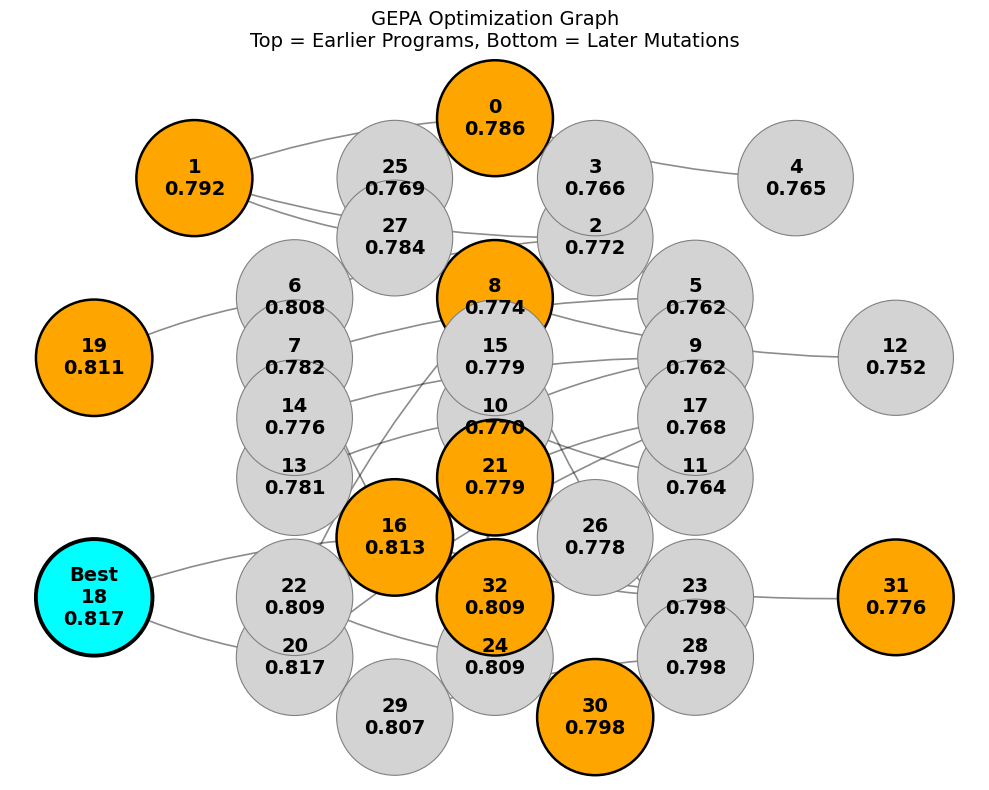

In [69]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from gepa.gepa_utils import find_dominator_programs

# --------------------------------------------------
# Extract GEPA results
# --------------------------------------------------

parents = optimized_model.detailed_results.parents
scores = optimized_model.detailed_results.val_aggregate_scores
best_idx = optimized_model.detailed_results.best_idx

pareto_front_programs = find_dominator_programs(
    optimized_model.detailed_results.per_val_instance_best_candidates,
    scores
)

# --------------------------------------------------
# Build graph
# --------------------------------------------------

G = nx.DiGraph()

for idx in range(len(parents)):
    G.add_node(idx, score=float(scores[idx]))

for child, parent_list in enumerate(parents):
    for parent in parent_list:
        if parent is not None:
            G.add_edge(parent, child)

# --------------------------------------------------
# Compute depth/generation
# --------------------------------------------------

depth = {}

def get_depth(node):
    if node in depth:
        return depth[node]

    parent_nodes = list(G.predecessors(node))

    if not parent_nodes:
        depth[node] = 0
    else:
        depth[node] = 1 + max(get_depth(p) for p in parent_nodes)

    return depth[node]

for node in G.nodes():
    get_depth(node)

# --------------------------------------------------
# Manual top-to-bottom layout
# --------------------------------------------------

layers = defaultdict(list)

for node, d in depth.items():
    layers[d].append(node)

pos = {}

x_scale = 0.3   # smaller = narrower graph
y_scale = 2.0   # larger = more vertical spacing

for d in sorted(layers.keys()):
    layer_nodes = sorted(
        layers[d],
        key=lambda n: G.nodes[n]["score"],
        reverse=True
    )

    n = len(layer_nodes)

    for i, node in enumerate(layer_nodes):
        x = i - (n - 1) / 2
        y = -d
        pos[node] = (x * x_scale, y * y_scale)

# --------------------------------------------------
# Styling
# --------------------------------------------------

node_colors = []
node_sizes = []
node_edgecolors = []
linewidths = []

for node in G.nodes():
    score = G.nodes[node]["score"]

    if node == best_idx:
        node_colors.append("cyan")
        node_edgecolors.append("black")
        linewidths.append(2.8)
    elif node in pareto_front_programs:
        node_colors.append("orange")
        node_edgecolors.append("black")
        linewidths.append(1.8)
    else:
        node_colors.append("lightgray")
        node_edgecolors.append("gray")
        linewidths.append(0.8)

    node_sizes.append(5000 + 2500 * score)

labels = {}

for node in G.nodes():
    if node == best_idx:
        labels[node] = f"Best\n{node}\n{G.nodes[node]['score']:.3f}"
    elif node in pareto_front_programs:
        labels[node] = f"{node}\n{G.nodes[node]['score']:.3f}"
    else:
        labels[node] = f"{node}\n{G.nodes[node]['score']:.3f}"

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=12,
    alpha=0.45,
    width=1.2,
    connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=linewidths
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=14,
    font_weight="bold"
)

plt.title(
    "GEPA Optimization Graph\nTop = Earlier Programs, Bottom = Later Mutations",
    fontsize=14
)

plt.axis("off")
plt.tight_layout()
plt.show()

<class 'dspy.teleprompt.gepa.gepa.DspyGEPAResult'>

Available attributes:

best_candidate
best_idx
best_outputs_valset
candidates
discovery_eval_counts
from_gepa_result
highest_score_achieved_per_val_task
log_dir
num_full_val_evals
parents
per_val_instance_best_candidates
seed
to_dict
total_metric_calls
val_aggregate_scores
val_subscores

Validation score trajectory:
   candidate_idx  val_score  discovery_eval_count
0              0   0.785848                     0
1              1   0.792192                   180
2              2   0.772397                   320
3              3   0.766243                   500
4              4   0.765049                   680


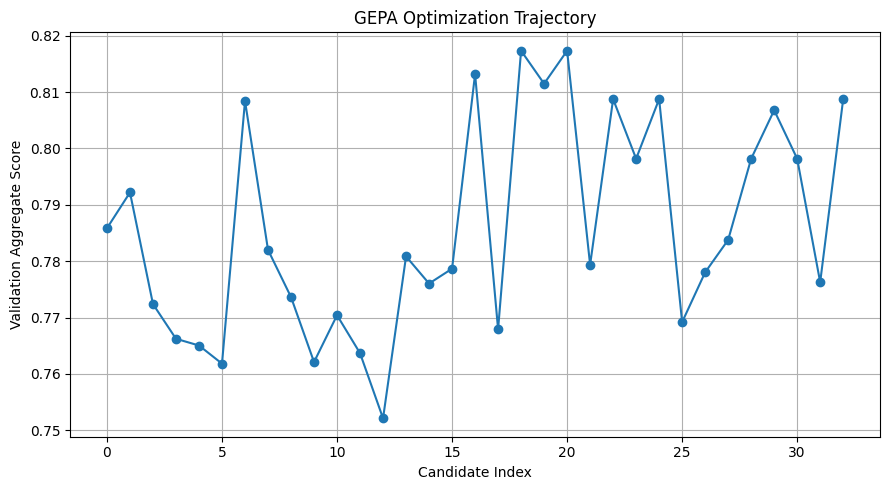


BEST CANDIDATE
Best candidate index: 18
item_proposal = Predict(StringSignature(paragraph, section, annotation_guidelines -> candidate_items
    instructions='You are a CONSORT 2010 checklist-item proposer.  \nYou receive one JSON object as input with these keys:  \n  • "paragraph": a free-text paragraph (one or more sentences) from a clinical trial report.  \n  • "section": the CONSORT section heading where this paragraph appears (e.g. "Methods", "Results", "Discussion", "Other").  \n  • "annotation_guidelines": full annotation instructions (you may ignore once you know the task).  \n\nYour job:  \n  1. Split the paragraph into sentences.  \n  2. For each sentence, scan for any mention—explicit or implied—of CONSORT checklist items 1a–25.  Treat each sentence independently; if it contains any trigger for an item, include that item.  \n  3. Use the section as a “soft prior” (e.g., Methods text often yields items 3a–12b, Results 13a–19, Discussion 20–22, Other 23–25) but do NOT exclude

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# GEPA detailed results object
# --------------------------------------------------

details = optimized_model.detailed_results

print(type(details))

# Since this is a DspyGEPAResult object (not dict),
# inspect available attributes first

print("\nAvailable attributes:\n")
for attr in dir(details):
    if not attr.startswith("_"):
        print(attr)


# ==================================================
# Access attributes safely
# ==================================================

candidates = getattr(details, "candidates", [])
parents = getattr(details, "parents", [])
val_scores = getattr(details, "val_aggregate_scores", [])
val_subscores = getattr(details, "val_subscores", [])
best_idx = getattr(details, "best_idx", None)
best_candidate = getattr(details, "best_candidate", None)
discovery_counts = getattr(details, "discovery_eval_counts", [])
per_val_best = getattr(details, "per_val_instance_best_candidates", {})
highest_per_task = getattr(details, "highest_score_achieved_per_val_task", {})
total_metric_calls = getattr(details, "total_metric_calls", None)
num_full_val_evals = getattr(details, "num_full_val_evals", None)
log_dir = getattr(details, "log_dir", None)


# ==================================================
# 1. Validation score trajectory
# ==================================================

if len(val_scores) > 0:
    df_scores = pd.DataFrame({
        "candidate_idx": list(range(len(val_scores))),
        "val_score": val_scores,
        "discovery_eval_count": (
            discovery_counts[:len(val_scores)]
            if len(discovery_counts) >= len(val_scores)
            else [None] * len(val_scores)
        )
    })

    print("\nValidation score trajectory:")
    print(df_scores.head())

    plt.figure(figsize=(9, 5))
    plt.plot(
        df_scores["candidate_idx"],
        df_scores["val_score"],
        marker="o"
    )
    plt.xlabel("Candidate Index")
    plt.ylabel("Validation Aggregate Score")
    plt.title("GEPA Optimization Trajectory")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("\nNo val_aggregate_scores found.")


# ==================================================
# 2. Best candidate prompt
# ==================================================

print("\n" + "=" * 80)
print("BEST CANDIDATE")
print("=" * 80)

print(f"Best candidate index: {best_idx}")

if best_candidate is not None:
    if isinstance(best_candidate, dict):
        for module_name, prompt in best_candidate.items():
            print(f"\n--- Module: {module_name} ---\n")
            print(prompt)
    else:
        print(best_candidate)
else:
    print("No best_candidate found.")


# ==================================================
# 3. Prompt evolution lineage
# ==================================================

if len(candidates) > 0:
    print("\n" + "=" * 80)
    print("PROMPT EVOLUTION LINEAGE")
    print("=" * 80)

    for i in range(min(10, len(candidates))):
        print(f"\nCandidate {i}")
        print(f"Parent(s): {parents[i] if i < len(parents) else 'N/A'}")
        print(f"Score: {val_scores[i] if i < len(val_scores) else 'N/A'}")

        cand = candidates[i]

        if isinstance(cand, dict):
            for module_name, prompt in cand.items():
                print(f"\n[{module_name}]")
                print(str(prompt)[:800])
        else:
            print(str(cand)[:800])

else:
    print("\nNo candidates found.")


# ==================================================
# 4. Hardest validation examples
# ==================================================

if len(val_subscores) > 0:
    df_sub = pd.DataFrame(val_subscores)

    mean_scores = df_sub.mean(axis=0)

    hardest_examples = (
        pd.DataFrame({
            "val_example_id": mean_scores.index,
            "mean_score": mean_scores.values
        })
        .sort_values("mean_score")
        .head(20)
    )

    print("\n" + "=" * 80)
    print("HARDEST VALIDATION EXAMPLES")
    print("=" * 80)
    print(hardest_examples)

else:
    print("\nNo val_subscores found.")


# ==================================================
# 5. Pareto frontier
# ==================================================

if per_val_best:
    print("\n" + "=" * 80)
    print("PER-INSTANCE BEST CANDIDATES")
    print("=" * 80)

    for example_id, best_candidates in list(per_val_best.items())[:20]:
        print(
            f"Validation Example {example_id}: "
            f"Best Candidate(s) = {best_candidates}"
        )

else:
    print("\nNo Pareto frontier data found.")


# ==================================================
# 6. Cost summary
# ==================================================

print("\n" + "=" * 80)
print("COMPUTATIONAL COST SUMMARY")
print("=" * 80)

print(f"Total metric calls: {total_metric_calls}")
print(f"Full validation evaluations: {num_full_val_evals}")
print(f"Log directory: {log_dir}")

In [72]:
if len(candidates) > 0:
    print("\n" + "=" * 80)
    print("PROMPT EVOLUTION LINEAGE")
    print("=" * 80)

    for i in range(min(10, len(candidates))):
        print(f"\nCandidate {i}")
        print(f"Parent(s): {parents[i] if i < len(parents) else 'N/A'}")
        print(f"Score: {val_scores[i] if i < len(val_scores) else 'N/A'}")

        cand = candidates[i]

        if isinstance(cand, dict):
            for module_name, prompt in cand.items():
                print(f"\n[{module_name}]")
                print(str(prompt))
        else:
            print(str(cand))

else:
    print("\nNo candidates found.")



PROMPT EVOLUTION LINEAGE

Candidate 0
Parent(s): [None]
Score: 0.7858478188478186
item_proposal = Predict(StringSignature(paragraph, section, annotation_guidelines -> candidate_items
    instructions='You are a CONSORT 2010 expert. Given a paragraph from a clinical trial paper,\nidentify ALL CONSORT 2010 checklist items (1a–25) that MIGHT be addressed.\n\nStrategy:\n- Err on the side of inclusion — false negatives are worse than false positives here.\n- Scan each sentence independently; a single paragraph may contain multiple items.\n- Use the section heading as a soft prior (e.g., Methods → items 3a–12b; Results → 13a–19).\n- Candidate items do NOT need to be fully satisfied — borderline or partial mentions qualify.\n- Read the annotation guidelines and identify sentences that directly address a CONSORT item according to the guidelines.\n\nCommon section–item associations (not exhaustive):\n- Introduction         → 2a, 2b\n- Methods              → 3a, 3b, 4a, 4b, 5, 6a, 6b, 7a, 7b, 8

## final evaluation

In [119]:
gepa_dev_metrics = evaluate_dataset(optimized_model, devset)
#gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
#print("GEPA test:", gepa_test_metrics)

GEPA dev: {'item_precision': 0.6789, 'item_recall': 0.6491, 'item_f1': 0.6637, 'per_item_f1': {'11a': 0.0, '12a': 0.737, '13a': 0.667, '13b': 1.0, '14a': 0.667, '15': 0.533, '16': 0.4, '17a': 0.8, '17b': 0.167, '18': 0.7, '20': 0.5, '23': 0.0, '24': 0.0, '2b': 0.667, '3a': 0.0, '4a': 0.889, '4b': 0.8, '5': 0.8, '6a': 0.769, '7a': 0.6, '7b': 0.0, '8a': 0.0, '8b': 1.0}, 'n_examples': 276}


In [68]:
# o4-mini + o4-mini (full list + online + exclude abstract and title)
gepa_dev_metrics = evaluate_dataset(optimized_model, gepa_valset)
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
# print("GEPA test:", gepa_test_metrics)

100%|██████████| 100/100 [00:31<00:00,  3.14it/s]

GEPA dev: {'item_micro_precision': 0.5135, 'item_micro_recall': 0.6333, 'item_micro_f1': 0.5672, 'item_macro_f1': 0.4275, 'item_weighted_f1': 0.5915, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.5, 'recall': 0.5, 'f1': 0.5, 'support': 2, 'tp': 1, 'fp': 1, 'fn': 1}, '3b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 2, 'tp': 2, 'fp': 2, 'fn': 0}, '4a': {'precision': 1.0, 'recall': 0.8889, 'f1': 0.9412, 'support': 9, 'tp': 8, 'fp': 0, 'fn': 1}, '4b': {'precision': 0.2, 'recall': 1.0, 'f1': 0.3333, 'support': 1, 'tp': 1, 'fp': 4, 'fn': 0}, '5': {'precision': 0.2727, 'recall': 0.5, 'f1': 0.3529, 'support': 6, 'tp': 3, 'fp': 8, 'fn': 3}, '6a': {'precision': 0.7778, 'recall': 0.7, 'f1': 0.7368, 'support': 10, 'tp': 7, 'fp': 2, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, '

In [ ]:
# o4-mini + o4-mini (full list + online + exclude abstract and title(v5)) - 1500
gepa_dev_metrics = evaluate_dataset(optimized_model, gepa_valset)
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
# print("GEPA test:", gepa_test_metrics)

100%|██████████| 100/100 [00:26<00:00,  3.78it/s]

GEPA dev: {'item_micro_precision': 0.5063, 'item_micro_recall': 0.6667, 'item_micro_f1': 0.5755, 'item_macro_f1': 0.4278, 'item_weighted_f1': 0.6115, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.2, 'recall': 0.5, 'f1': 0.2857, 'support': 2, 'tp': 1, 'fp': 4, 'fn': 1}, '3b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 2, 'tp': 2, 'fp': 2, 'fn': 0}, '4a': {'precision': 0.875, 'recall': 0.7778, 'f1': 0.8235, 'support': 9, 'tp': 7, 'fp': 1, 'fn': 2}, '4b': {'precision': 0.5, 'recall': 1.0, 'f1': 0.6667, 'support': 1, 'tp': 1, 'fp': 1, 'fn': 0}, '5': {'precision': 0.3, 'recall': 0.5, 'f1': 0.375, 'support': 6, 'tp': 3, 'fp': 7, 'fn': 3}, '6a': {'precision': 0.7, 'recall': 0.7, 'f1': 0.7, 'support': 10, 'tp': 7, 'fp': 3, 'fn': 3}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, 'su

In [65]:
# o4-mini + o4-mini (full list + online + exclude abstract and title(v5)) - 3000
gepa_dev_metrics = evaluate_dataset(optimized_model, gepa_valset)
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
# print("GEPA test:", gepa_test_metrics)

100%|██████████| 100/100 [00:32<00:00,  3.06it/s]

GEPA dev: {'item_micro_precision': 0.5185, 'item_micro_recall': 0.6885, 'item_micro_f1': 0.5915, 'item_macro_f1': 0.4364, 'item_weighted_f1': 0.6312, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 0.5, 'f1': 0.6667, 'support': 2, 'tp': 1, 'fp': 0, 'fn': 1}, '3a': {'precision': 0.25, 'recall': 0.5, 'f1': 0.3333, 'support': 2, 'tp': 1, 'fp': 3, 'fn': 1}, '3b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '4a': {'precision': 0.875, 'recall': 0.7778, 'f1': 0.8235, 'support': 9, 'tp': 7, 'fp': 1, 'fn': 2}, '4b': {'precision': 0.3333, 'recall': 1.0, 'f1': 0.5, 'support': 1, 'tp': 1, 'fp': 2, 'fn': 0}, '5': {'precision': 0.3333, 'recall': 0.5, 'f1': 0.4, 'support': 6, 'tp': 3, 'fp': 6, 'fn': 3}, '6a': {'precision': 0.75, 'recall': 0.6923, 'f1': 0.72, 'support': 13, 'tp': 9, 'fp': 3, 'fn': 4}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571,

In [68]:
# o4-mini + o4-mini (full list + online + exclude abstract and title(v5)) - 5000
gepa_dev_metrics = evaluate_dataset(optimized_model, gepa_valset)
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
# print("GEPA test:", gepa_test_metrics)

100%|██████████| 100/100 [00:33<00:00,  3.01it/s]

GEPA dev: {'item_micro_precision': 0.5062, 'item_micro_recall': 0.6721, 'item_micro_f1': 0.5775, 'item_macro_f1': 0.4193, 'item_weighted_f1': 0.6127, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.2, 'recall': 0.5, 'f1': 0.2857, 'support': 2, 'tp': 1, 'fp': 4, 'fn': 1}, '3b': {'precision': 0.6667, 'recall': 1.0, 'f1': 0.8, 'support': 2, 'tp': 2, 'fp': 1, 'fn': 0}, '4a': {'precision': 1.0, 'recall': 0.7778, 'f1': 0.875, 'support': 9, 'tp': 7, 'fp': 0, 'fn': 2}, '4b': {'precision': 0.25, 'recall': 1.0, 'f1': 0.4, 'support': 1, 'tp': 1, 'fp': 3, 'fn': 0}, '5': {'precision': 0.375, 'recall': 0.5, 'f1': 0.4286, 'support': 6, 'tp': 3, 'fp': 5, 'fn': 3}, '6a': {'precision': 0.75, 'recall': 0.6923, 'f1': 0.72, 'support': 13, 'tp': 9, 'fp': 3, 'fn': 4}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, 'su

In [84]:
# o4-mini + o3 (full list + online + exclude abstract and title(v5)) - 1000
gepa_dev_metrics = evaluate_dataset(optimized_model, gepa_valset)
# gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
# print("GEPA test:", gepa_test_metrics)

100%|██████████| 100/100 [00:28<00:00,  3.52it/s]

GEPA dev: {'item_micro_precision': 0.5031, 'item_micro_recall': 0.6833, 'item_micro_f1': 0.5795, 'item_macro_f1': 0.4499, 'item_weighted_f1': 0.6245, 'per_item_metrics': {'2b': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 2, 'tp': 2, 'fp': 0, 'fn': 0}, '3a': {'precision': 0.3333, 'recall': 0.5, 'f1': 0.4, 'support': 2, 'tp': 1, 'fp': 2, 'fn': 1}, '3b': {'precision': 0.4, 'recall': 1.0, 'f1': 0.5714, 'support': 2, 'tp': 2, 'fp': 3, 'fn': 0}, '4a': {'precision': 0.9, 'recall': 1.0, 'f1': 0.9474, 'support': 9, 'tp': 9, 'fp': 1, 'fn': 0}, '4b': {'precision': 0.0909, 'recall': 1.0, 'f1': 0.1667, 'support': 1, 'tp': 1, 'fp': 10, 'fn': 0}, '5': {'precision': 0.5, 'recall': 0.8333, 'f1': 0.625, 'support': 6, 'tp': 5, 'fp': 5, 'fn': 1}, '6a': {'precision': 0.6429, 'recall': 0.6923, 'f1': 0.6667, 'support': 13, 'tp': 9, 'fp': 5, 'fn': 4}, '6b': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 0, 'tp': 0, 'fp': 0, 'fn': 0}, '7a': {'precision': 0.8333, 'recall': 0.7143, 'f1': 0.7

In [74]:
gepa_dev_metrics = evaluate_dataset(optimized_model, devset)
#gepa_test_metrics = evaluate_dataset(optimized_model, testset)

print("GEPA dev:", gepa_dev_metrics)
#print("GEPA test:", gepa_test_metrics)

  5%|▍         | 20/418 [03:38<1:12:32, 10.94s/it]


KeyboardInterrupt: 

In [ ]:
# gpt 5.4-mini default + gpt 5.4 mini default
gepa_test_metrics = evaluate_dataset(optimized_model, testset)
print("GEPA test:", gepa_test_metrics)

GEPA test: {'item_precision': 0.5603, 'item_recall': 0.6599, 'item_f1': 0.6061, 'per_item_f1': {'11a': 0.571, '11b': 1.0, '12a': 0.786, '13a': 0.364, '13b': 0.444, '14a': 0.462, '15': 0.889, '16': 0.364, '17a': 0.673, '17b': 0.333, '18': 0.467, '20': 0.476, '23': 0.0, '24': 1.0, '2b': 0.8, '3a': 0.4, '4a': 0.947, '4b': 0.182, '5': 0.615, '6a': 0.649, '7a': 0.75, '7b': 0.667, '8a': 0.0, '8b': 0.0}, 'n_examples': 459}


In [ ]:
# ── Model comparison: sentence-level prediction breakdown ───────────────────
# Populate this dict with the models you want to compare.
# Each value must be an Extractor (or ExtractorCoT, etc.) already instantiated.
models_to_compare = {
    # "o4_mini_base":      baseline_model,
    # "o4_mini_cot":       cot_model,
    # "o4_mini_optimized": optimized_model,
}

sentence_df, metrics_df = build_sentence_comparison_df(
    models=models_to_compare,
    dataset=devset[:50],   # use a small slice to keep runtime manageable
)

# ── Aggregate metrics table (one row per model) ───────────────────────────────
print("=== Aggregate Metrics ===")
print(metrics_df.to_string(index=False))

# ── Sentences where at least two models disagree on the item label ─────────────
item_cols = [f"{name}_item" for name in models_to_compare]
disagree_mask = sentence_df[item_cols].nunique(axis=1) > 1
print(f"\nSentences with model disagreement: {disagree_mask.sum()} / {len(sentence_df)}")

# Show disagreement rows alongside gold
display(
    sentence_df[disagree_mask]
    [["article", "pid", "section", "sentence", "gold_item"] + item_cols]
    .reset_index(drop=True)
)

# ── Per-model status distribution ─────────────────────────────────────────────
for name in models_to_compare:
    print(f"\n--- {name} status breakdown ---")
    print(sentence_df[f"{name}_status"].value_counts(dropna=False))


In [ ]:
# ── Pipeline diagnostic: funnel view ─────────────────────────────────────────
# Multi-step models (ExtractorMS) are evaluated stage-by-stage (~3× LLM calls).
# Single-step models collapse all three checks to their final output.
#
# Tip: run on a small subset first (e.g. devset[:30]).

models_to_diagnose = {
    # "o4_mini_single": baseline_model,
    # "o4_mini_multi":  multistep_model,
}

diag_df, summary_df = diagnose_pipeline(
    models=models_to_diagnose,
    dataset=devset[:30],
)

# ── Funnel summary ────────────────────────────────────────────────────────────
print("=== Pipeline Recall Funnel (positives only) ===")
print(summary_df.to_string(index=False))

# ── Per-stage recall distributions ───────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
stages = [
    ("item_recall",  "Item Recall\n(proposal stage)"),
    ("sent_recall",  "Sentence Recall\n(extraction stage)"),
    ("pair_recall",  "Pair Recall\n(final output)"),
]

for ax, (col, title) in zip(axes, stages):
    for name, grp in diag_df.groupby("model"):
        vals = grp[col].dropna()
        ax.hist(vals, bins=20, alpha=0.6, label=name)
    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("# paragraphs")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Worst-performing paragraphs by pair_recall ────────────────────────────────
for name in models_to_diagnose:
    sub = diag_df[diag_df["model"] == name].copy()
    worst = sub.nsmallest(10, "pair_recall")[
        ["article", "pid", "section",
         "item_recall", "sent_recall", "pair_recall",
         "n_gold_items", "n_gold_sents", "n_gold_pairs"]
    ]
    print(f"\n=== {name}: 10 worst paragraphs by pair_recall ===")
    display(worst.reset_index(drop=True))
